In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
#read json file

with open('bad_nauheim_data.json','r') as file:
    content = json.load(file)


In [3]:
#Convert json file into data frame
df = pd.DataFrame.from_dict(content['sensordata'])

In [4]:
# View dataFrame
df

,visitors,geoJson,locationId,name,location,lon,lat,avgDuration,timestamp,SID,_headers
0,7,None,415,Karlstraße 15,city_bad_nauh,8.739320,50.36408,16.02,2025-06-30T01:00:00.000Z,d5261325-e40c-4ed4-bbbf-5ce24d3de844,{'eventType': 'AriadneAreaEventType'}
1,1,None,415,Trafohaus Zanderstraße,city_bad_nauh,8.742841,50.36250,28.22,2025-06-30T01:00:00.000Z,dc716491-cffe-4661-bbe4-333b581a6926,{'eventType': 'AriadneAreaEventType'}
2,4,None,415,Friedrichstraße 11,city_bad_nauh,8.735750,50.36414,6.61,2025-06-30T01:00:00.000Z,cca912bc-7296-42fe-a37c-6f19b2840556,{'eventType': 'AriadneAreaEventType'}
3,2,None,415,Parkstraße 24,city_bad_nauh,8.736540,50.36557,7.78,2025-06-30T01:00:00.000Z,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,{'eventType': 'AriadneAreaEventType'}
4,9,None,415,Hauptstraße 36,city_bad_nauh,8.737240,50.36368,19.97,2025-06-30T01:00:00.000Z,b8419dcf-9ac6-4dab-9a7b-8af4718b74e1,{'eventType': 'AriadneAreaEventType'}
...,...,...,...,...,...,...,...,...,...,...,...
17573,4,None,415,Hauptstraße 8,city_bad_nauh,8.739170,50.36376,15.63,2025-07-13T23:00:00.000Z,481da5b9-afd5-44c5-b29b-6c3e23a59bcb,{'eventType': 'AriadneAreaEventType'}
17574,14,None,415,Reinhardstraße 19,city_bad_nauh,8.736910,50.36416,37.67,2025-07-13T23:00:00.000Z,7d06c31f-aa88-4c5b-8280-565243350ad8,{'eventType': 'AriadneAreaEventType'}
17575,34,None,415,Innenstadt,city_bad_nauh,NaN,NaN,42.92,2025-07-13T23:00:00.000Z,3cc1e766-97c5-4ed0-92c3-a800b5be8658,{'eventType': 'AriadneAreaEventType'}
17576,10,None,415,Karlstraße 15,city_bad_nauh,8.739320,50.36408,35.25,2025-07-13T23:00:00.000Z,d5261325-e40c-4ed4-bbbf-5ce24d3de844,{'eventType': 'AriadneAreaEventType'}


In [5]:
#Explore data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17578 entries, 0 to 17577
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   visitors     17578 non-null  int64  
 1   geoJson      0 non-null      object 
 2   locationId   17578 non-null  int64  
 3   name         17578 non-null  str    
 4   location     17578 non-null  str    
 5   lon          16081 non-null  float64
 6   lat          16081 non-null  float64
 7   avgDuration  17578 non-null  float64
 8   timestamp    17578 non-null  str    
 9   SID          17578 non-null  str    
 10  _headers     17578 non-null  object 
dtypes: float64(3), int64(2), object(2), str(4)
memory usage: 3.0+ MB


In [6]:
# Numerical datas that are important to us
df[['visitors','avgDuration']].describe()

,visitors,avgDuration
count,17578.000000,17578.000000
mean,54.756798,10.261508
std,80.323996,7.108359
min,0.000000,0.000000
25%,12.000000,6.192500
50%,32.000000,8.920000
75%,65.000000,12.640000
max,1007.000000,104.730000


In [7]:
#Find out the columns in data frame
df.columns

Index(['visitors', 'geoJson', 'locationId', 'name', 'location', 'lon', 'lat',
       'avgDuration', 'timestamp', 'SID', '_headers'],
      dtype='str')

In [8]:
#Find out the datatypes of the columns

df.dtypes

visitors         int64
geoJson         object
locationId       int64
name               str
location           str
lon            float64
lat            float64
avgDuration    float64
timestamp          str
SID                str
_headers        object
dtype: object

In [9]:
#Extract only the columns that are required from the dataset
columns = ['visitors','name','avgDuration','timestamp','SID']

df = df[columns]
print(df.head(n=10))

   visitors                    name  avgDuration                 timestamp  \
0         7           Karlstraße 15        16.02  2025-06-30T01:00:00.000Z   
1         1  Trafohaus Zanderstraße        28.22  2025-06-30T01:00:00.000Z   
2         4      Friedrichstraße 11         6.61  2025-06-30T01:00:00.000Z   
3         2           Parkstraße 24         7.78  2025-06-30T01:00:00.000Z   
4         9          Hauptstraße 36        19.97  2025-06-30T01:00:00.000Z   
5         3            Parkstraße 4         3.14  2025-06-30T01:00:00.000Z   
6         3           Alicestraße 2        11.18  2025-06-30T01:00:00.000Z   
7        23              Innenstadt        28.46  2025-06-30T01:00:00.000Z   
8        21              Innenstadt        14.10  2025-06-30T01:00:00.000Z   
9         4           Schulstraße 6         7.11  2025-06-30T01:00:00.000Z   

                                    SID  
0  d5261325-e40c-4ed4-bbbf-5ce24d3de844  
1  dc716491-cffe-4661-bbe4-333b581a6926  
2  cca912bc-729

In [10]:
#Check for NaN values
df.isna().sum()

visitors       0
name           0
avgDuration    0
timestamp      0
SID            0
dtype: int64

In [11]:
#The format 2025-06-30T01:00:00.000Z   is in UTC format. Change it in German time. 

df['timestamp'] = pd.to_datetime(df['timestamp'],utc= True).dt.tz_convert("Europe/Berlin")
df['timestamp'].dtypes


datetime64[us, Europe/Berlin]

In [12]:
df['weekday'] = df['timestamp'].dt.day_of_week

In [13]:
df['time'] = df['timestamp'].dt.hour

In [14]:
# To treat 23 and 0 are neighbours
df['hour_sin'] = np.sin(2 * np.pi * df['time'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['time'] / 24)

In [15]:
df.columns

Index(['visitors', 'name', 'avgDuration', 'timestamp', 'SID', 'weekday',
       'time', 'hour_sin', 'hour_cos'],
      dtype='str')

In [16]:
df

,visitors,name,avgDuration,timestamp,SID,weekday,time,hour_sin,hour_cos
0,7,Karlstraße 15,16.02,2025-06-30 03:00:00+02:00,d5261325-e40c-4ed4-bbbf-5ce24d3de844,0,3,0.707107,0.707107
1,1,Trafohaus Zanderstraße,28.22,2025-06-30 03:00:00+02:00,dc716491-cffe-4661-bbe4-333b581a6926,0,3,0.707107,0.707107
2,4,Friedrichstraße 11,6.61,2025-06-30 03:00:00+02:00,cca912bc-7296-42fe-a37c-6f19b2840556,0,3,0.707107,0.707107
3,2,Parkstraße 24,7.78,2025-06-30 03:00:00+02:00,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,0,3,0.707107,0.707107
4,9,Hauptstraße 36,19.97,2025-06-30 03:00:00+02:00,b8419dcf-9ac6-4dab-9a7b-8af4718b74e1,0,3,0.707107,0.707107
...,...,...,...,...,...,...,...,...,...
17573,4,Hauptstraße 8,15.63,2025-07-14 01:00:00+02:00,481da5b9-afd5-44c5-b29b-6c3e23a59bcb,0,1,0.258819,0.965926
17574,14,Reinhardstraße 19,37.67,2025-07-14 01:00:00+02:00,7d06c31f-aa88-4c5b-8280-565243350ad8,0,1,0.258819,0.965926
17575,34,Innenstadt,42.92,2025-07-14 01:00:00+02:00,3cc1e766-97c5-4ed0-92c3-a800b5be8658,0,1,0.258819,0.965926
17576,10,Karlstraße 15,35.25,2025-07-14 01:00:00+02:00,d5261325-e40c-4ed4-bbbf-5ce24d3de844,0,1,0.258819,0.965926


In [17]:
#Export to csv for analysis
df.to_csv('bad_nauheim.csv')

In [18]:
#After analysis we found that for a same timestamp, there exists a different readings for same sensor and place

df = df.groupby(['name','SID','timestamp']).agg(
    {'visitors': 'mean',
    'avgDuration': 'mean',
    'weekday': 'first',
    'hour_sin': 'first',
    'hour_cos': 'first'}).reset_index().sort_values(by=['SID','name','timestamp'])

In [19]:
df['visitors'] = np.round(df['visitors']) #visitors cannont be in float data
df

,name,SID,timestamp,visitors,avgDuration,weekday,hour_sin,hour_cos
2543,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 03:00:00+02:00,1.0,17.5500,0,0.707107,7.071068e-01
2544,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 04:00:00+02:00,3.0,4.1000,0,0.866025,5.000000e-01
2545,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 05:00:00+02:00,3.0,0.7500,0,0.965926,2.588190e-01
2546,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 06:00:00+02:00,17.0,6.2075,0,1.000000,6.123234e-17
2547,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 07:00:00+02:00,28.0,5.1475,0,0.965926,-2.588190e-01
...,...,...,...,...,...,...,...,...
4905,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 04:00:00+02:00,6.0,12.6400,6,0.866025,5.000000e-01
4906,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 05:00:00+02:00,4.0,10.8700,6,0.965926,2.588190e-01
4907,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 06:00:00+02:00,10.0,8.2600,6,1.000000,6.123234e-17
4908,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 23:00:00+02:00,0.0,6.7900,6,-0.258819,9.659258e-01


In [20]:
#Find out the number of sensors
df['SID'].nunique()

30

In [21]:
#Determine the sensors with most readings
df['SID'].value_counts().head(n=30)

SID
cca912bc-7296-42fe-a37c-6f19b2840556    256
b8419dcf-9ac6-4dab-9a7b-8af4718b74e1    252
d5261325-e40c-4ed4-bbbf-5ce24d3de844    252
481da5b9-afd5-44c5-b29b-6c3e23a59bcb    251
3cc1e766-97c5-4ed0-92c3-a800b5be8658    250
bc5edd25-415e-40fb-8607-ad8c0b10ea4c    250
ee12f4cf-9fbe-4c2a-b3fb-7783a3d78355    250
4ff66154-8c30-4f61-9e54-d5c1744c117c    249
db726d5d-f282-4977-ad4f-400853262062    249
d52b73da-cc5a-4e5d-83dd-3c028d3435ca    248
fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8    248
5ee75133-74ce-4a65-ac22-be263ad8566a    247
7d06c31f-aa88-4c5b-8280-565243350ad8    246
e43beee4-de88-43f8-9c31-c3f0d5dc1451    246
c294766d-4a58-496f-b00e-665dc626bdea    245
26213d2d-2954-4312-b42a-a6b323764086    243
4275b813-3d57-4b01-93a2-7d8271130792    242
dc716491-cffe-4661-bbe4-333b581a6926    241
bb71e93c-fc02-464c-acf0-f2c6c453762d    240
ee395b0b-5be7-4e62-b331-4207ba179629    240
b0d968cd-ded3-4953-b99f-2cb5fabd086d    232
d1a25cbb-e2d7-49d7-a75b-0e570b6d1e88    232
dd520fc1-e6de-4f55-b6d8-5083

In [22]:
#Sensors comparison

df.groupby(['SID','name'])['visitors'].mean().sort_values(ascending= False)

SID                                   name                             
3cc1e766-97c5-4ed0-92c3-a800b5be8658  Innenstadt                           262.508000
bc5edd25-415e-40fb-8607-ad8c0b10ea4c  Kurpark                              110.172000
ee12f4cf-9fbe-4c2a-b3fb-7783a3d78355  Kurstraße 7                           83.384000
db726d5d-f282-4977-ad4f-400853262062  Reinhardstraße 2                      63.879518
d5261325-e40c-4ed4-bbbf-5ce24d3de844  Karlstraße 15                         59.043651
d52b73da-cc5a-4e5d-83dd-3c028d3435ca  Alicestraße 2                         49.302419
dd520fc1-e6de-4f55-b6d8-508373be5330  Kurpark - Eingang Kolonnaden          49.241379
b0d968cd-ded3-4953-b99f-2cb5fabd086d  Kurpark - Eingang Sprudelhof          48.038793
e43beee4-de88-43f8-9c31-c3f0d5dc1451  Kurstraße 13                          39.691057
bb71e93c-fc02-464c-acf0-f2c6c453762d  Stresemannstraße 6                    38.966667
4ff66154-8c30-4f61-9e54-d5c1744c117c  Karlstraße 6                  

In [23]:
#Find out the missing data 

start_time = df['timestamp'].min()
end_time = df['timestamp'].max()
difference_time = end_time - start_time

print(f'Start Time: {start_time}')
print(f'End Time: {end_time}')
print(f'Total Time: {difference_time}')


def find_missing_data(sensors):
    total_hours = difference_time.total_seconds() / 3600 + 1
    sensorwise_data = dict()
    for sensor in sensors:
        sensor_data = df[df['SID']==sensor]
        location = sensor_data['name'].iloc[0]
        total_count = len(sensor_data)
        sensorwise_data[location] = total_hours - total_count
    return sensorwise_data
    


Start Time: 2025-06-30 03:00:00+02:00
End Time: 2025-07-14 01:00:00+02:00
Total Time: 13 days 22:00:00


In [24]:
sensors = df['SID'].unique()
missing_data = find_missing_data(sensors)
missing_data = dict(sorted(missing_data.items(), key=lambda x: x[1], reverse=True))
missing_values = pd.DataFrame({
    'location': missing_data.keys(),
    'missing_data': missing_data.values()
    
})

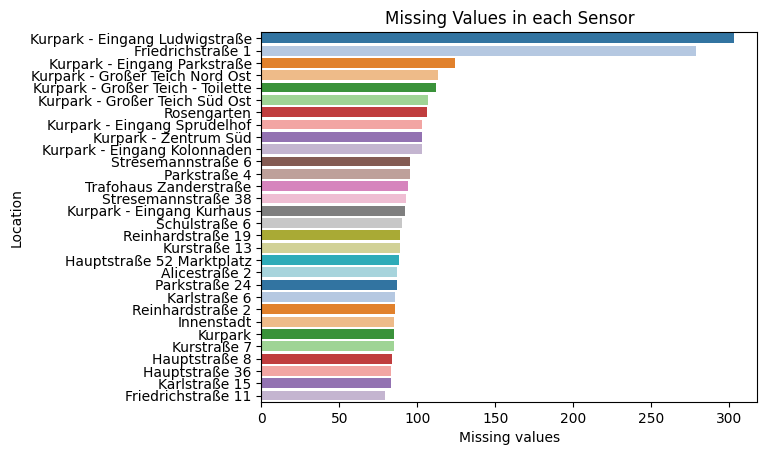

In [25]:
# Plot missing values pe sensor

sns.barplot(data= missing_values, x = 'missing_data',y = 'location',palette='tab20',hue='location')
plt.title('Missing Values in each Sensor')
plt.xlabel('Missing values')
plt.ylabel('Location')
plt.savefig("missing_vals.png", dpi=300, bbox_inches="tight")
plt.show()





In [26]:
#Export data of each sensor in csv to see if there is some pattern. For example a certain sensor is turned off at certain time
def per_sensor_data_analysis(sensors):
    directory = Path('sensor_data/')
    directory.mkdir(parents = True, exist_ok=True)
    for sensor in sensors:
        data = df[df['SID'] == sensor]
        location = data['name'].iloc[0]
        output_file = directory/f"{location}.csv"
        data.to_csv(output_file)
        

per_sensor_data_analysis(sensors)

In [27]:
#Find the missing timestamps of the sensor
def find_missing_date(sensor):
    max_date = df['timestamp'].max()
    min_date = df['timestamp'].min()
    sensor_data = df[df['SID'] == sensor]
    date_time = sensor_data['timestamp']
    intervals = pd.date_range(start= min_date, end= max_date,freq = 'h')
    missing_dates = intervals.difference(date_time)

    return missing_dates   

In [28]:
#Find out the faulty sensors -> The sensors which dont have readings till the last day are classified as faulty sensor.
def find_faulty_sensor(sensors):
    faulty_sensor = dict()
    max_date = pd.to_datetime('2025-07-13 22:00:00+0000')
    for sensor in sensors:
        sensor_data = df[df['SID'] == sensor]
        last_date = sensor_data['timestamp'].max()
        location = sensor_data['name'].iloc[0]
        if max_date > last_date:
            faulty_sensor[location] = last_date
    return faulty_sensor    

In [29]:
faulty_sensors = find_faulty_sensor(sensors)

faulty_sensors = pd.DataFrame({
    'sensor': faulty_sensors.keys(),
    'last_reading' : faulty_sensors.values()
})
print(faulty_sensors)

                           sensor              last_reading
0  Kurpark - Eingang Ludwigstraße 2025-07-01 15:00:00+02:00
1               Friedrichstraße 1 2025-07-02 13:00:00+02:00


In [30]:
unique_sensors = list(df['name'].unique())
faulty_sensor=list(faulty_sensors['sensor'])

# Find out the sensors which are working correctly.
sensors = [sensor for sensor in unique_sensors if sensor not in faulty_sensor]

print(len(sensors))

28


In [31]:
def handle_missing_cases(sensor, df):
    sensor_data = df[df['SID'] == sensor]
    missing_dates = find_missing_date(sensor)

    for missing_date in missing_dates:

        one_week_before = missing_date - timedelta(weeks=1)
        one_week_after = missing_date + timedelta(weeks=1)

        one_hour_before = missing_date - timedelta(hours=1)
        one_hour_after = missing_date + timedelta(hours=1)

        earlier = sensor_data[sensor_data['timestamp'] == one_hour_before]
        after = sensor_data[sensor_data['timestamp'] == one_hour_after]
        previous = sensor_data[sensor_data['timestamp'] == one_week_before]
        later = sensor_data[sensor_data['timestamp'] == one_week_after]

        if previous.empty and later.empty:

            for _ in range(5):
                if not earlier.empty:
                    break
                one_hour_before -= timedelta(hours=1)
                earlier = sensor_data[sensor_data['timestamp'] == one_hour_before]

            for _ in range(5):
                if not after.empty:
                    break
                one_hour_after += timedelta(hours=1)
                after = sensor_data[sensor_data['timestamp'] == one_hour_after]

            if not earlier.empty and not after.empty:
                visitors = (earlier['visitors'].iloc[0] + after['visitors'].iloc[0]) // 2
                avgDuration = (earlier['avgDuration'].iloc[0] + after['avgDuration'].iloc[0]) / 2

                weekday = earlier['weekday'].iloc[0]
                hour_sin = earlier['hour_sin'].iloc[0]
                hour_cos = earlier['hour_cos'].iloc[0]
                name = earlier['name'].iloc[0]

            elif not earlier.empty:
                visitors = earlier['visitors'].iloc[0]
                avgDuration = earlier['avgDuration'].iloc[0]
                weekday = earlier['weekday'].iloc[0]
                hour_sin = earlier['hour_sin'].iloc[0]
                hour_cos = earlier['hour_cos'].iloc[0]
                name = earlier['name'].iloc[0]

            elif not after.empty:
                visitors = after['visitors'].iloc[0]
                avgDuration = after['avgDuration'].iloc[0]
                weekday = after['weekday'].iloc[0]
                hour_sin = after['hour_sin'].iloc[0]
                hour_cos = after['hour_cos'].iloc[0]
                name = after['name'].iloc[0]

            else:
                visitors = 0
                avgDuration = 0.0
                weekday = missing_date.weekday()
                hour_sin = 0
                hour_cos = 0
                name = None

        elif later.empty:
            visitors = previous['visitors'].iloc[0]
            avgDuration = previous['avgDuration'].iloc[0]
            weekday = previous['weekday'].iloc[0]
            hour_sin = previous['hour_sin'].iloc[0]
            hour_cos = previous['hour_cos'].iloc[0]
            name = previous['name'].iloc[0]

        else:
            visitors = later['visitors'].iloc[0]
            avgDuration = later['avgDuration'].iloc[0]
            weekday = later['weekday'].iloc[0]
            hour_sin = later['hour_sin'].iloc[0]
            hour_cos = later['hour_cos'].iloc[0]
            name = later['name'].iloc[0]

        new_row = pd.DataFrame({
            'SID': [sensor],
            'timestamp': [missing_date],
            'visitors': [visitors],
            'avgDuration': [avgDuration],
            'name': [name],
            'weekday': [weekday],
            'hour_sin': [hour_sin],
            'hour_cos': [hour_cos]
        })

        df = pd.concat([df, new_row], ignore_index=True)
        sensor_data = df[df['SID'] == sensor]

    return df

In [32]:
#Filter only the functioning sensors
df = df[df['name'].isin(sensors)]
final_sensors = df['SID'].unique()
print(len(final_sensors))
for sensor in final_sensors:
    df = handle_missing_cases(sensor,df)

28


In [33]:
df = df.sort_values(['SID','timestamp'],ascending=True)
df

,name,SID,timestamp,visitors,avgDuration,weekday,hour_sin,hour_cos
0,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 03:00:00+02:00,1.0,17.550000,0,0.707107,7.071068e-01
1,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 04:00:00+02:00,3.0,4.100000,0,0.866025,5.000000e-01
2,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 05:00:00+02:00,3.0,0.750000,0,0.965926,2.588190e-01
3,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 06:00:00+02:00,17.0,6.207500,0,1.000000,6.123234e-17
4,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 07:00:00+02:00,28.0,5.147500,0,0.965926,-2.588190e-01
...,...,...,...,...,...,...,...,...
9377,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 21:00:00+02:00,10.0,21.940000,6,-0.707107,7.071068e-01
9378,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 22:00:00+02:00,20.0,8.475000,6,-0.500000,8.660254e-01
6752,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-13 23:00:00+02:00,0.0,6.790000,6,-0.258819,9.659258e-01
9379,Parkstraße 24,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,2025-07-14 00:00:00+02:00,3.0,12.208333,6,-0.258819,9.659258e-01


In [34]:
#Finally add weeekday cos and weekday sin

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

In [35]:
sensors = df['SID'].unique()
print(len(sensors))

28


In [36]:
# BoxPlot Analysis for each sensors for detecting possible outliers
def boxplot_analysis_visitors(sensor):

    data = df[df['SID'] == sensor]
    name = data['name'].iloc[0]

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        y=data['visitors'],
        color="skyblue",
        width=0.4
    )

    plt.title(f'Box Plot for Visitors - Location {name}', 
              fontsize=12, weight='bold')

    plt.xlabel(f'Sensor: {sensor}')
    plt.ylabel('Visitors Number')

    plt.xticks([])
    plt.tight_layout()
    plt.show()

In [37]:
#Visitor Pattern analysis for each sensor
    
def pattern_analysis(sensor):

        data1 = df[df['SID'] == sensor]
        fig, ax = plt.subplots(nrows=3,ncols=1,figsize = (16,14))
        sns.lineplot(data=data1, x="timestamp", y="visitors", linewidth=1,ax=ax[2],color="black")
        ax[2].axes.set_title(f"Vistitor Pattern in Location {data1['name'].iloc[0]}",fontsize=10, weight='bold')
        ax[2].set_xlabel("Timestamp",fontsize=10)
        ax[2].set_ylabel("Visitors Number",fontsize=10)
        ax[2].tick_params(labelsize=9)

        data2 = data1.head(n=24) 
        sns.lineplot(data=data2, x="timestamp", y="visitors", linewidth=1,ax=ax[0],color="red")
        ax[0].axes.set_title(f"Daily Vistitor Pattern in Location {data2['name'].iloc[0]}",fontsize=10, weight='bold')
        ax[0].set_xlabel("Timestamp",fontsize=10)
        ax[0].set_ylabel("Visitors Number",fontsize=10)
        ax[0].tick_params(labelsize=9)

        data3 = data1.head(n=168)
        sns.lineplot(data=data3, x="timestamp", y="visitors", linewidth=1,ax=ax[1],color="green")
        ax[1].axes.set_title(f"Weekly Visitors Patten in Location {data3['name'].iloc[0]}",fontsize=10, weight='bold')
        ax[1].set_xlabel("Timestamp",fontsize=10)
        ax[1].set_ylabel("Visitors Number",fontsize=10)
        ax[1].tick_params(labelsize=9)

        plt.tight_layout()
        plt.show()
       
        

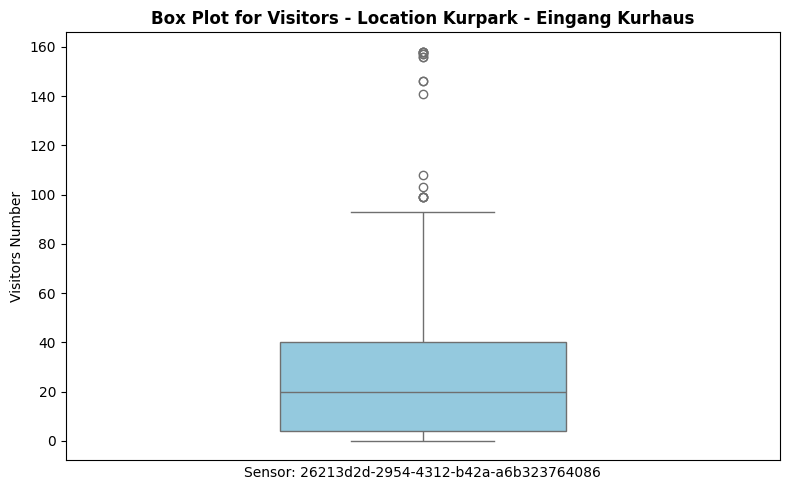

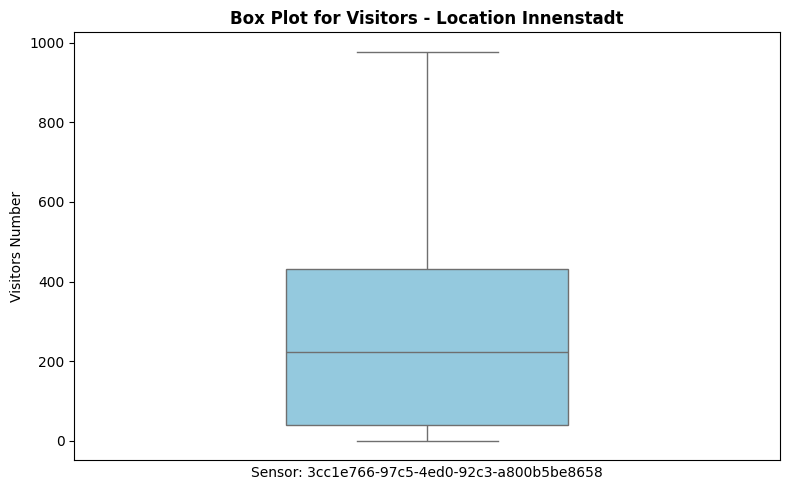

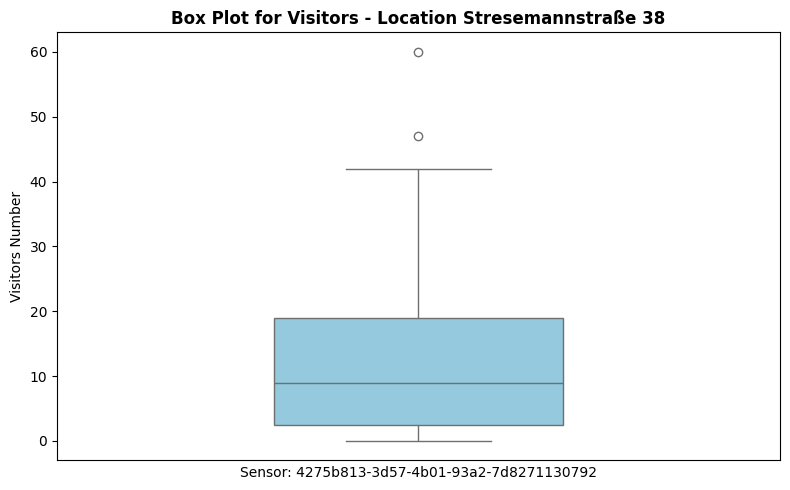

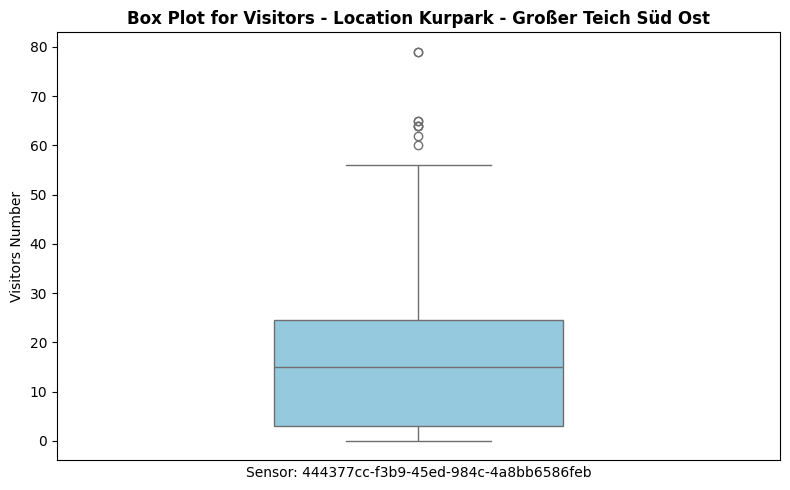

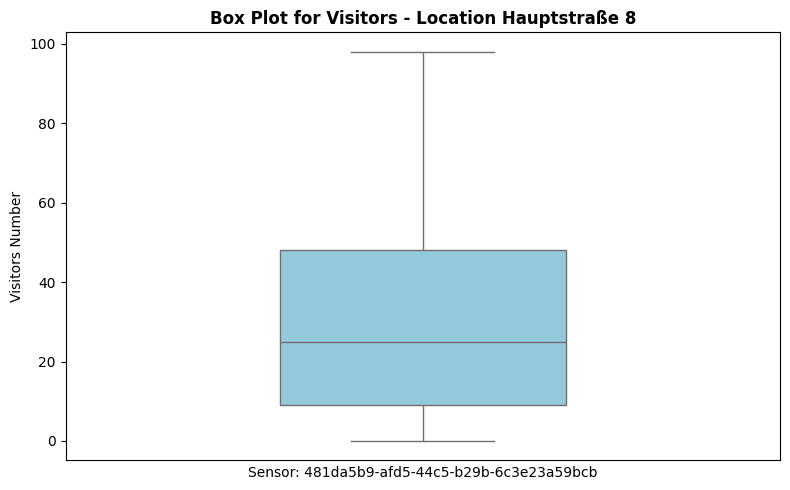

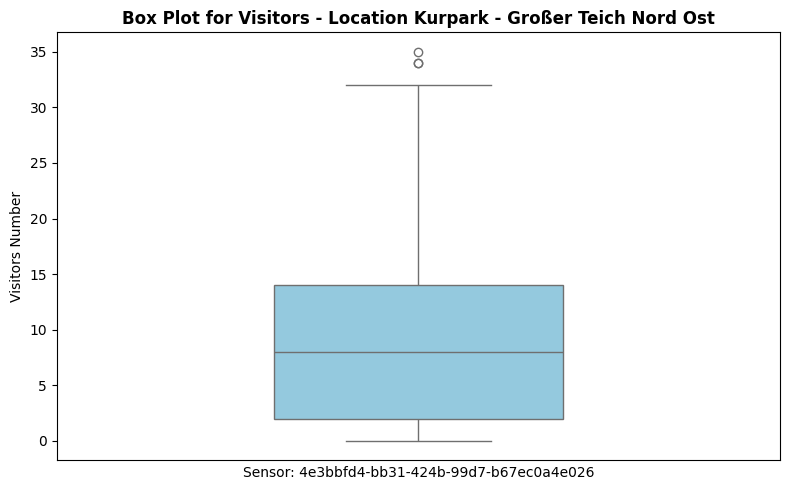

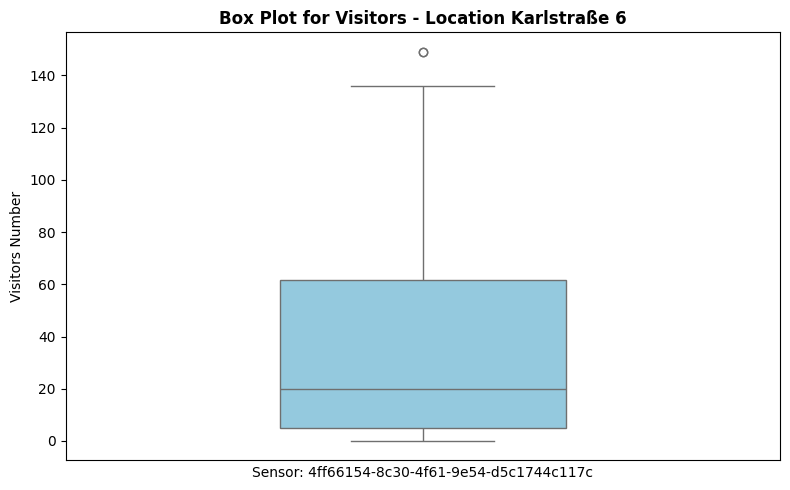

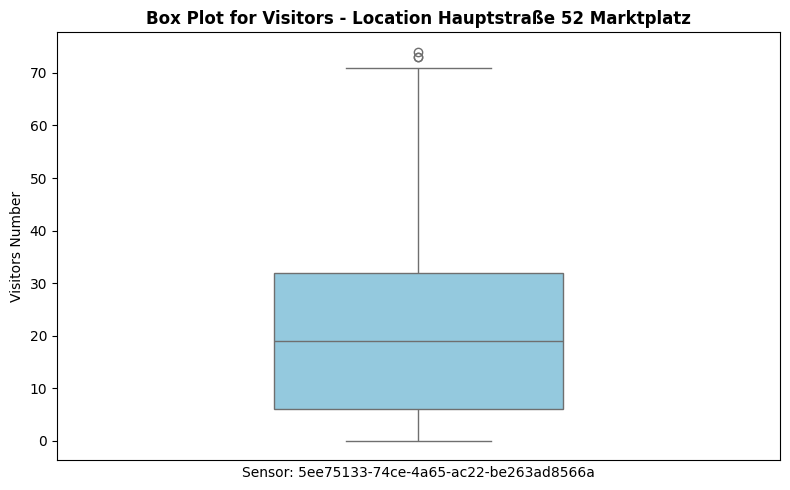

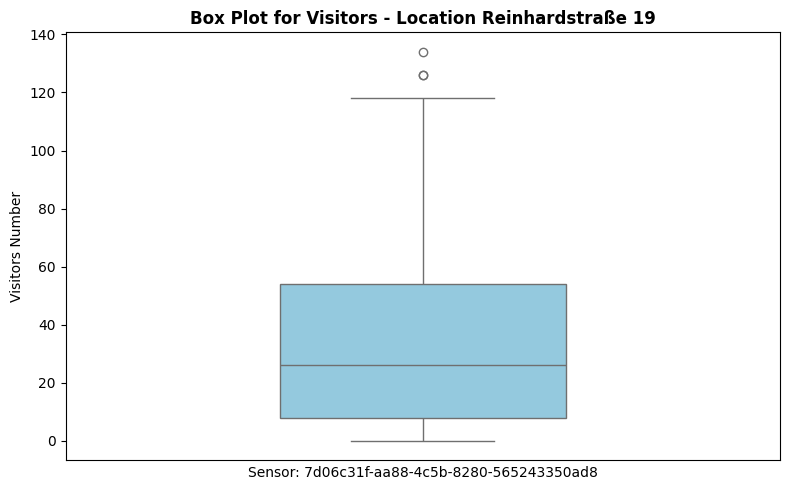

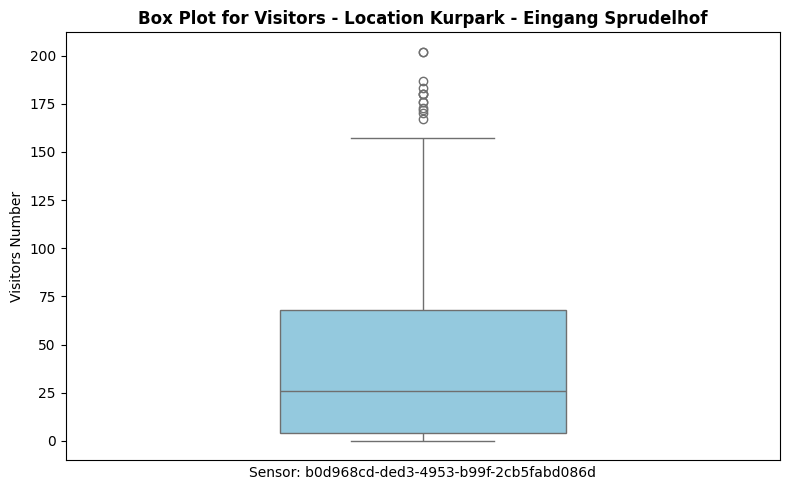

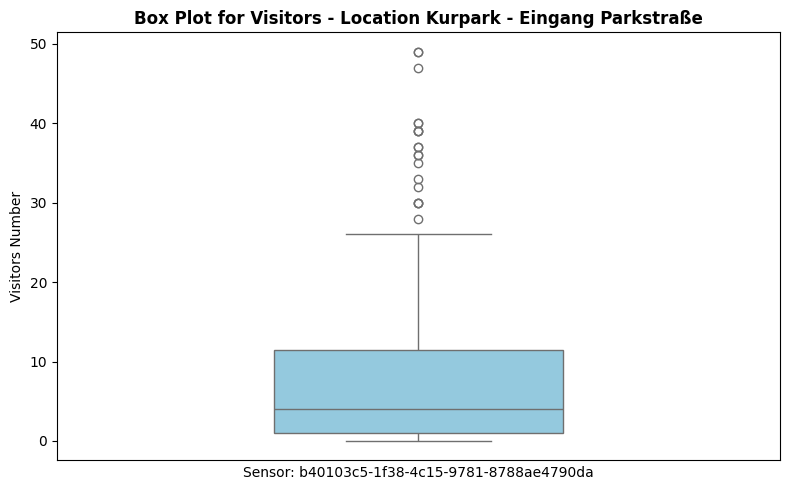

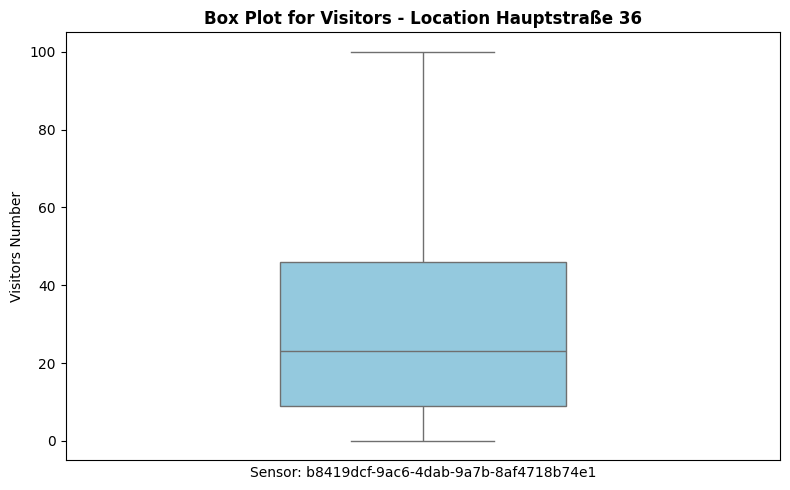

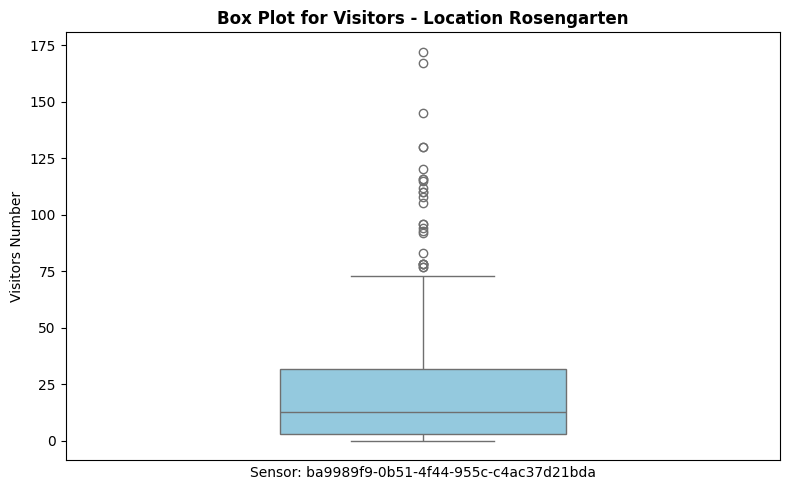

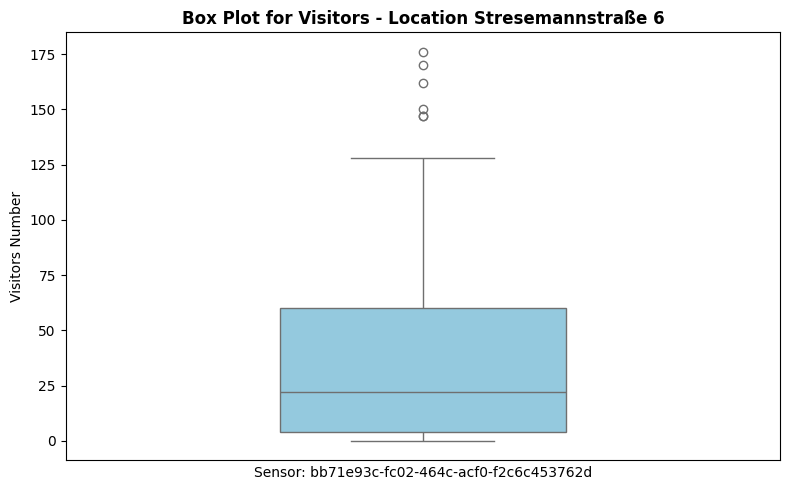

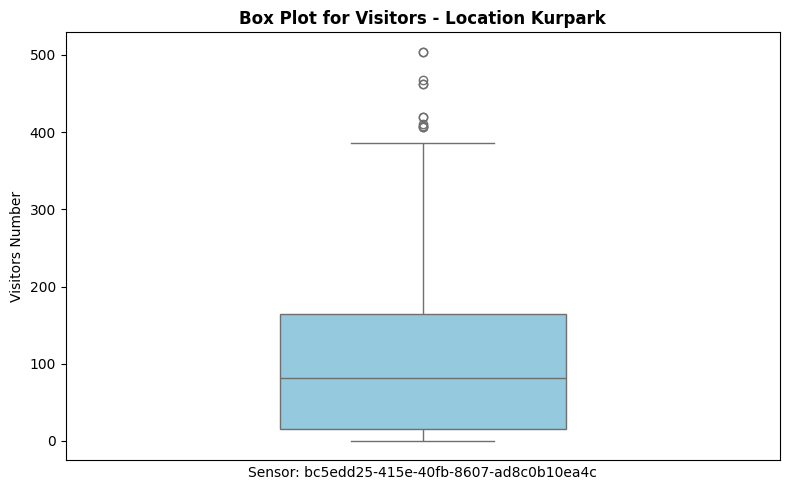

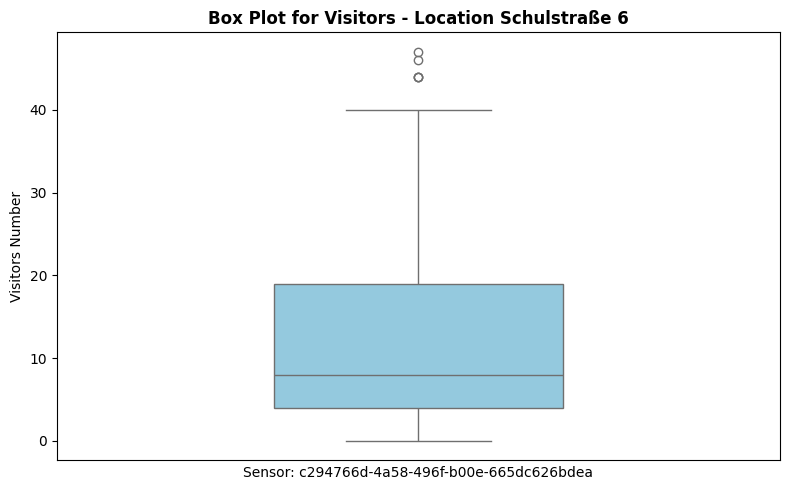

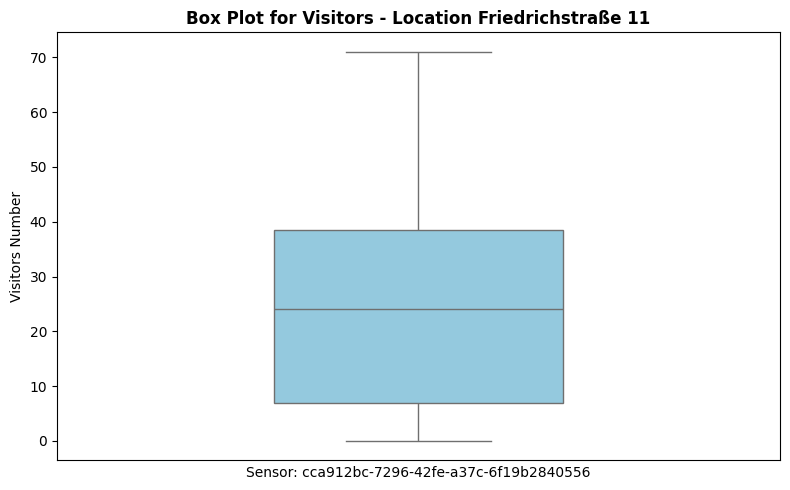

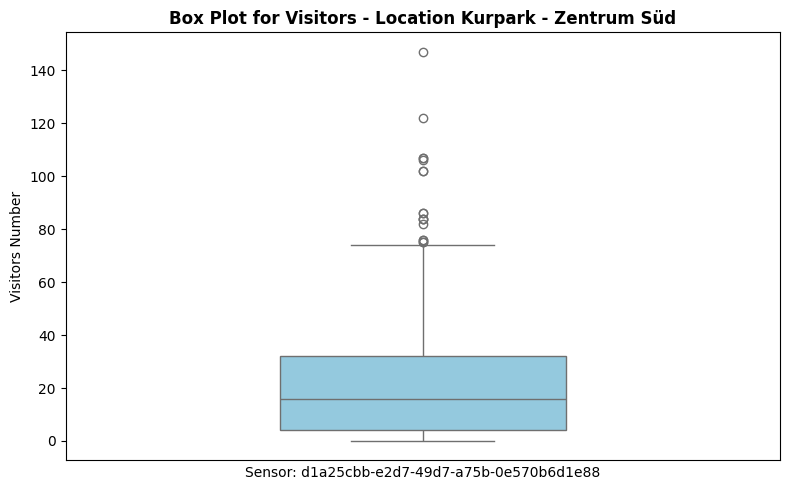

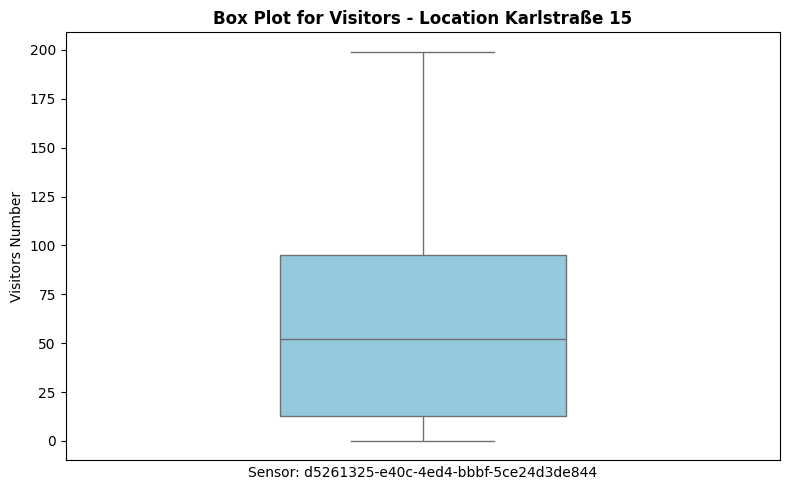

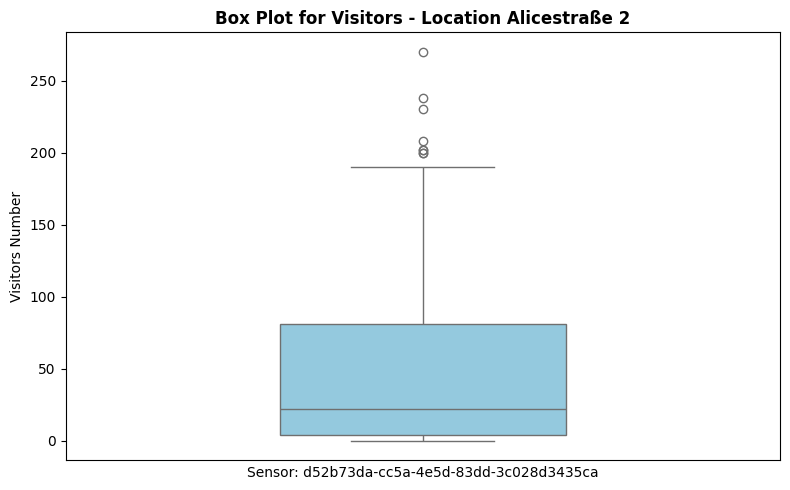

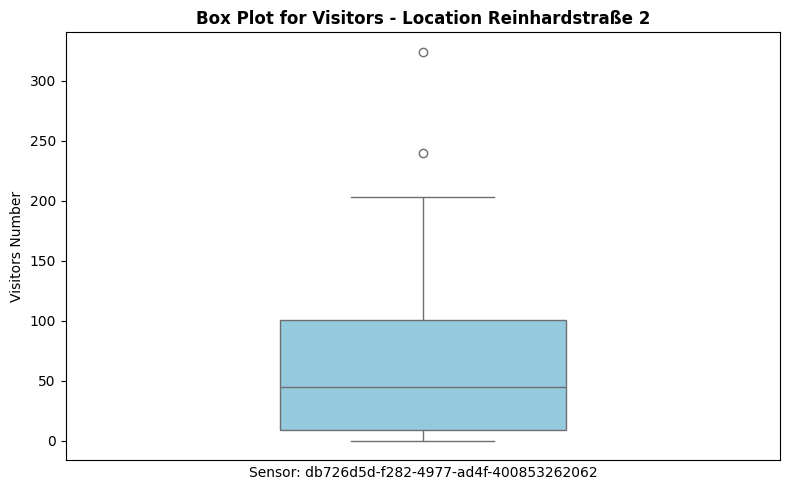

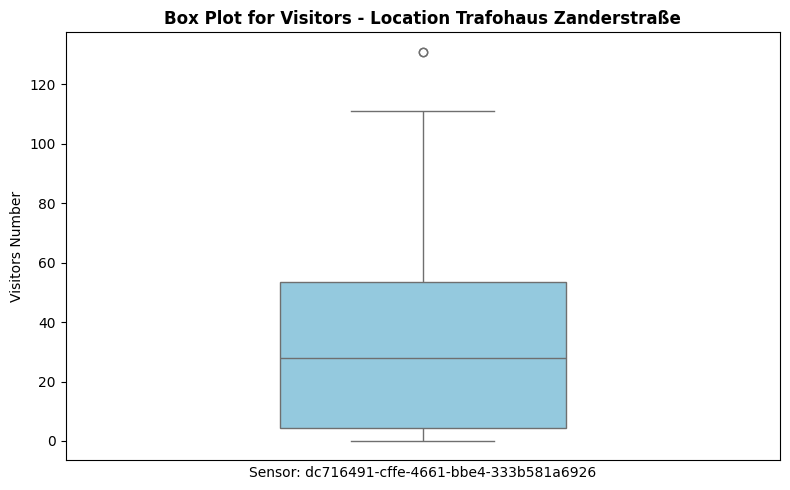

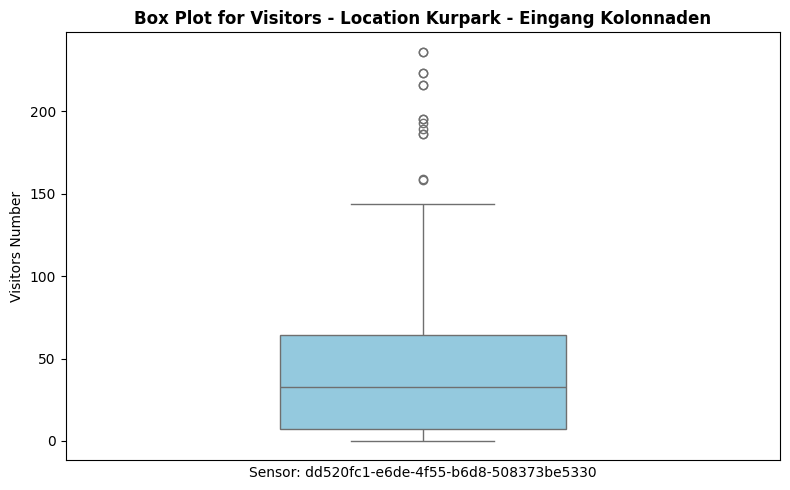

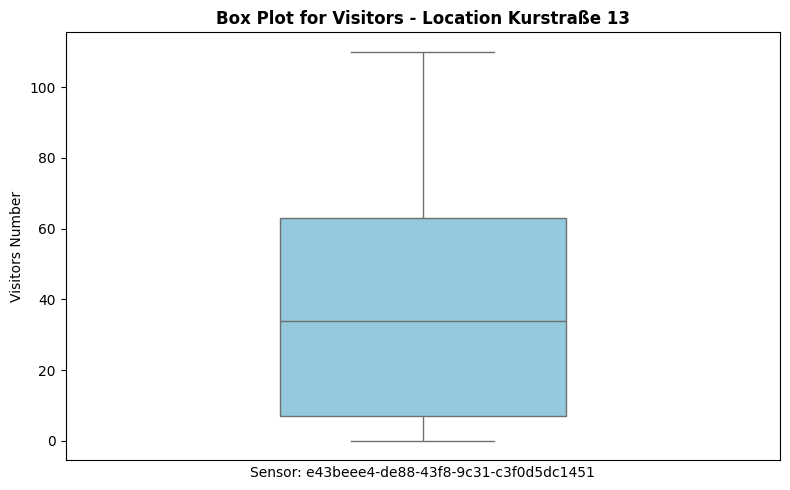

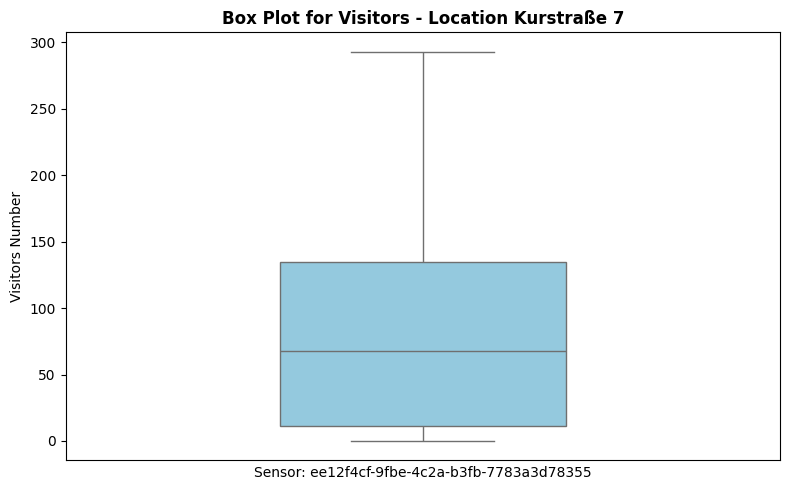

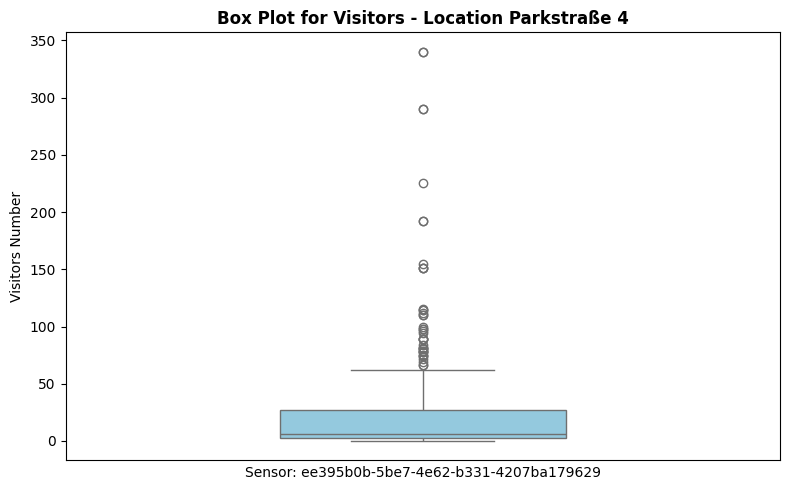

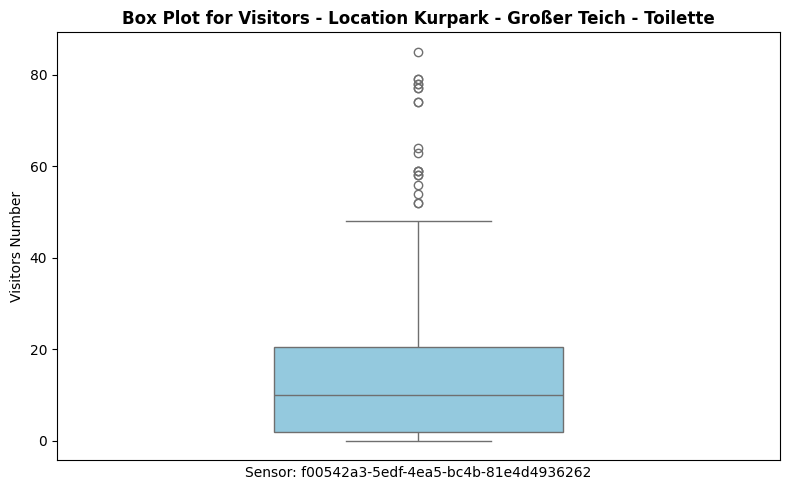

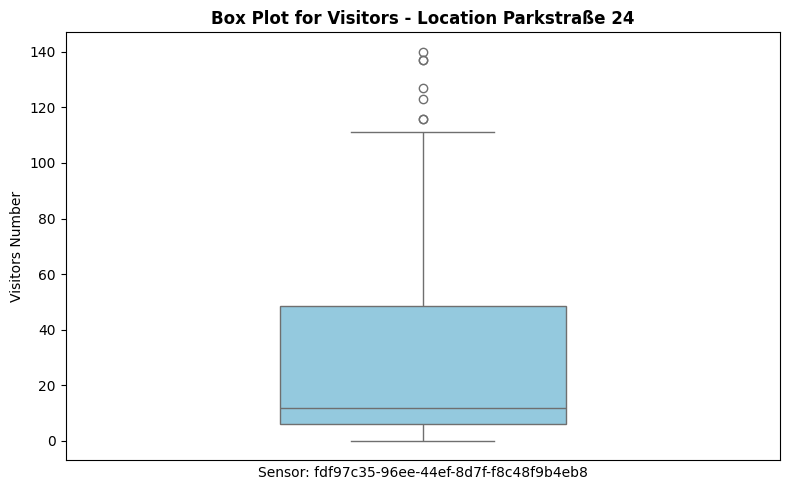

In [38]:
for sensor in sensors:
    boxplot_analysis_visitors(sensor)

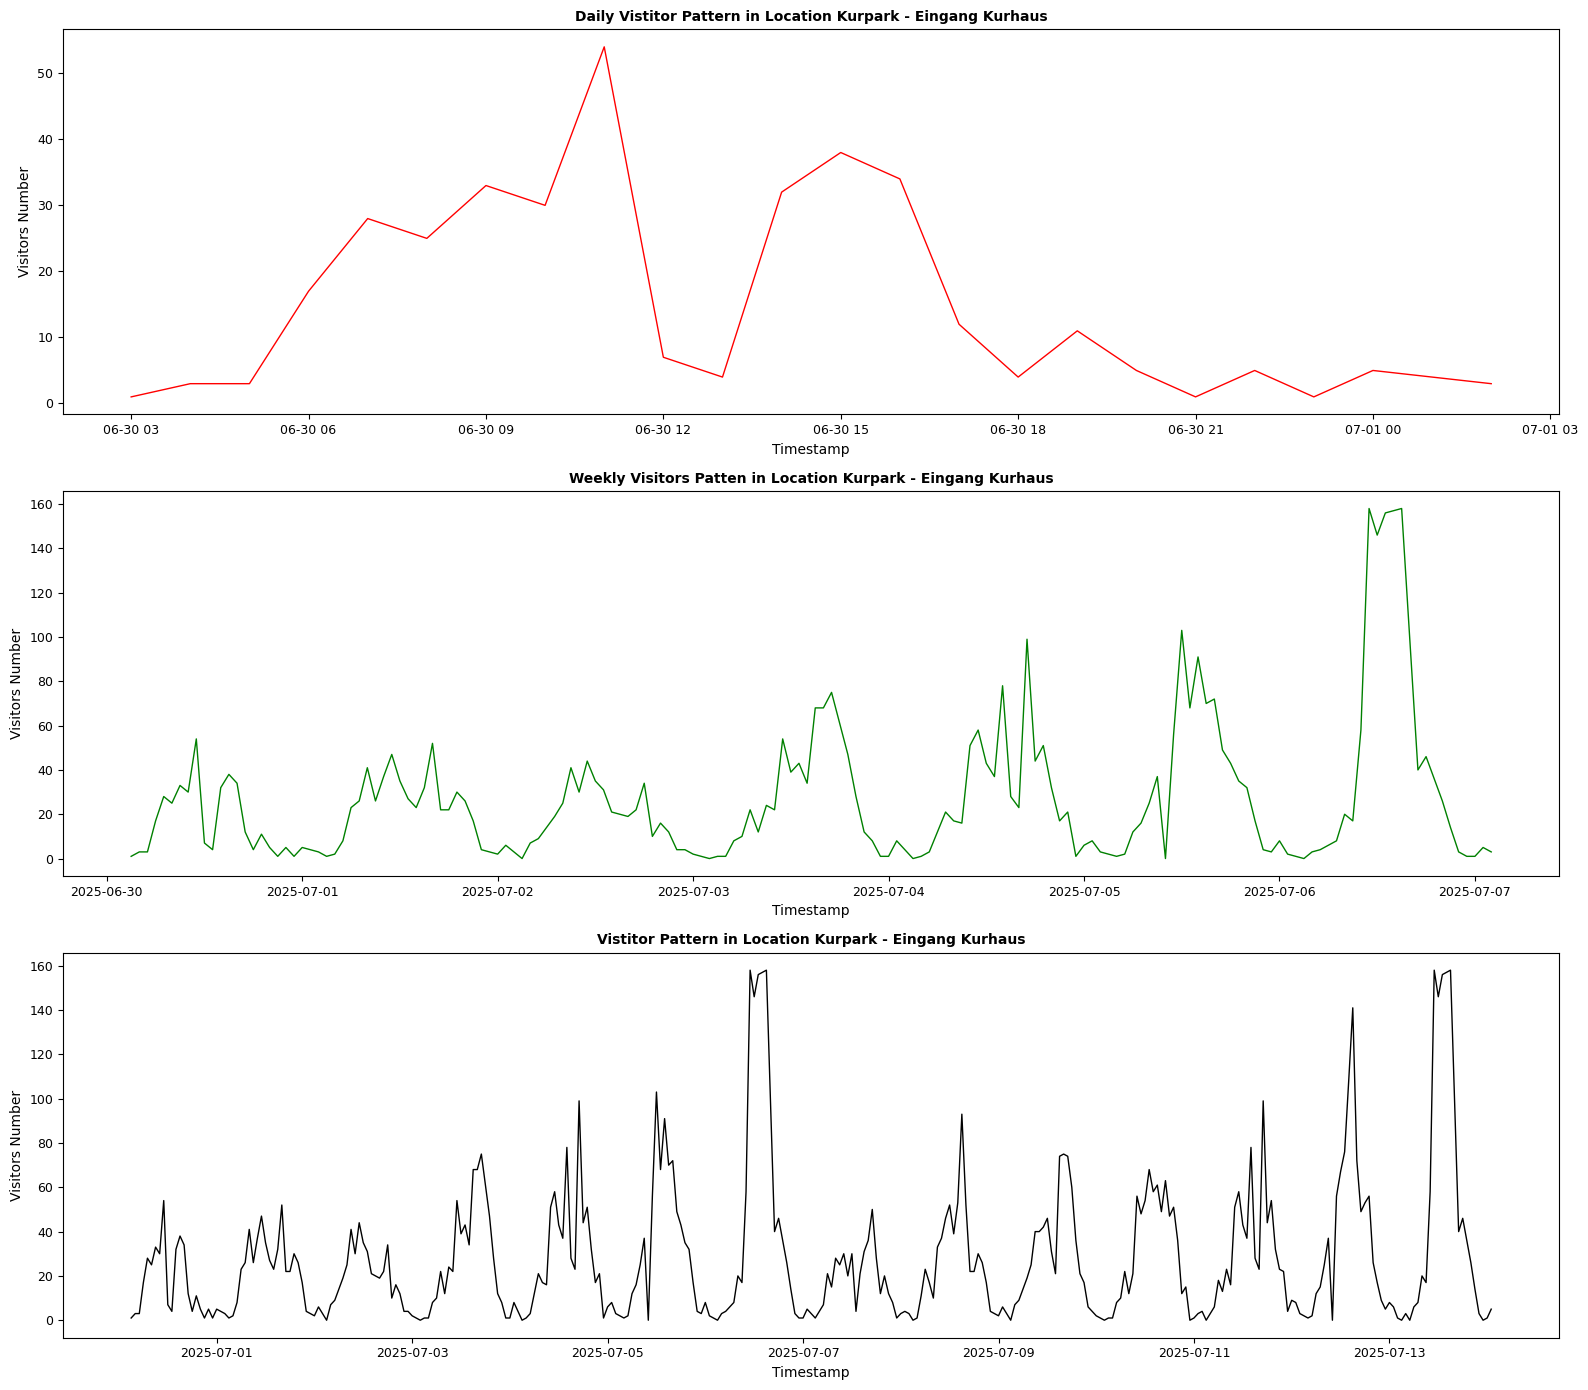

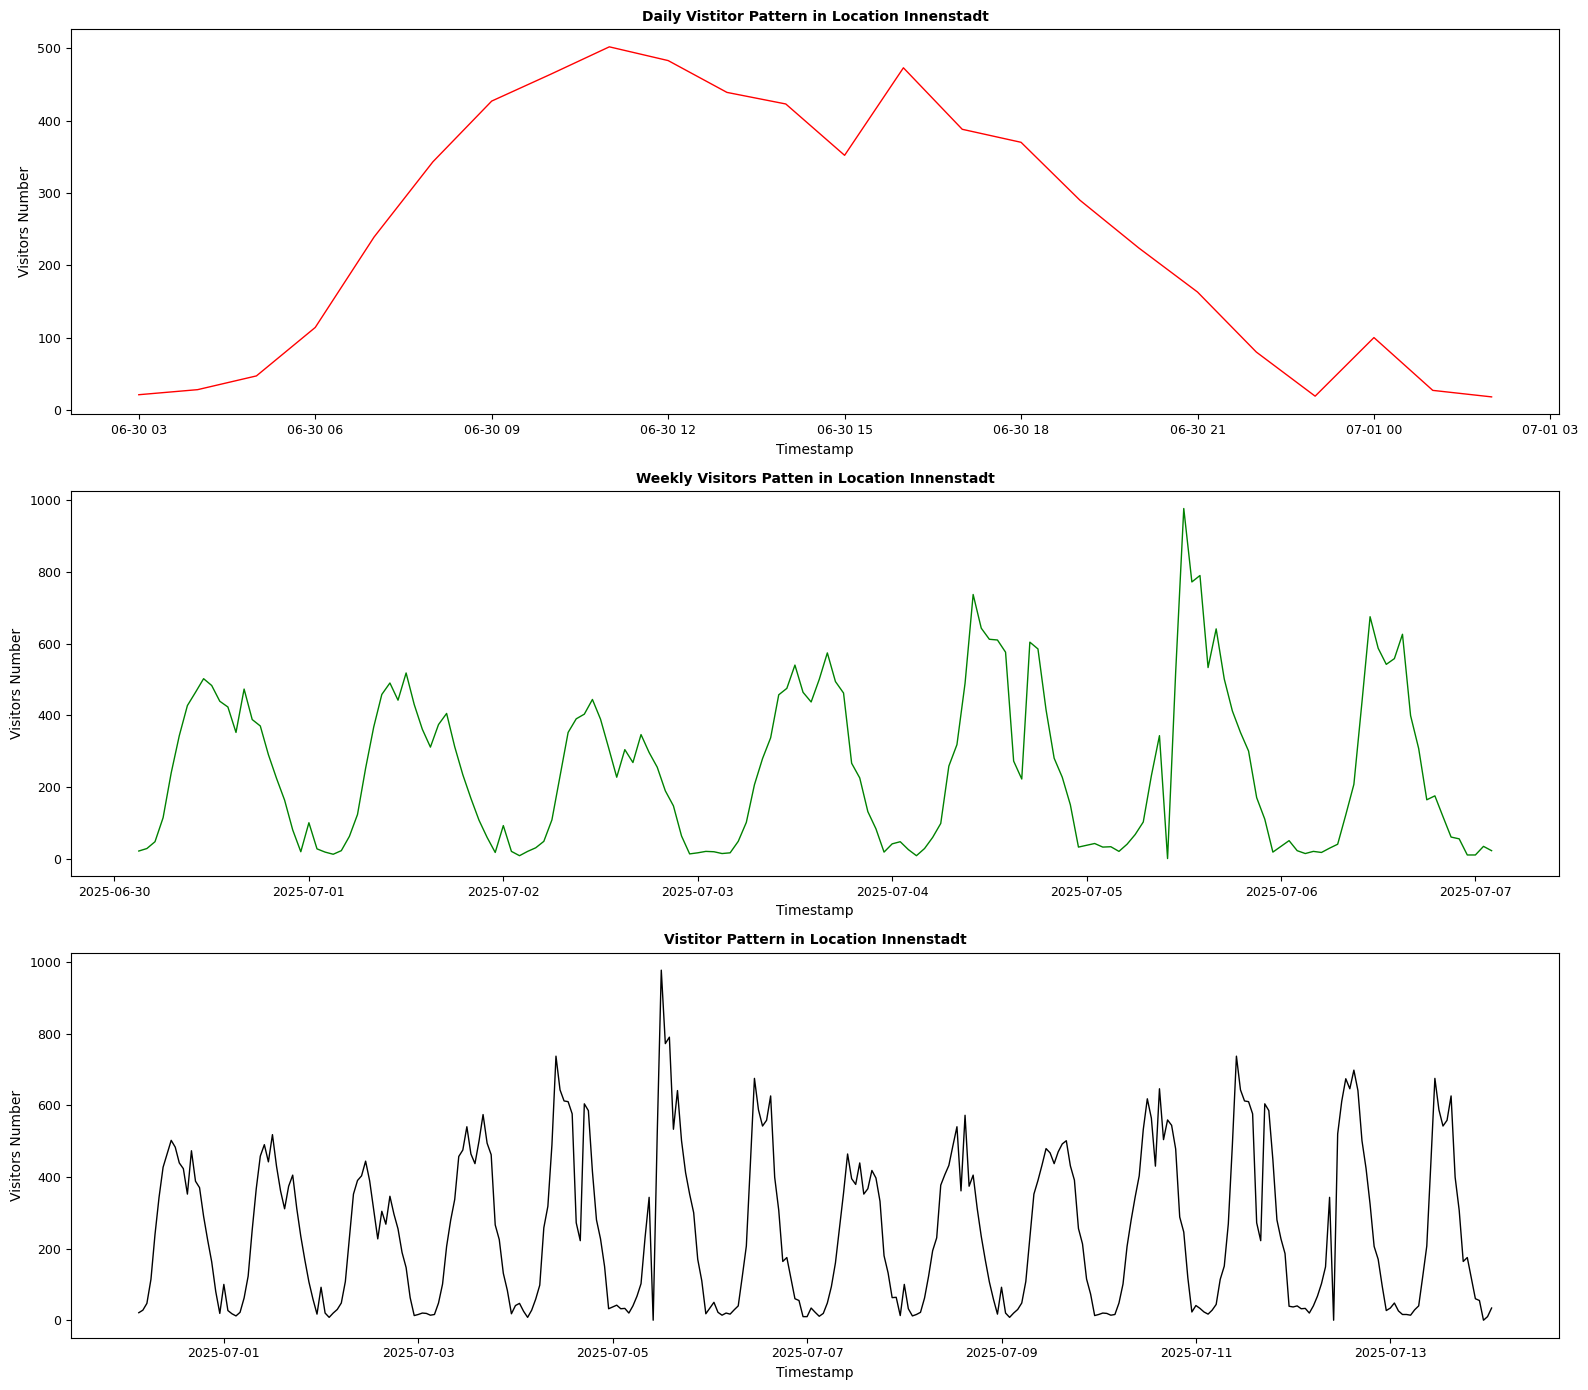

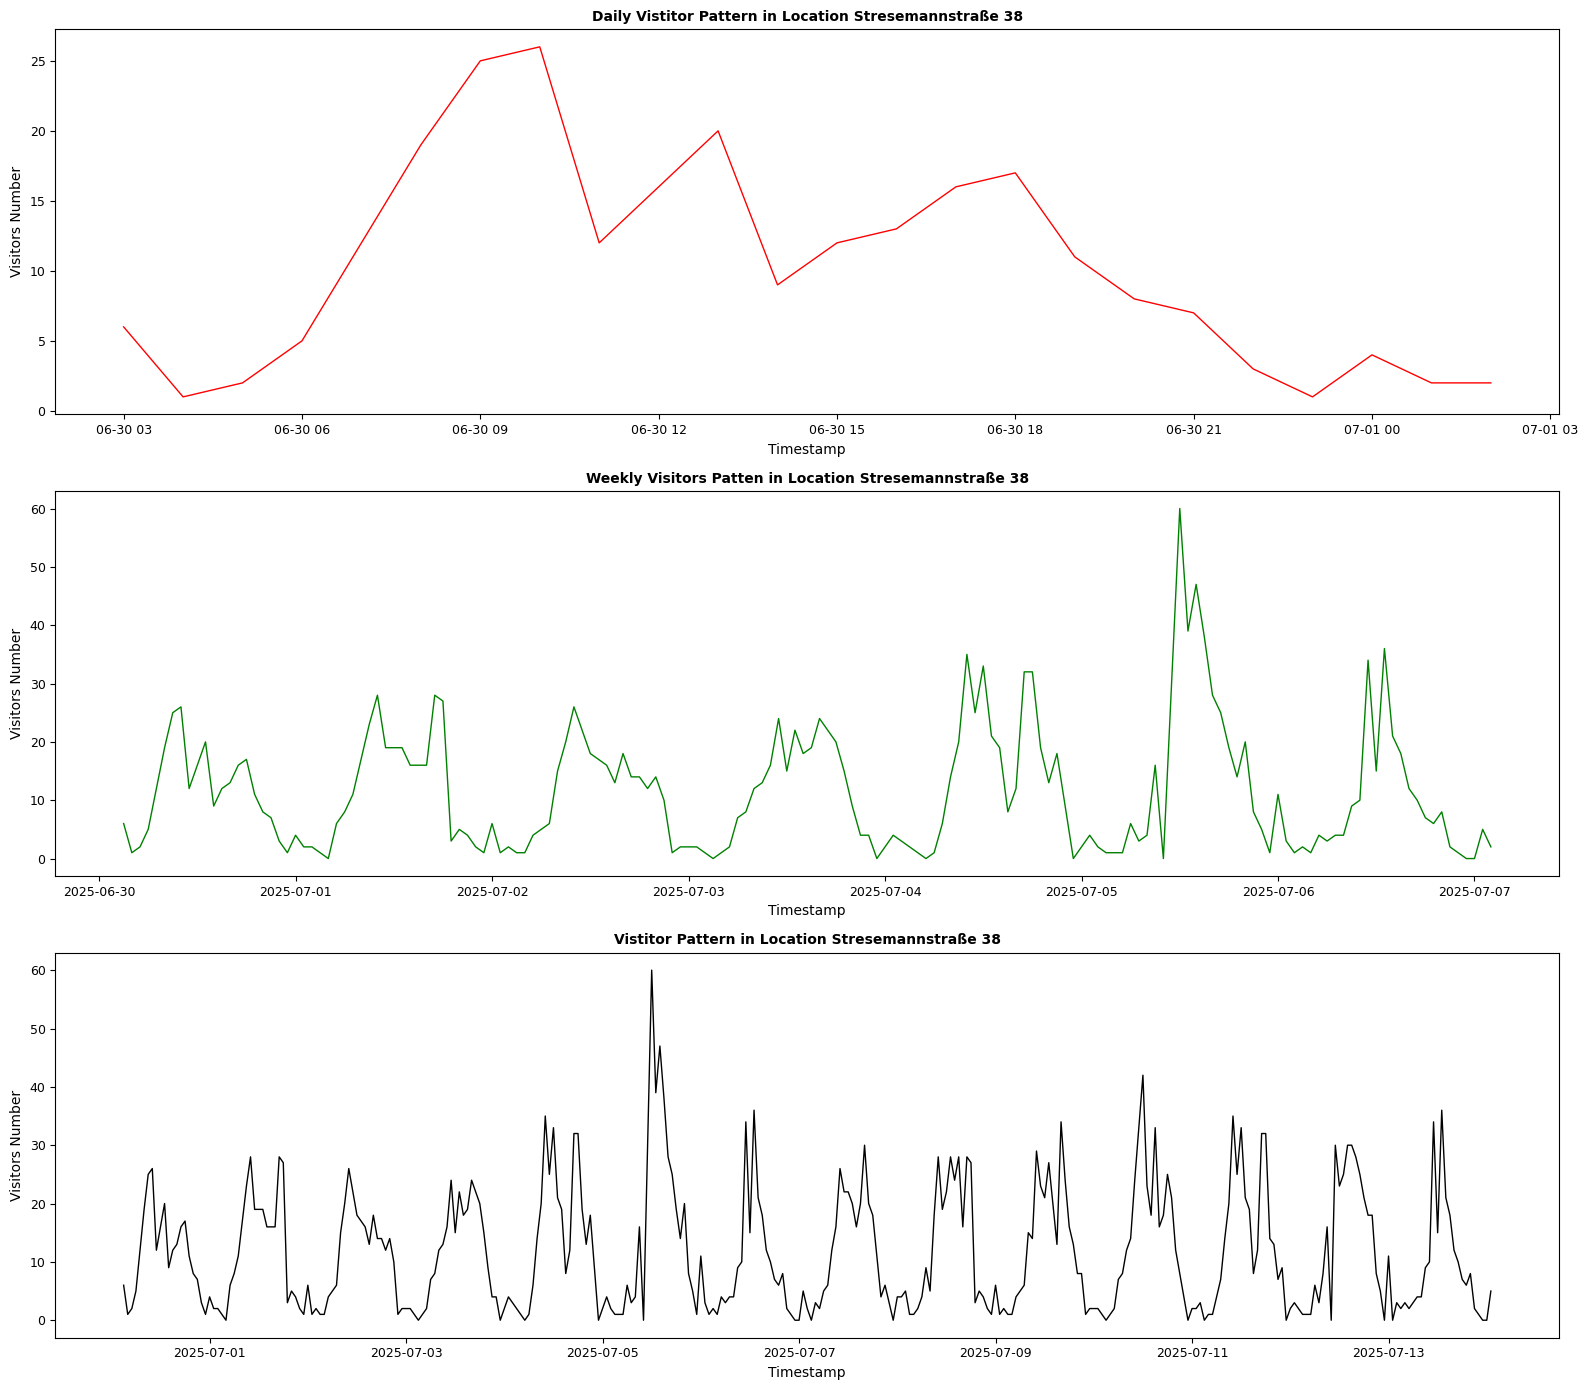

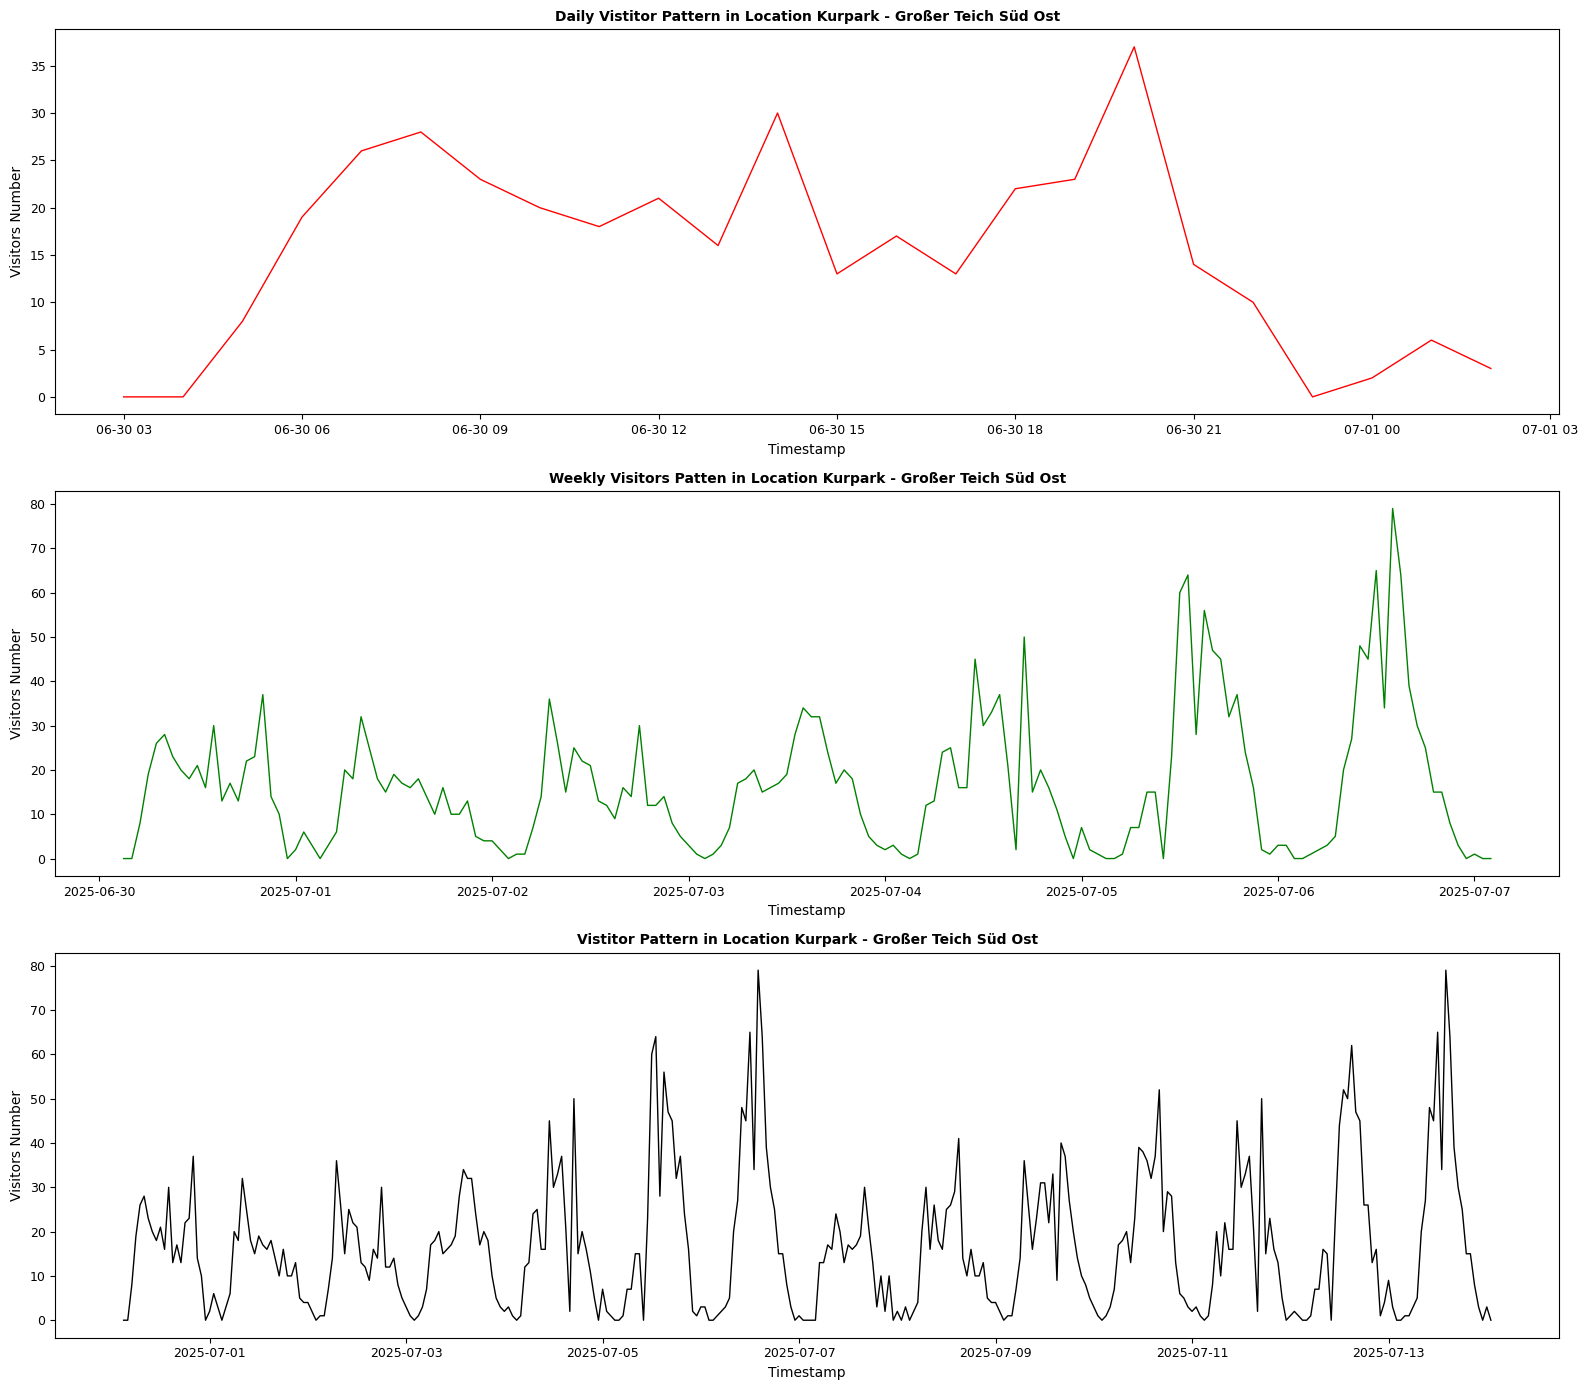

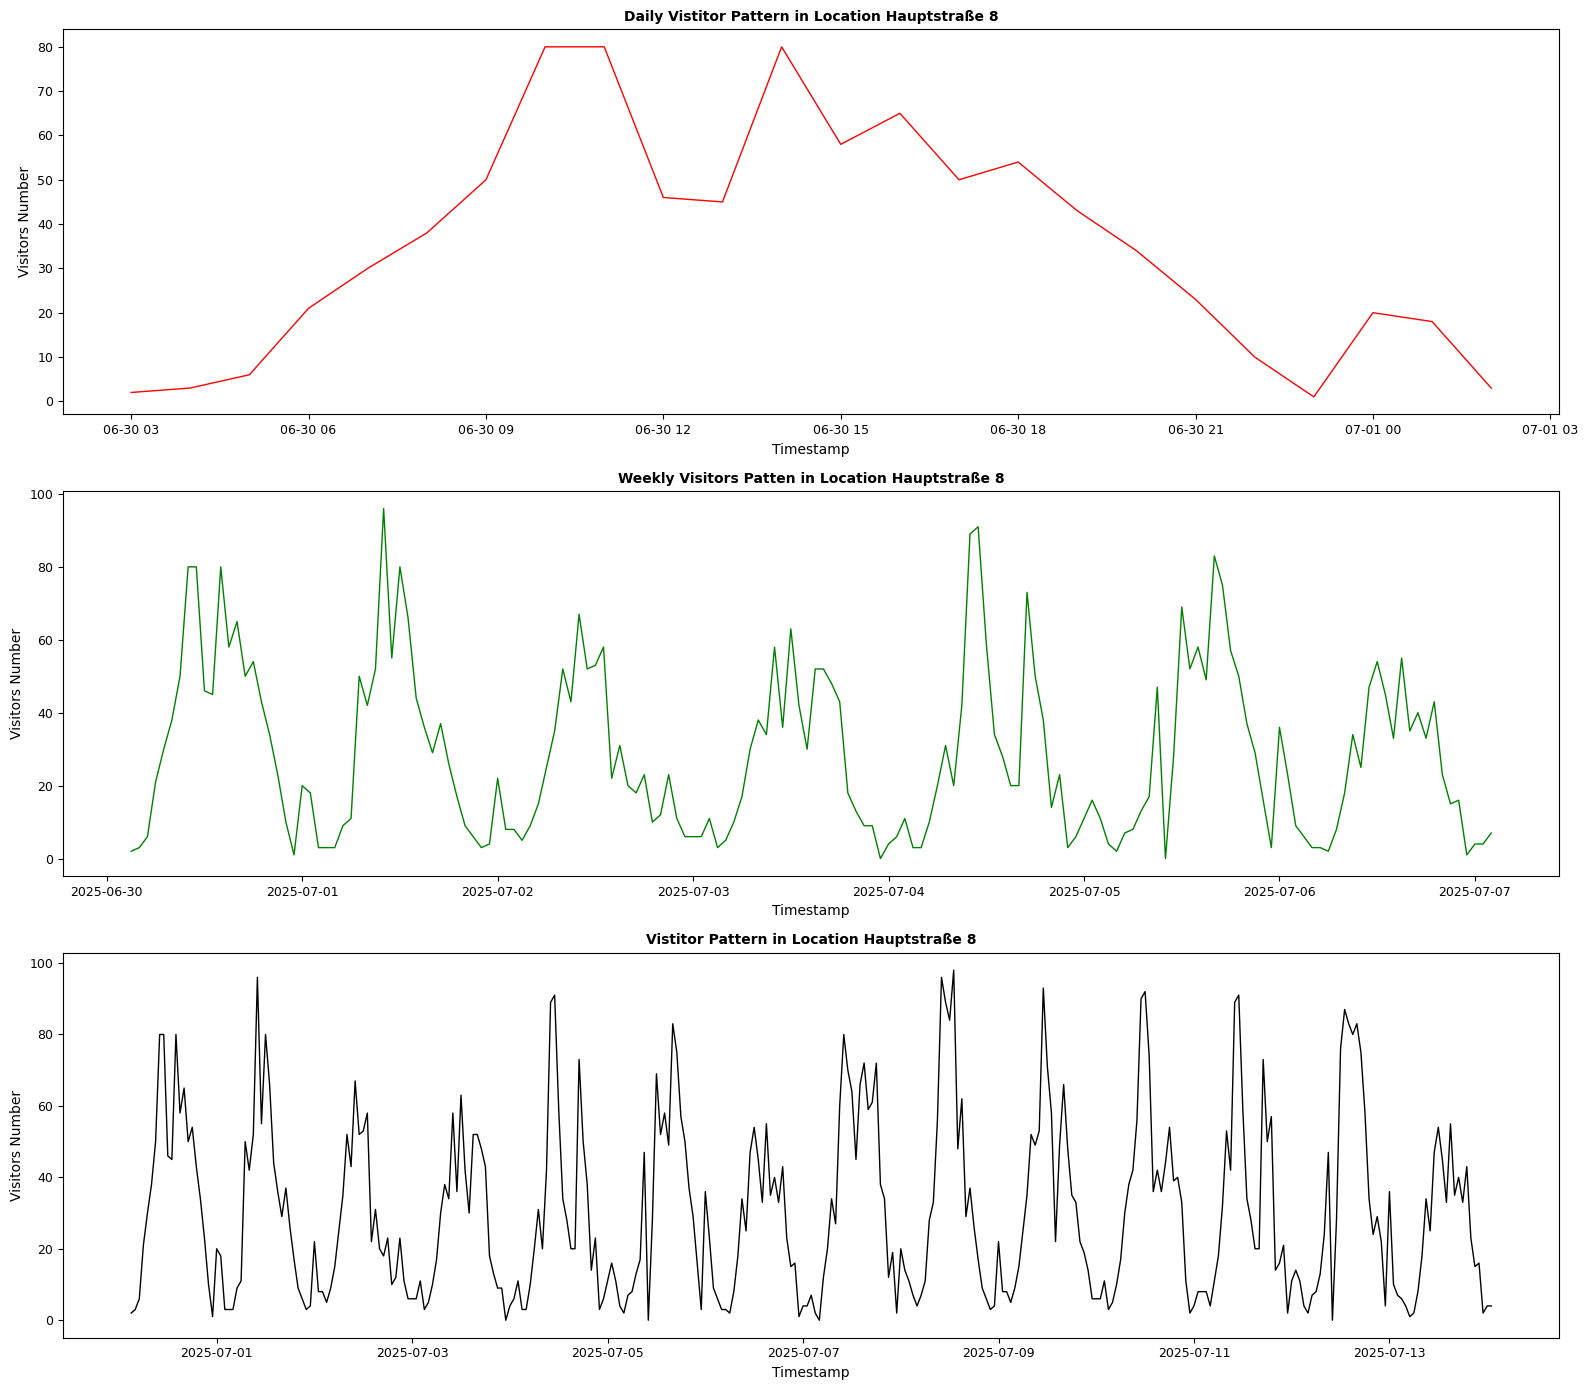

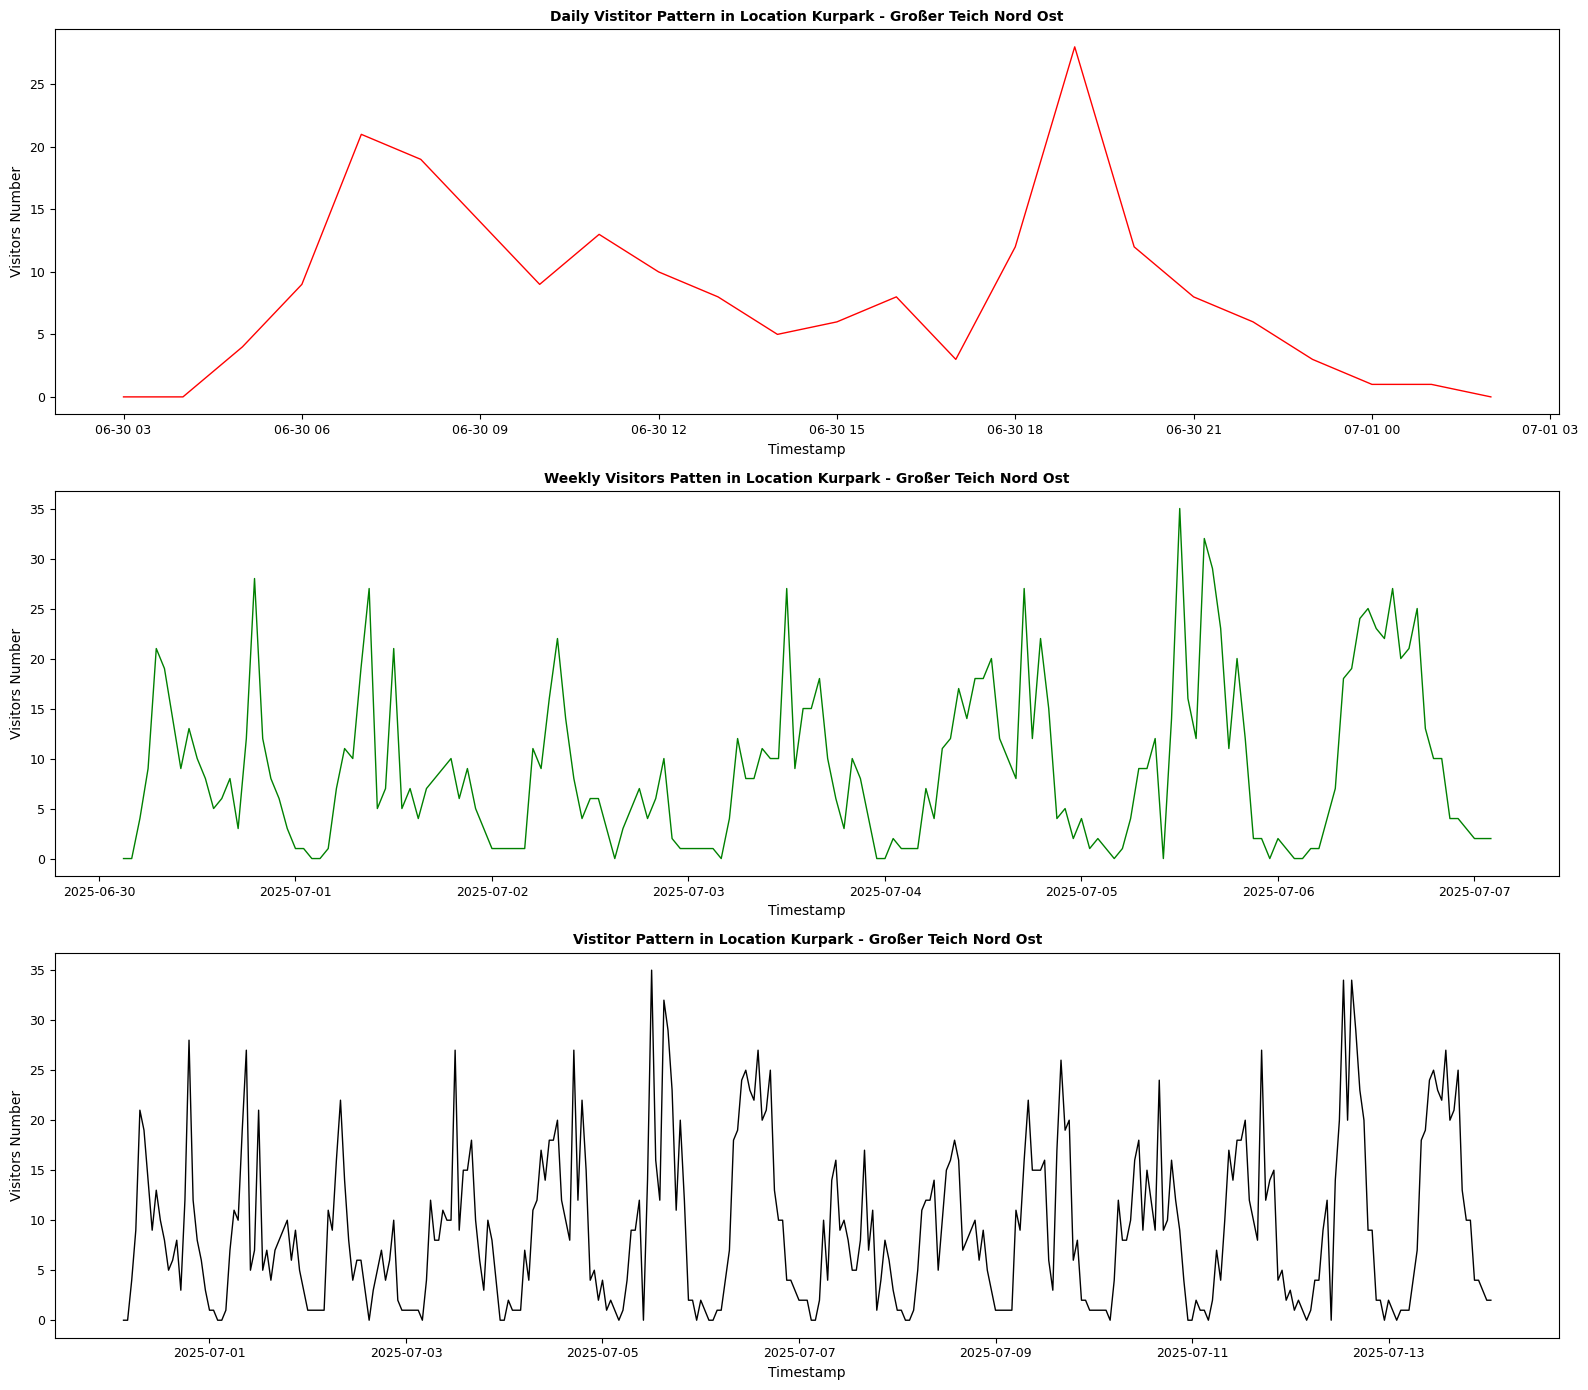

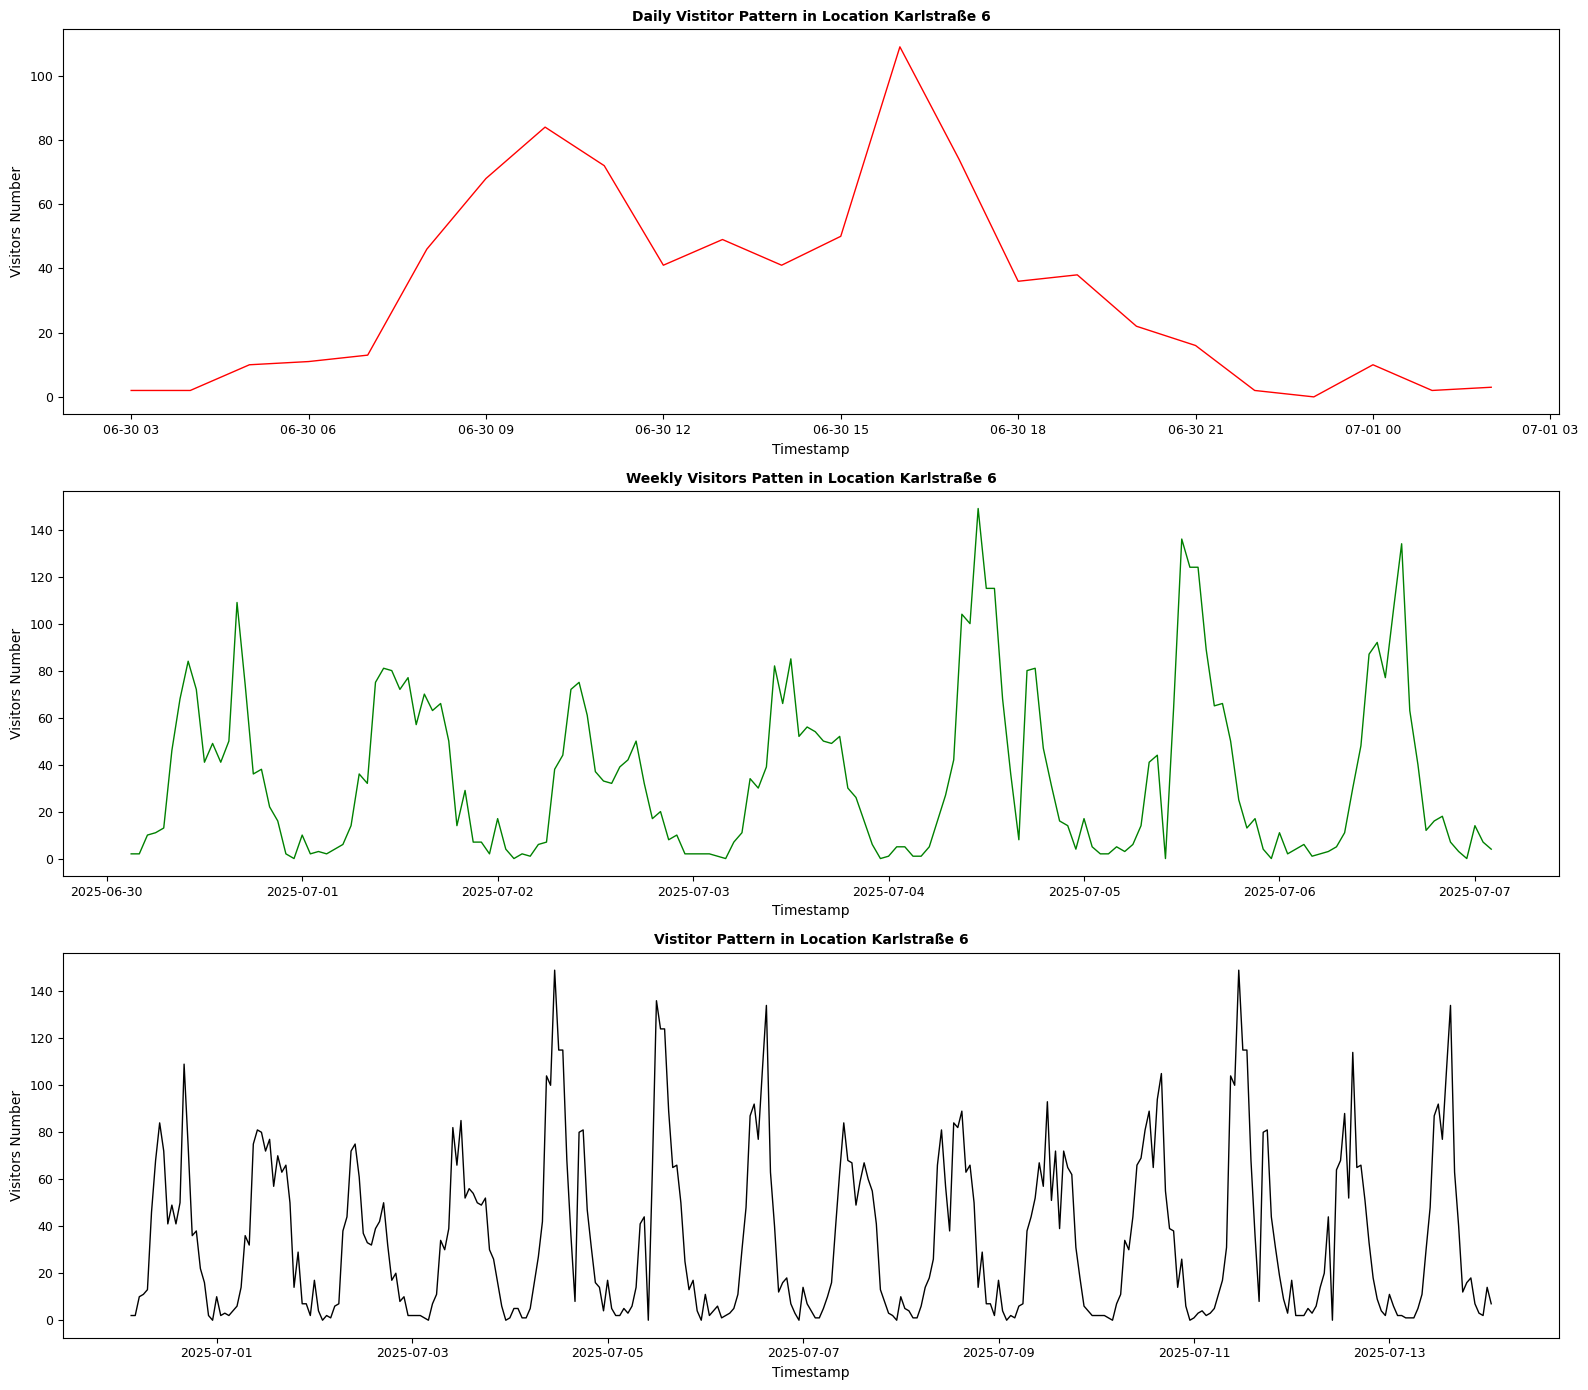

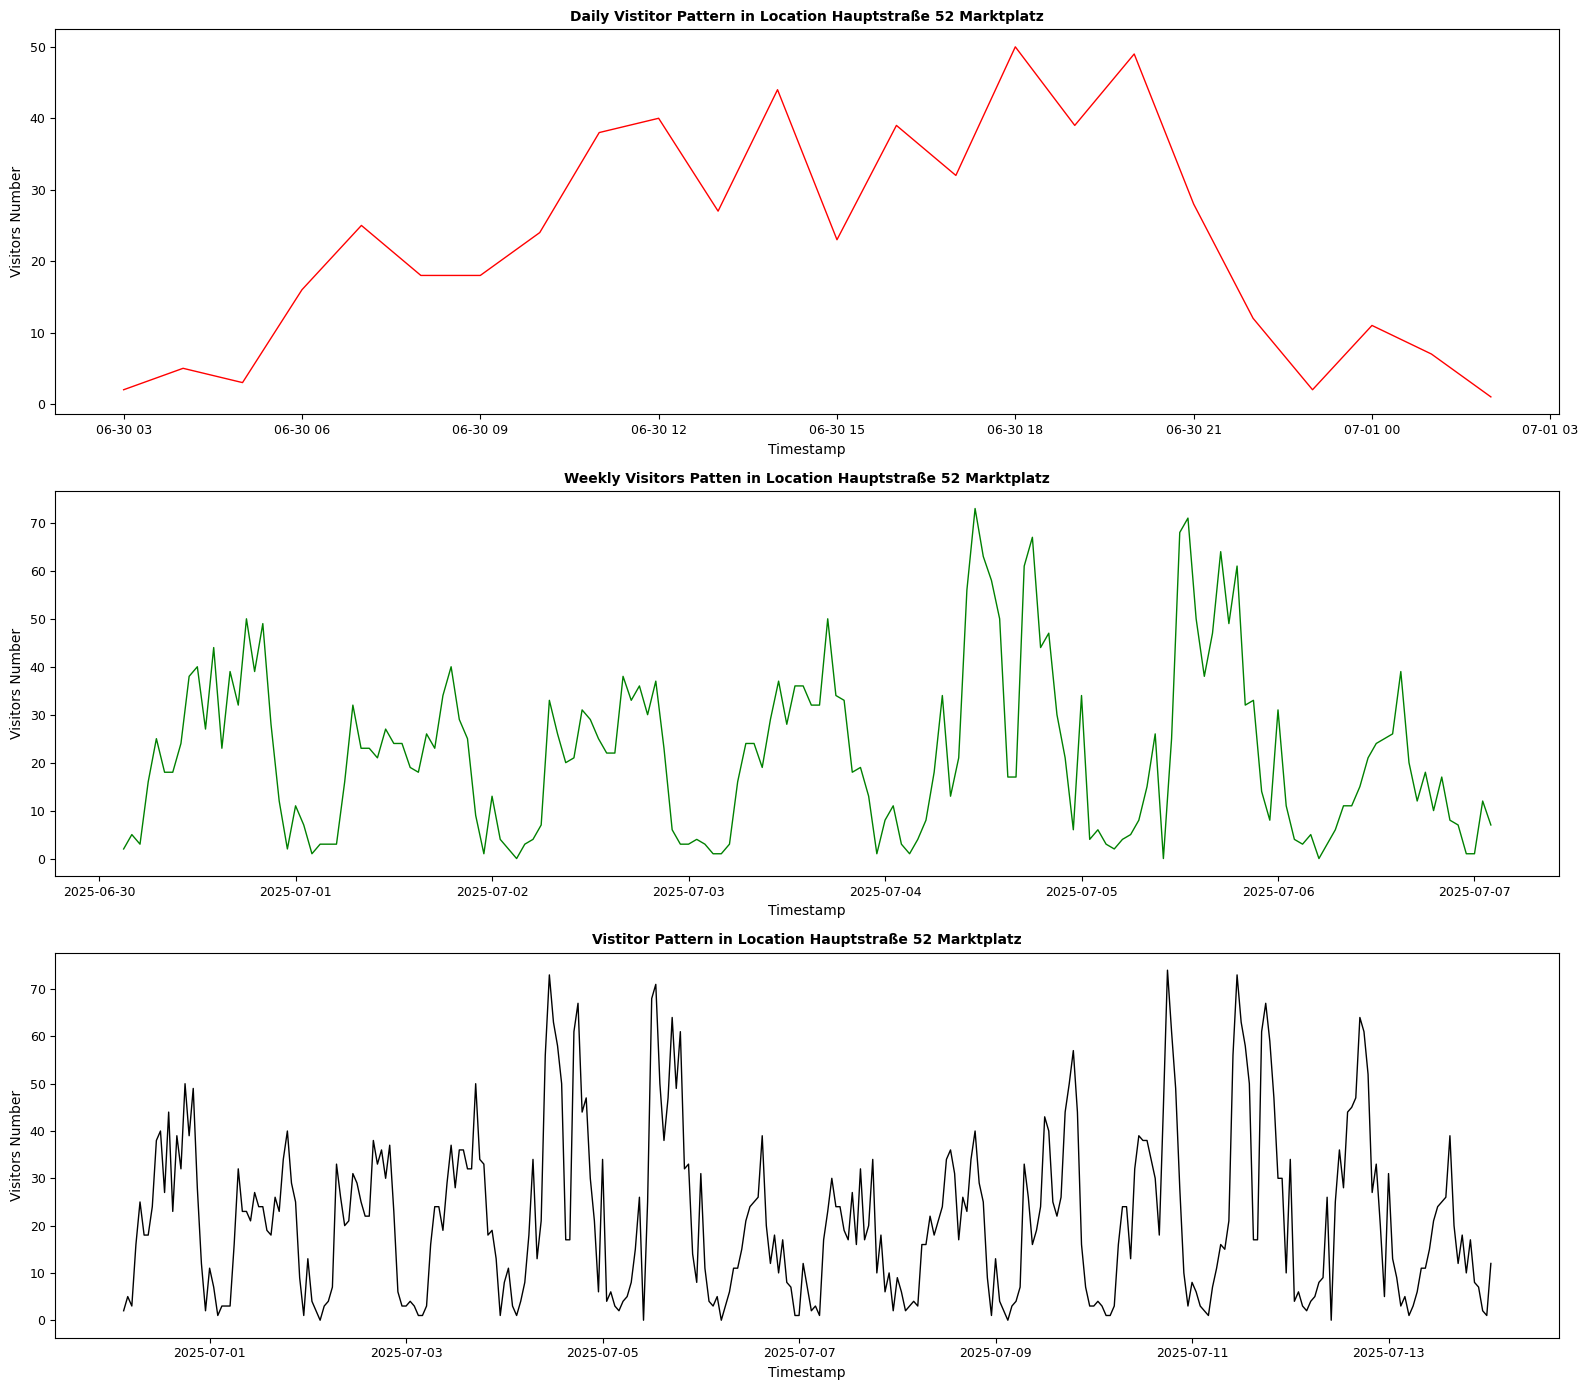

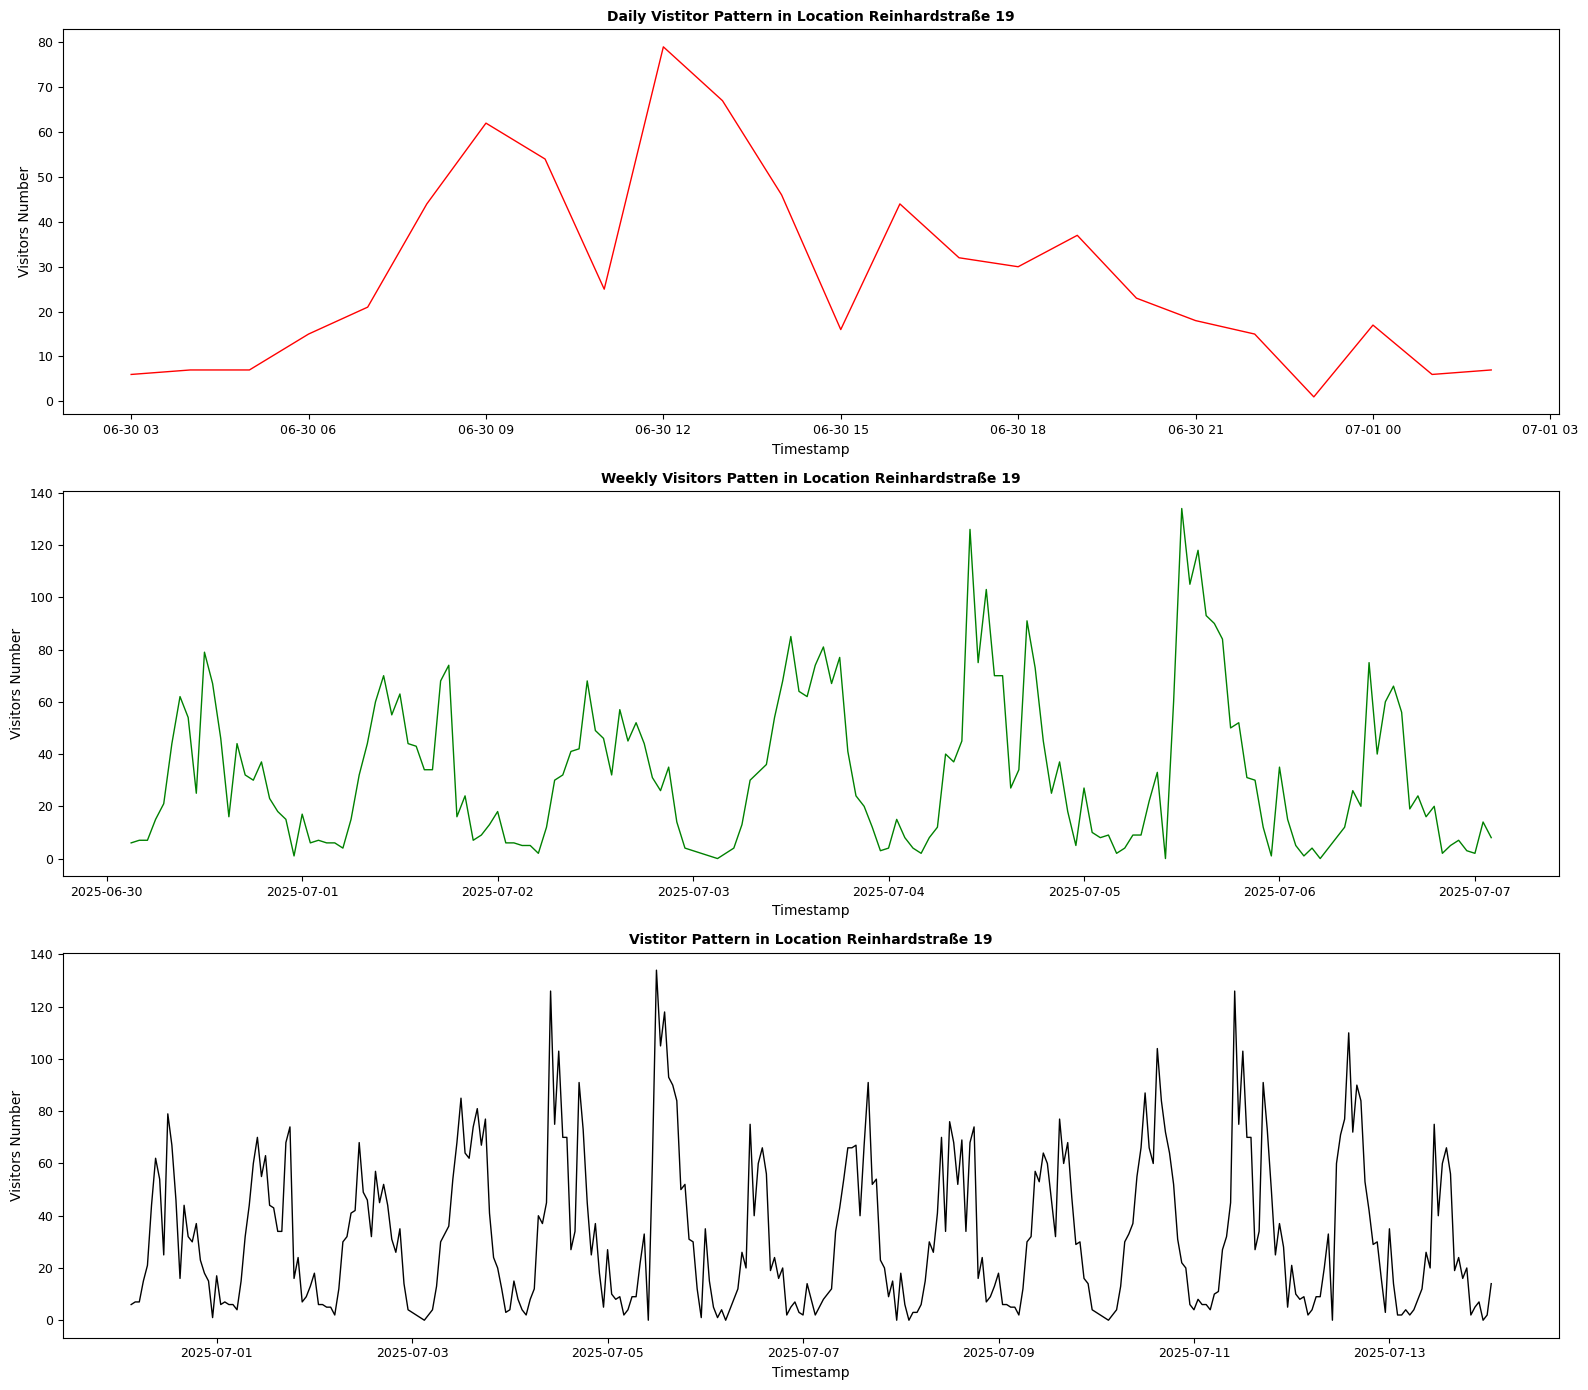

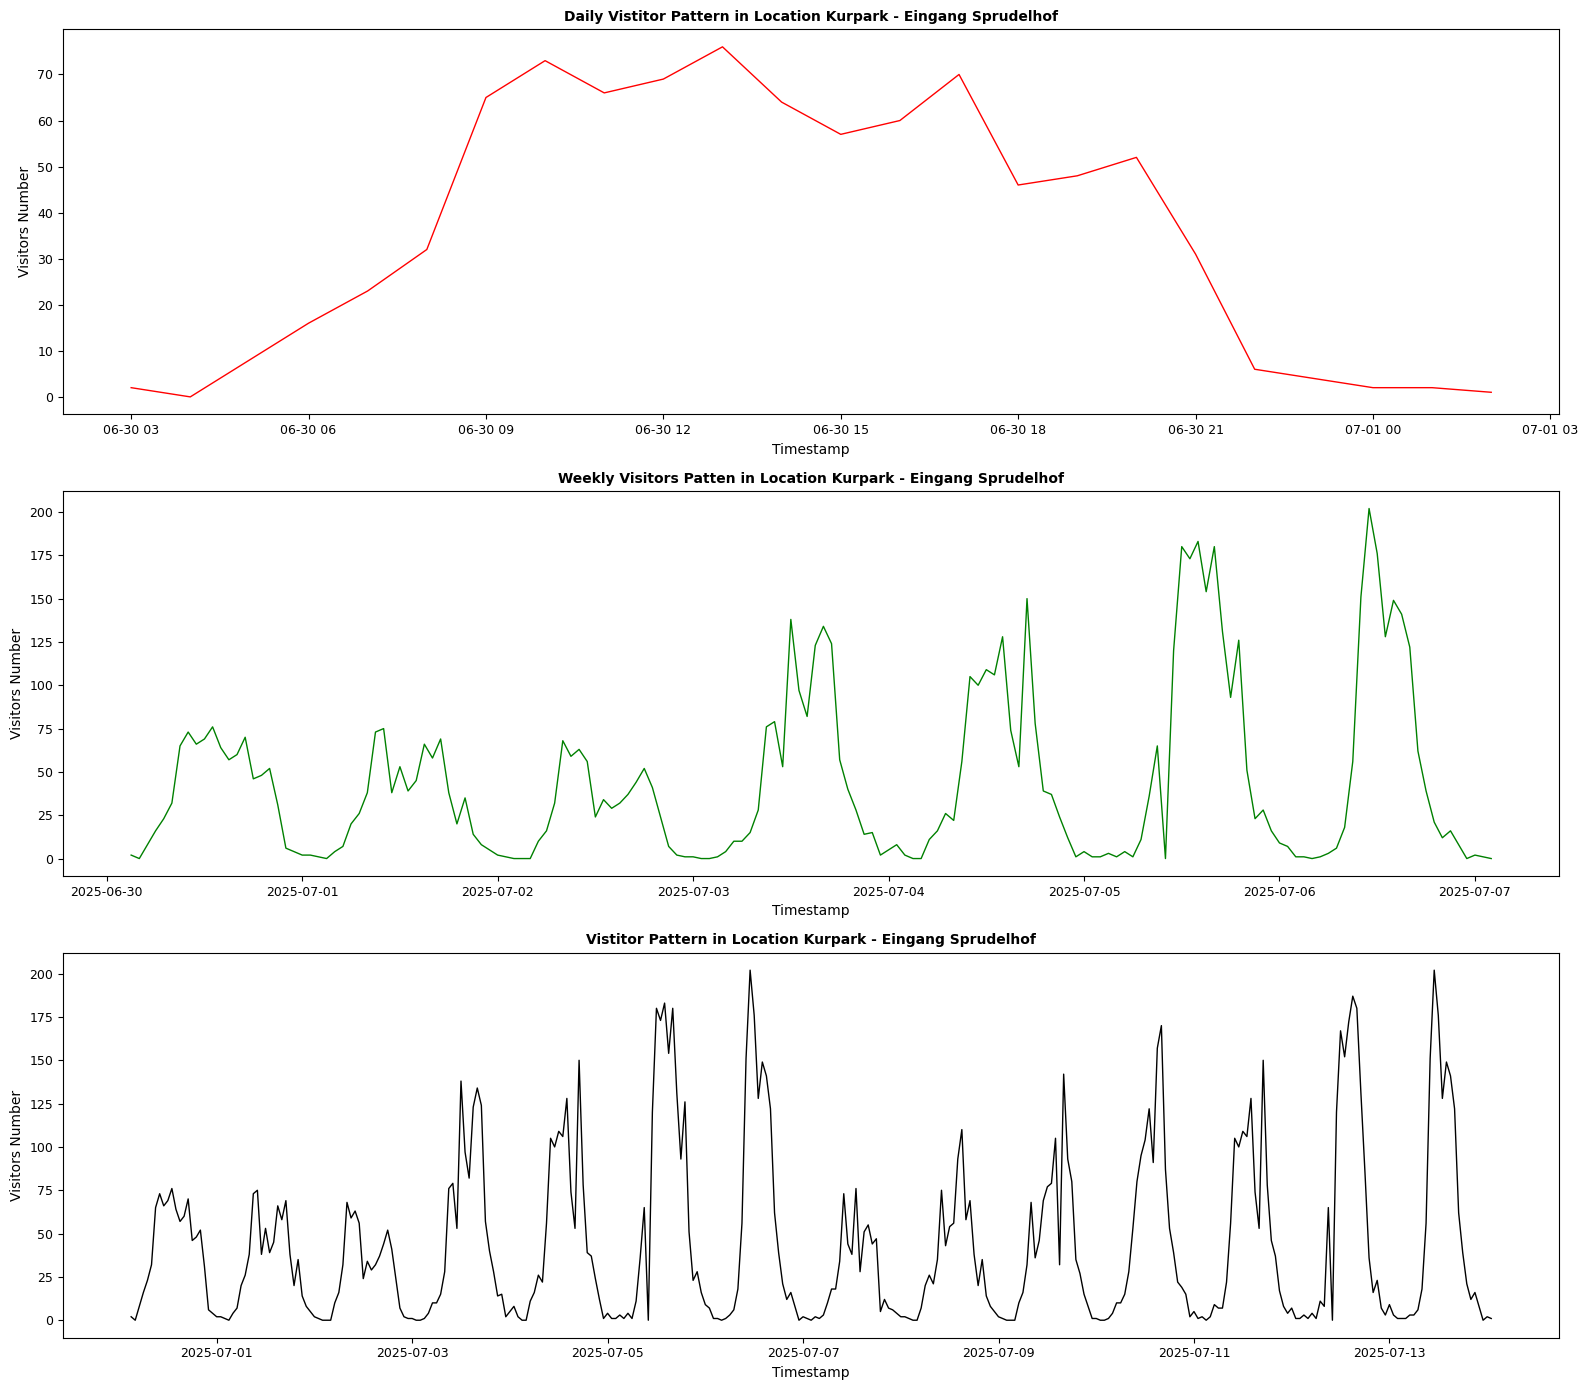

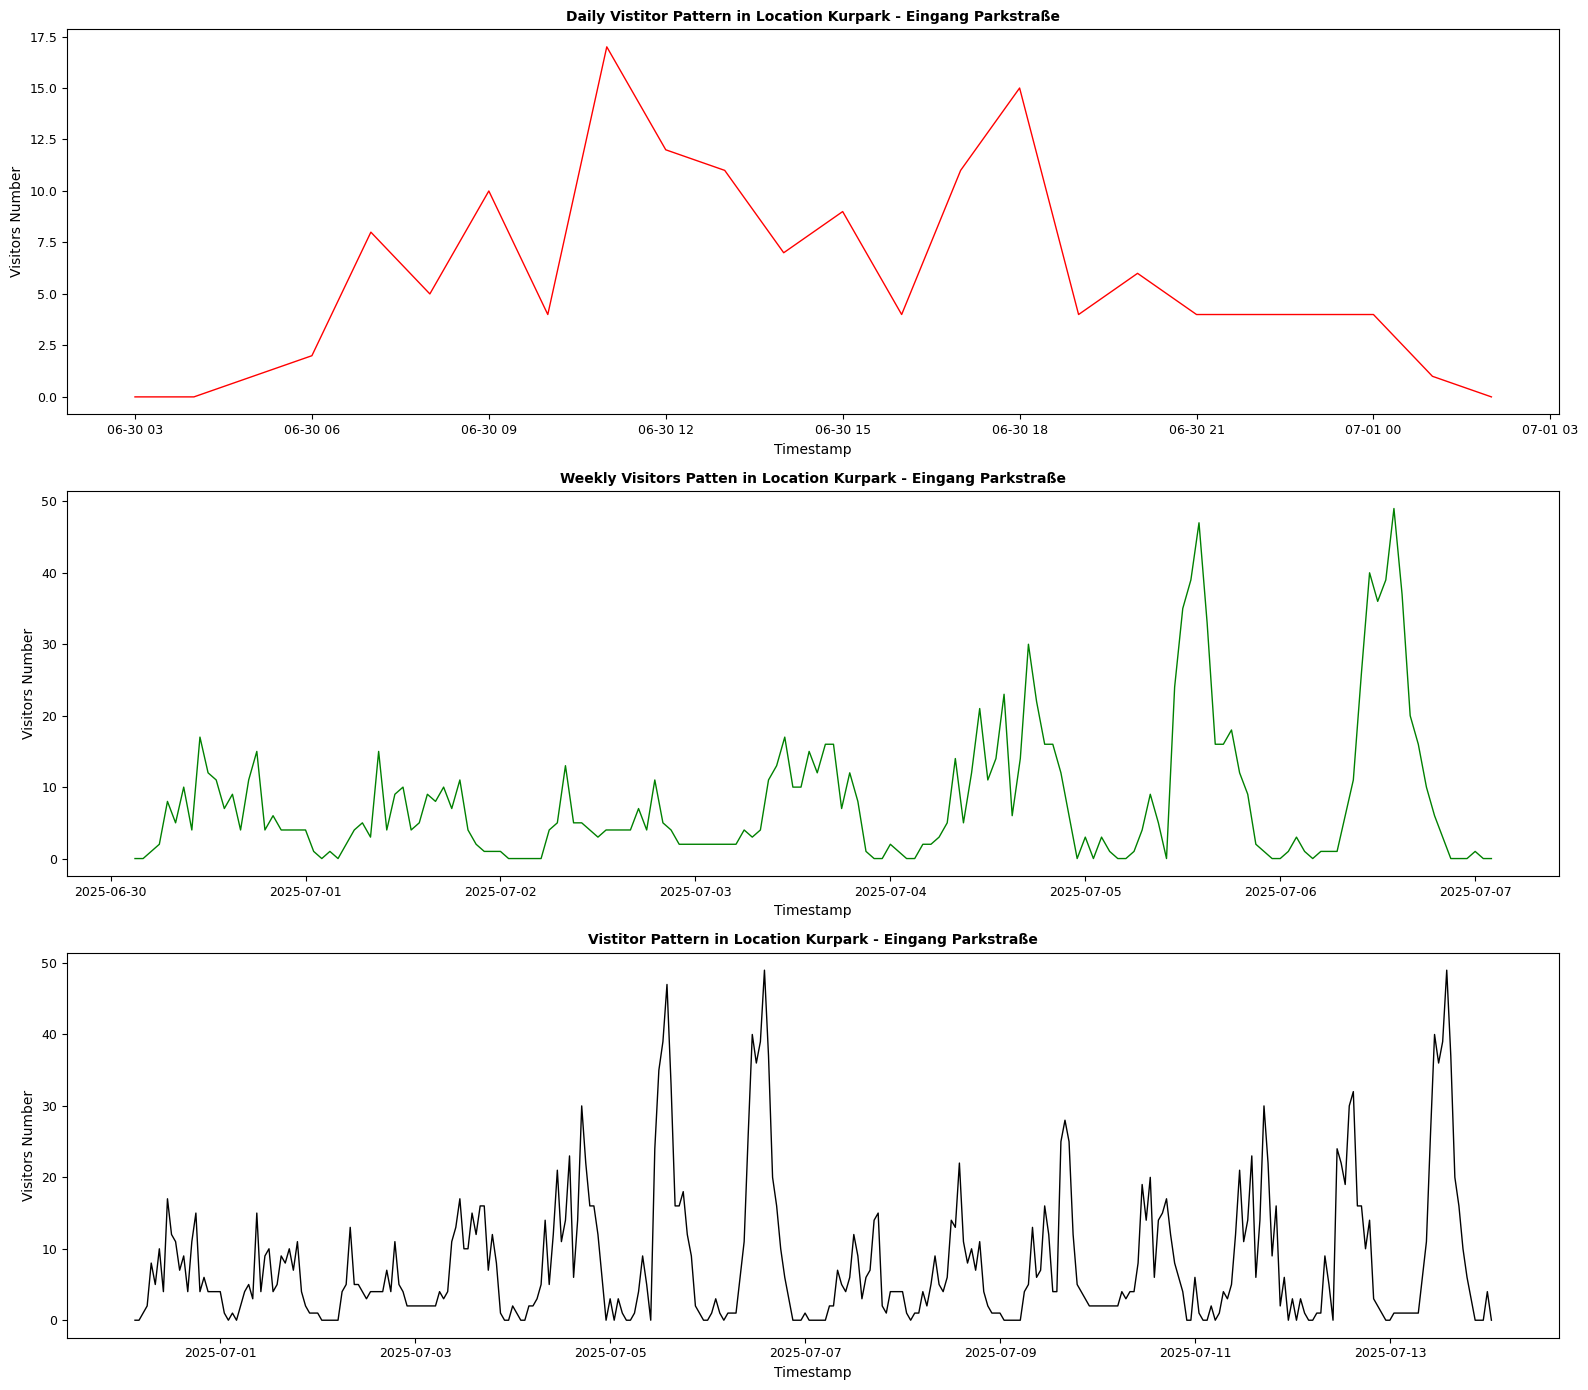

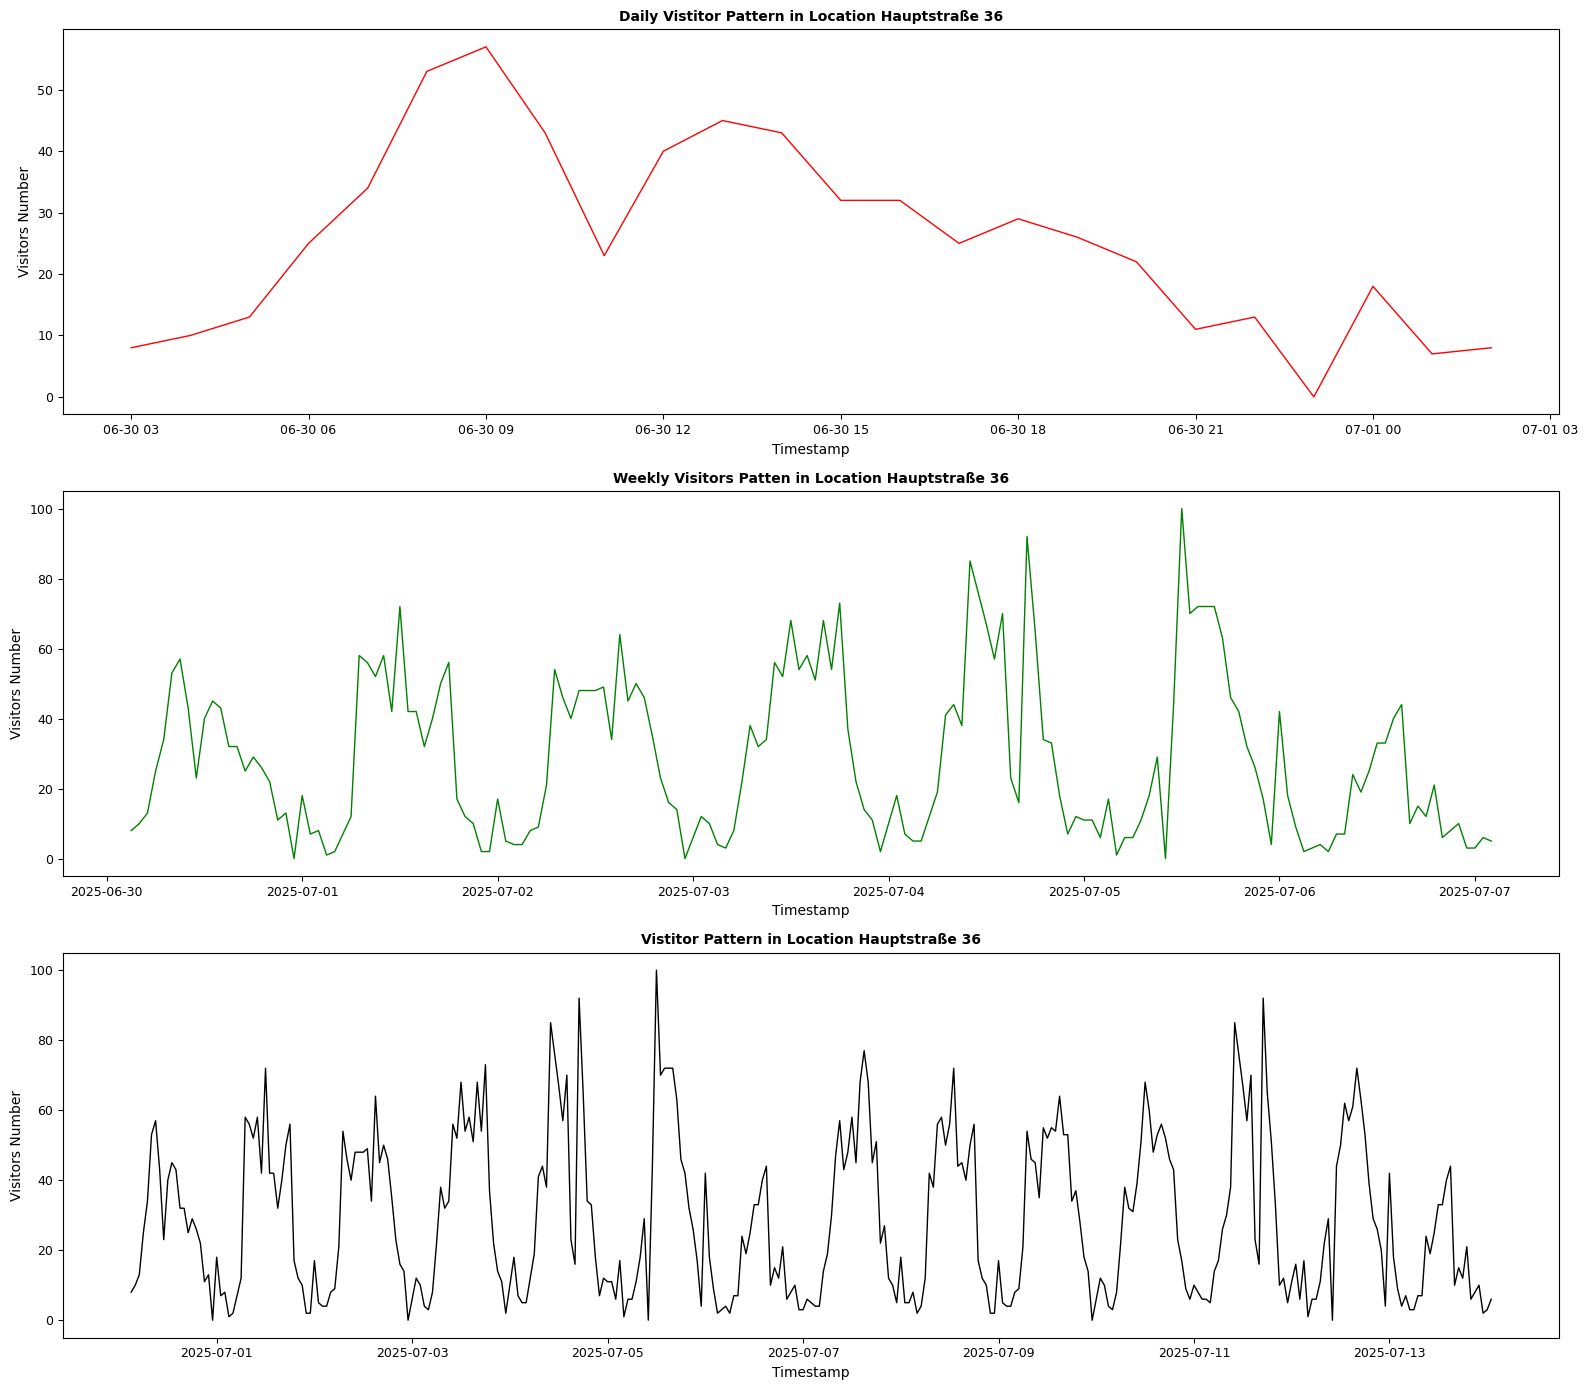

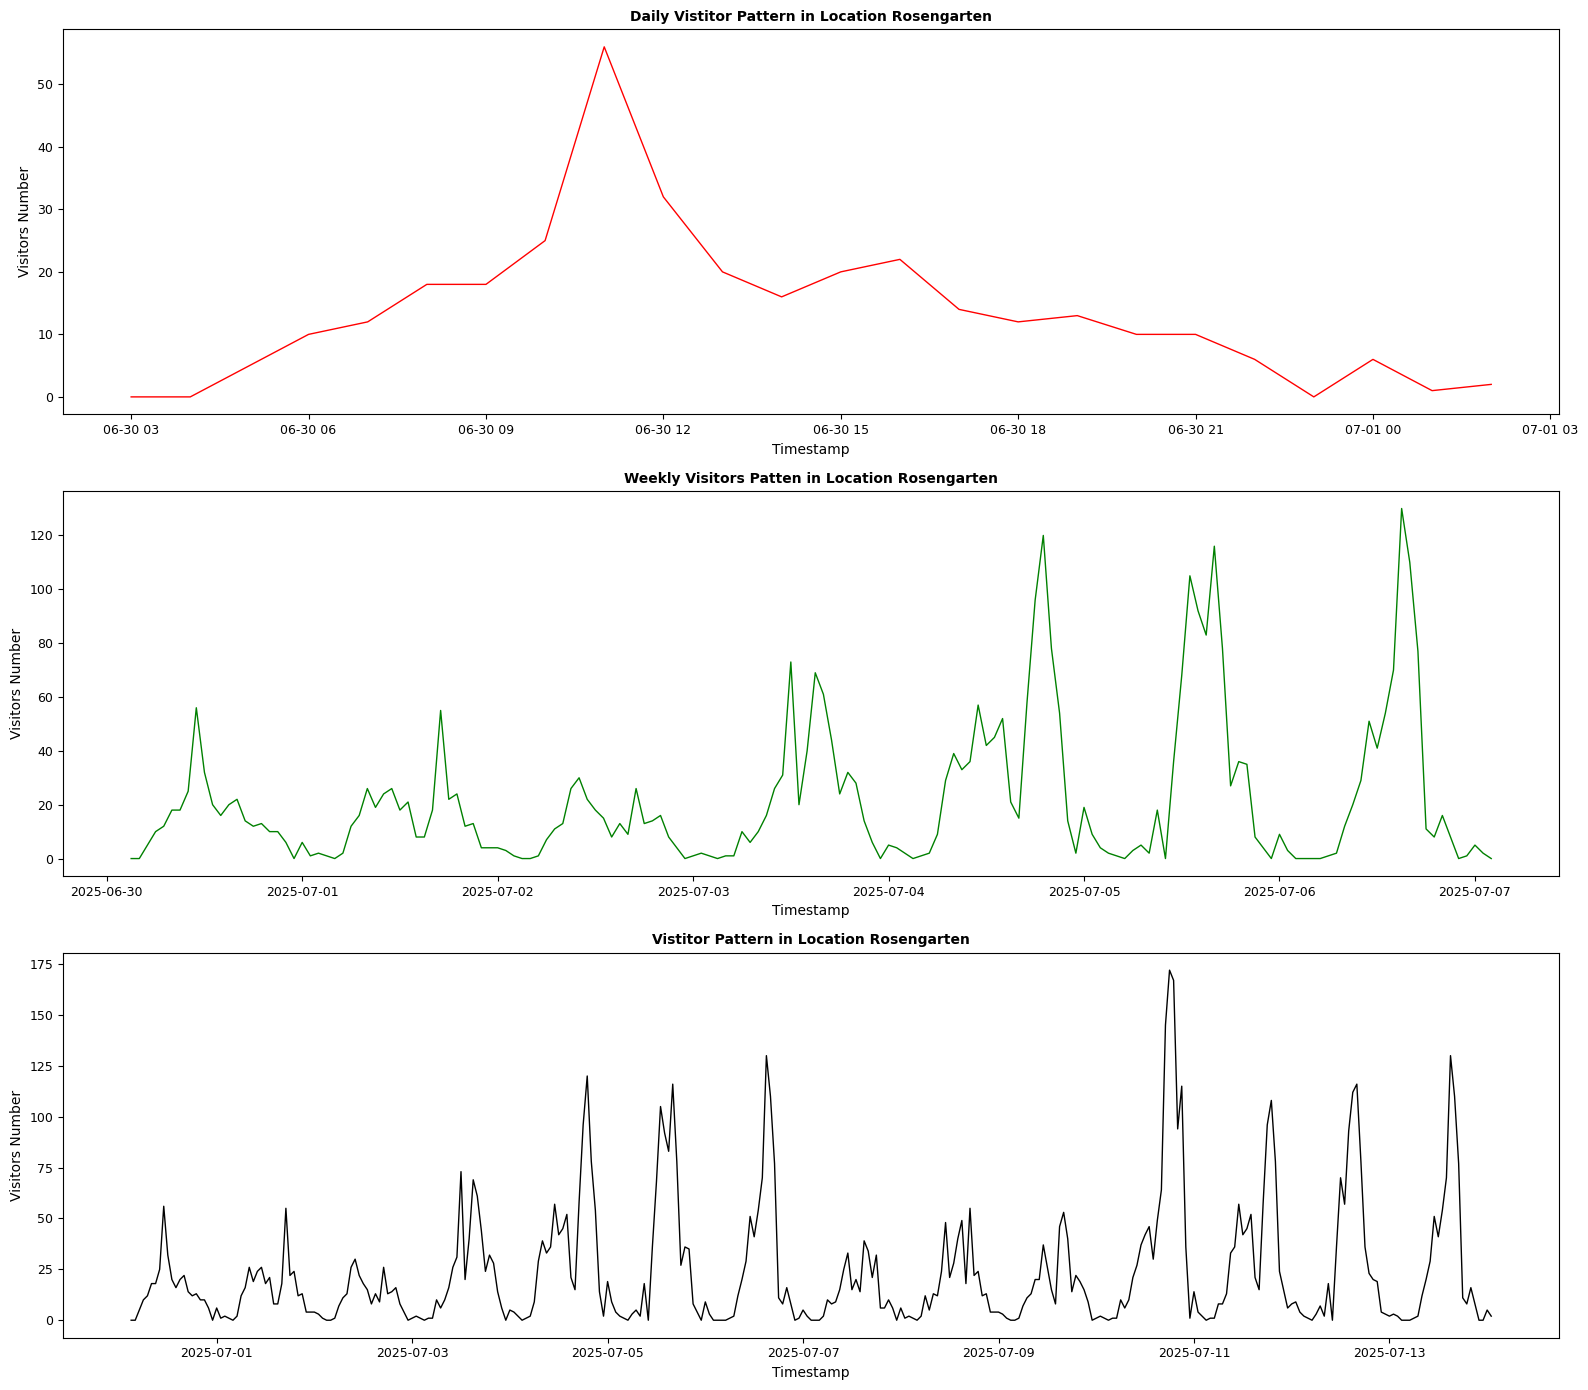

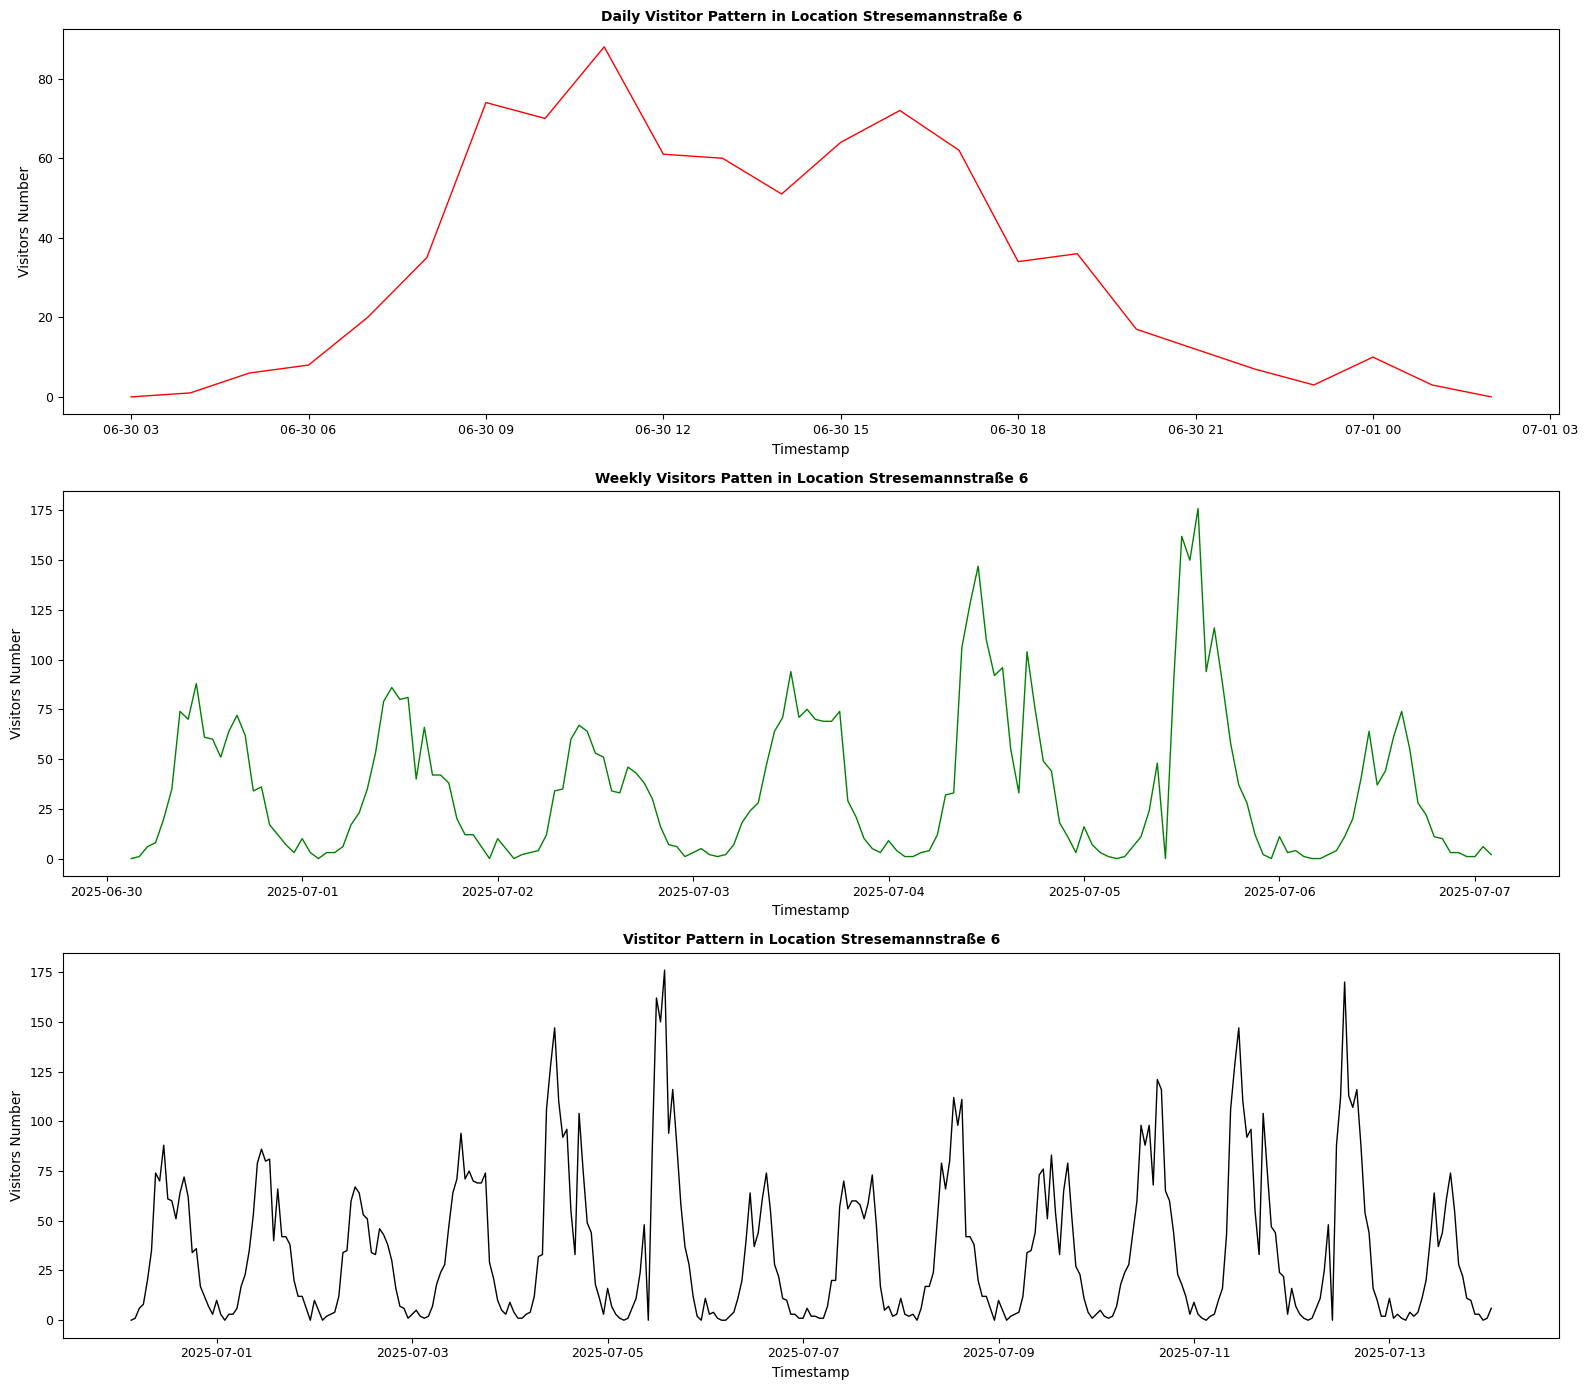

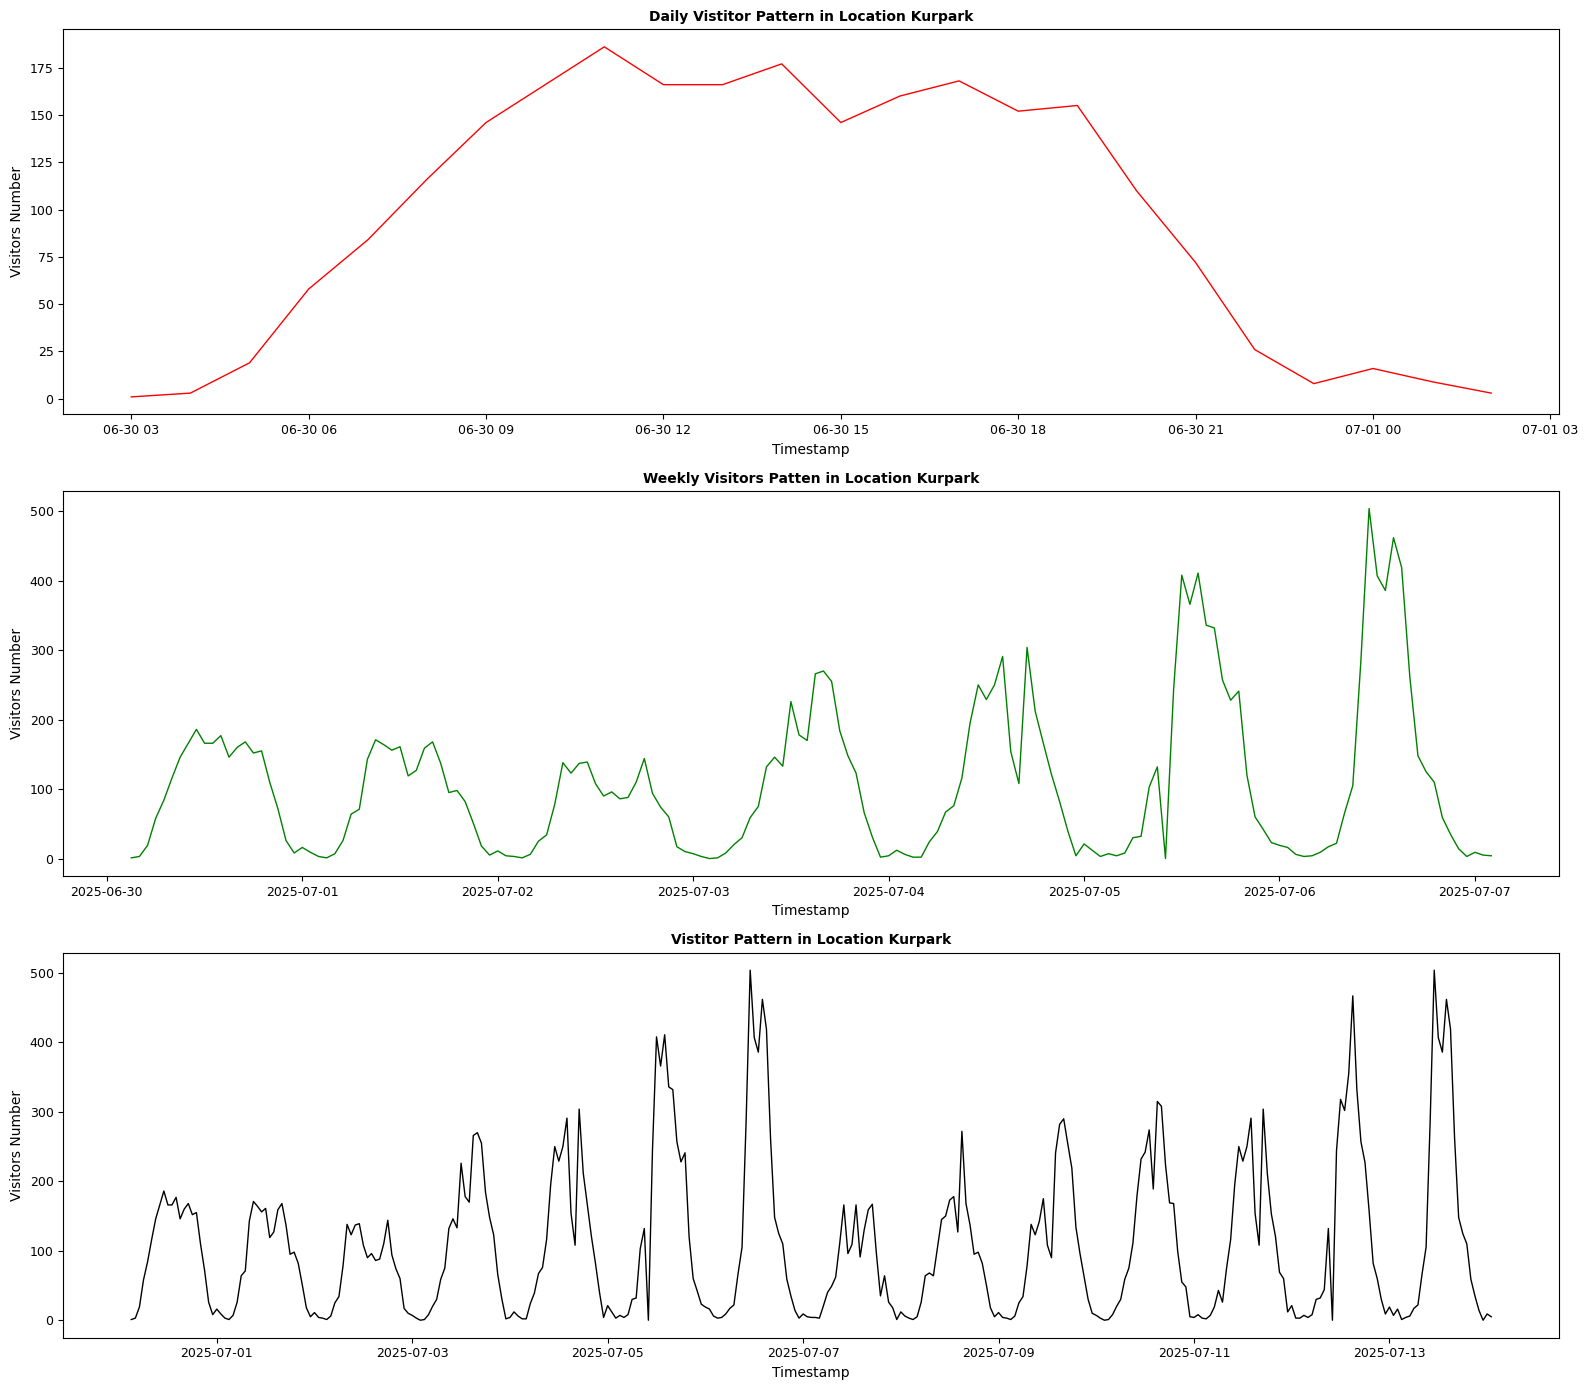

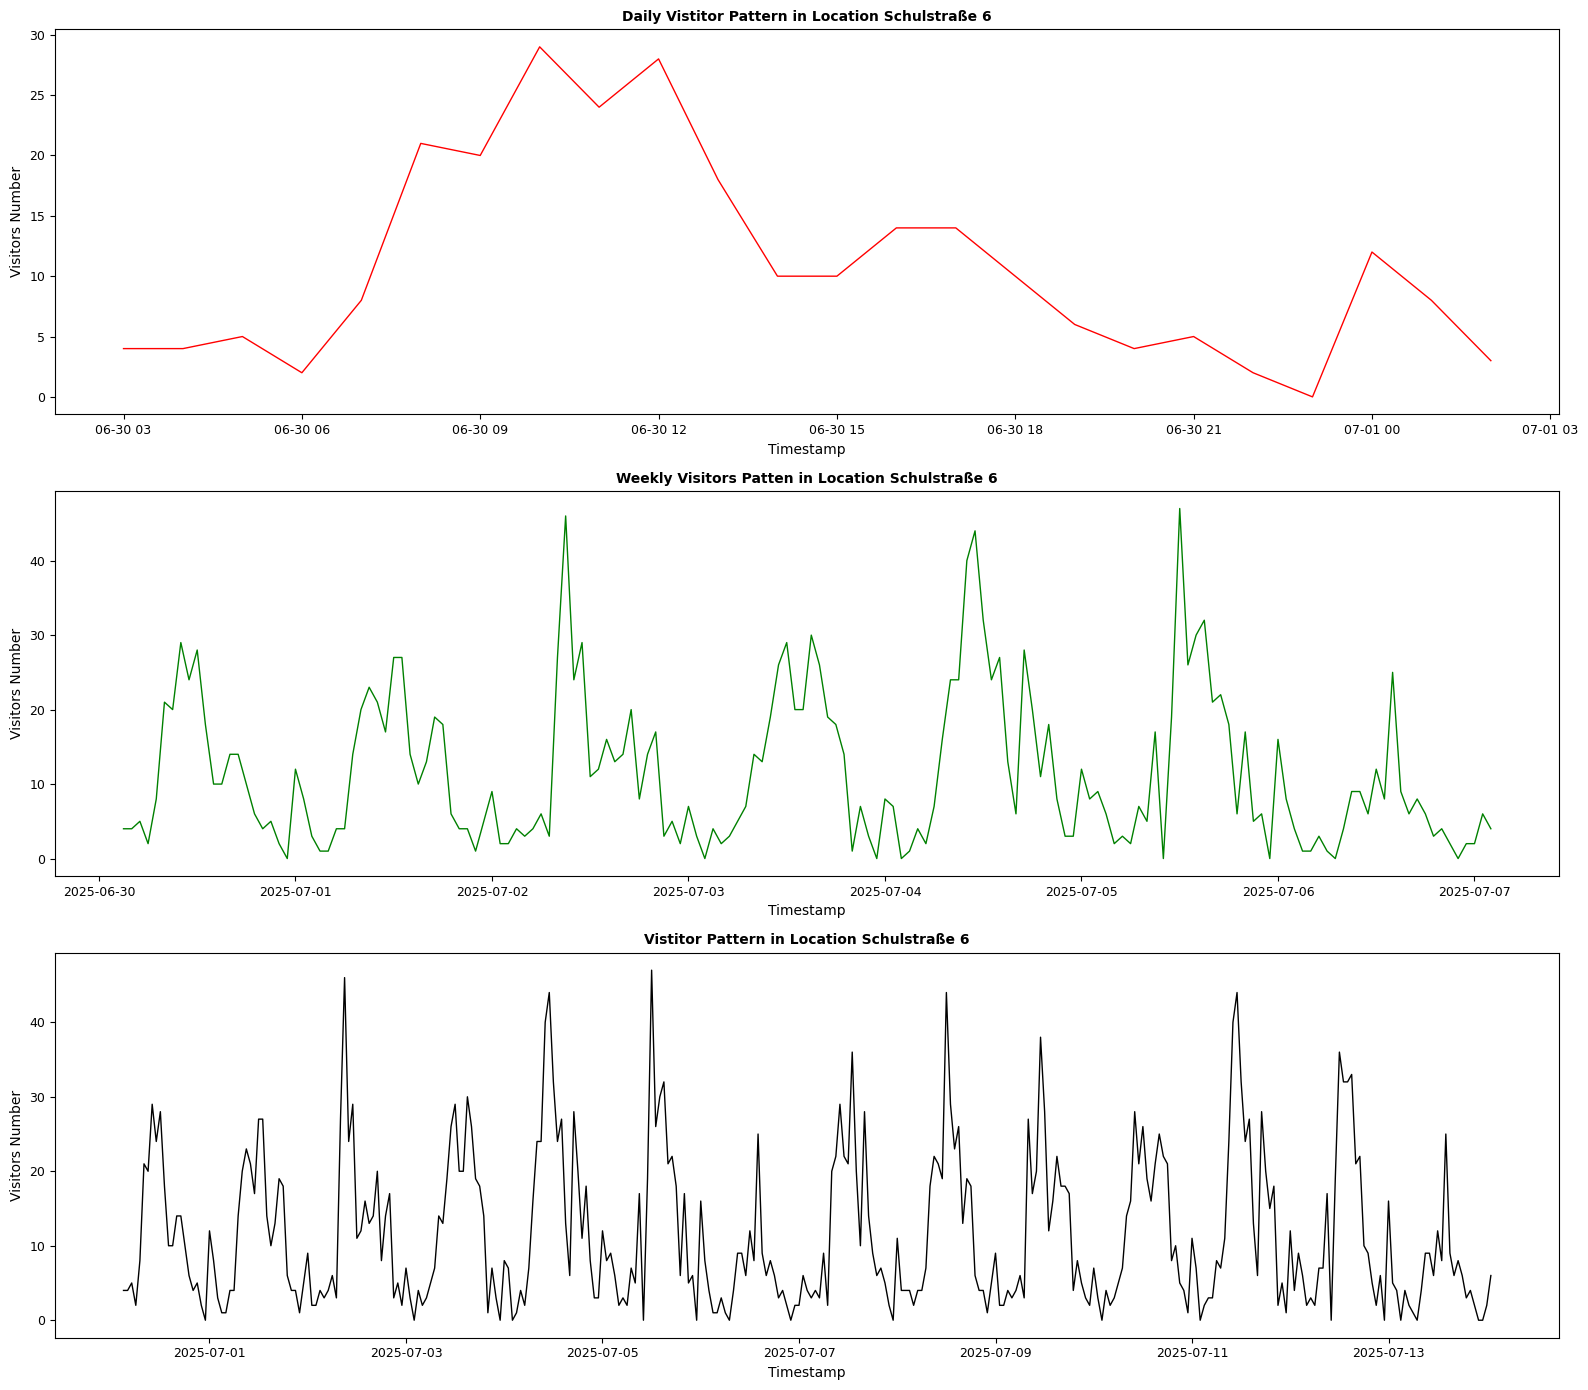

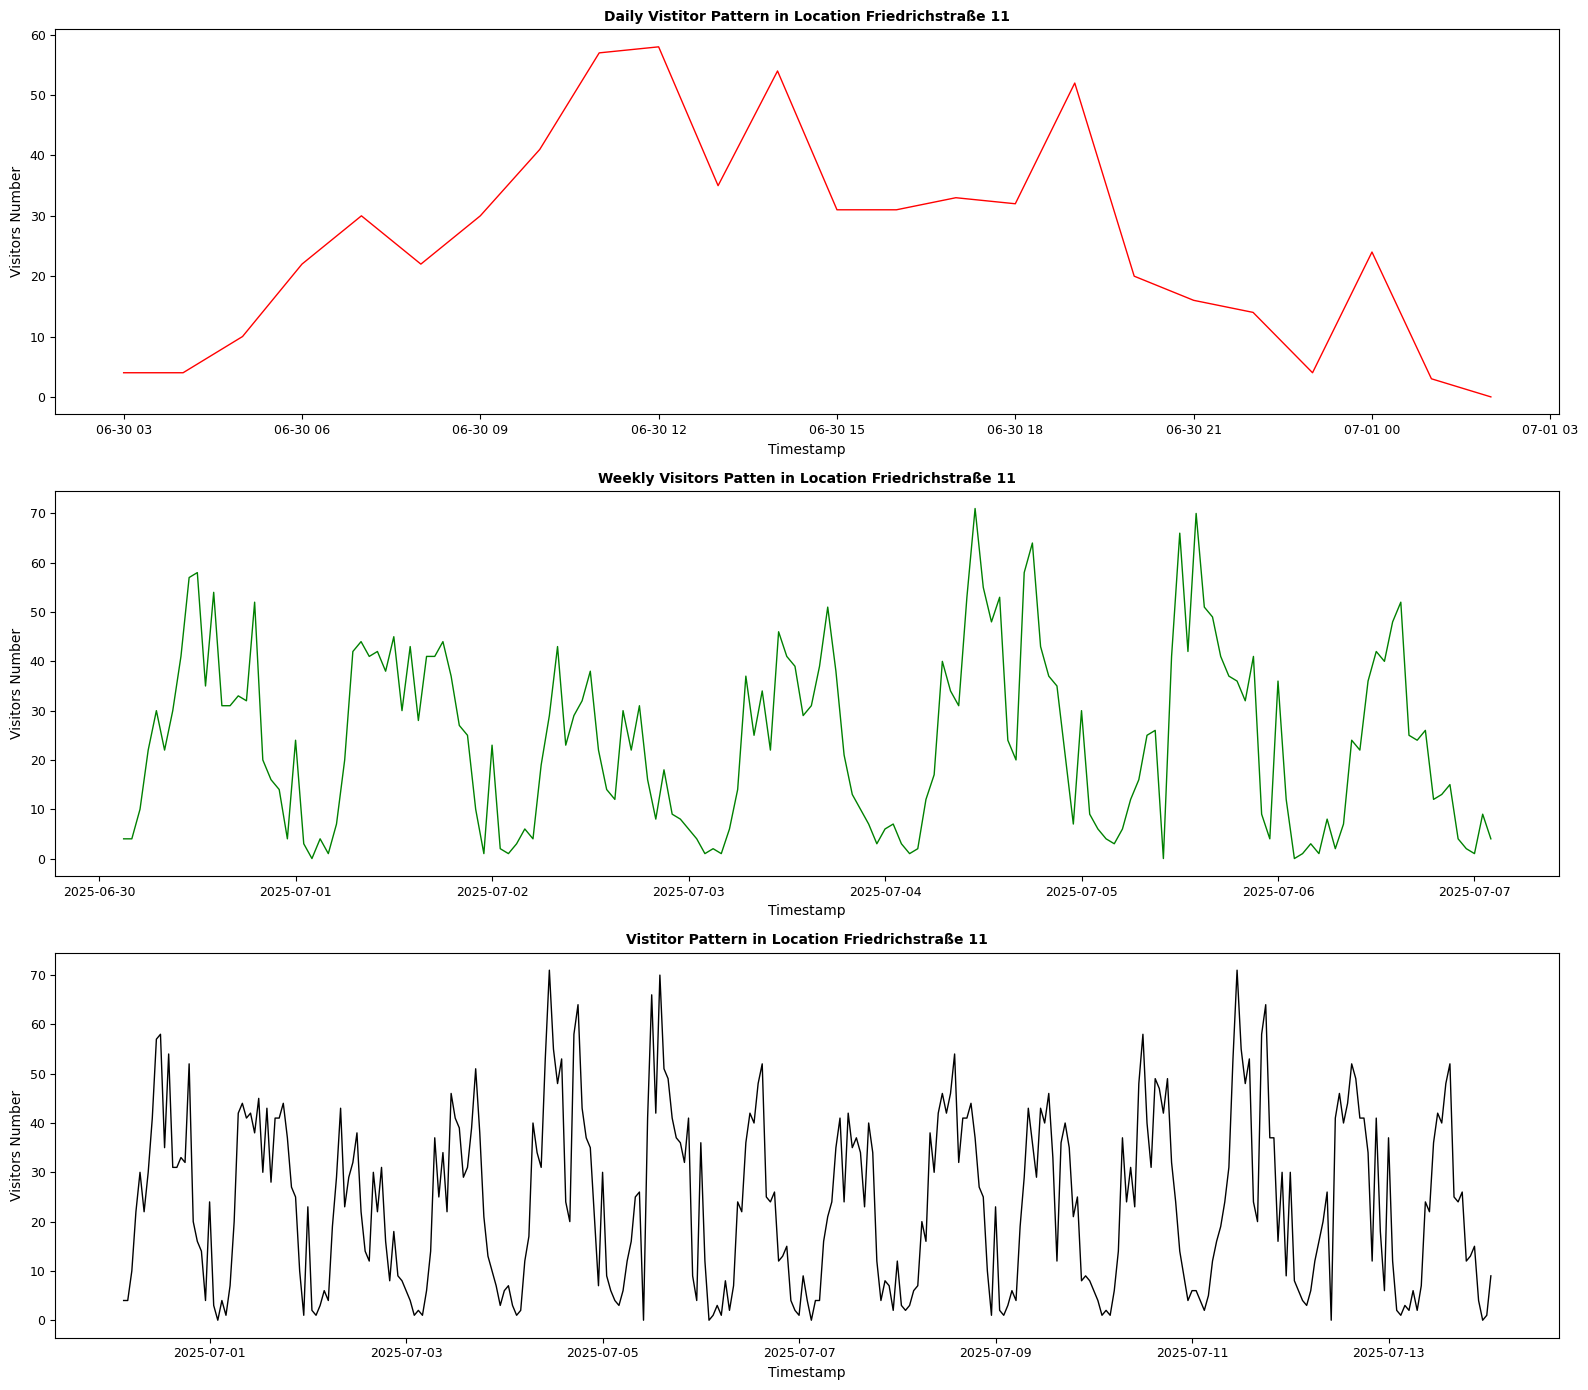

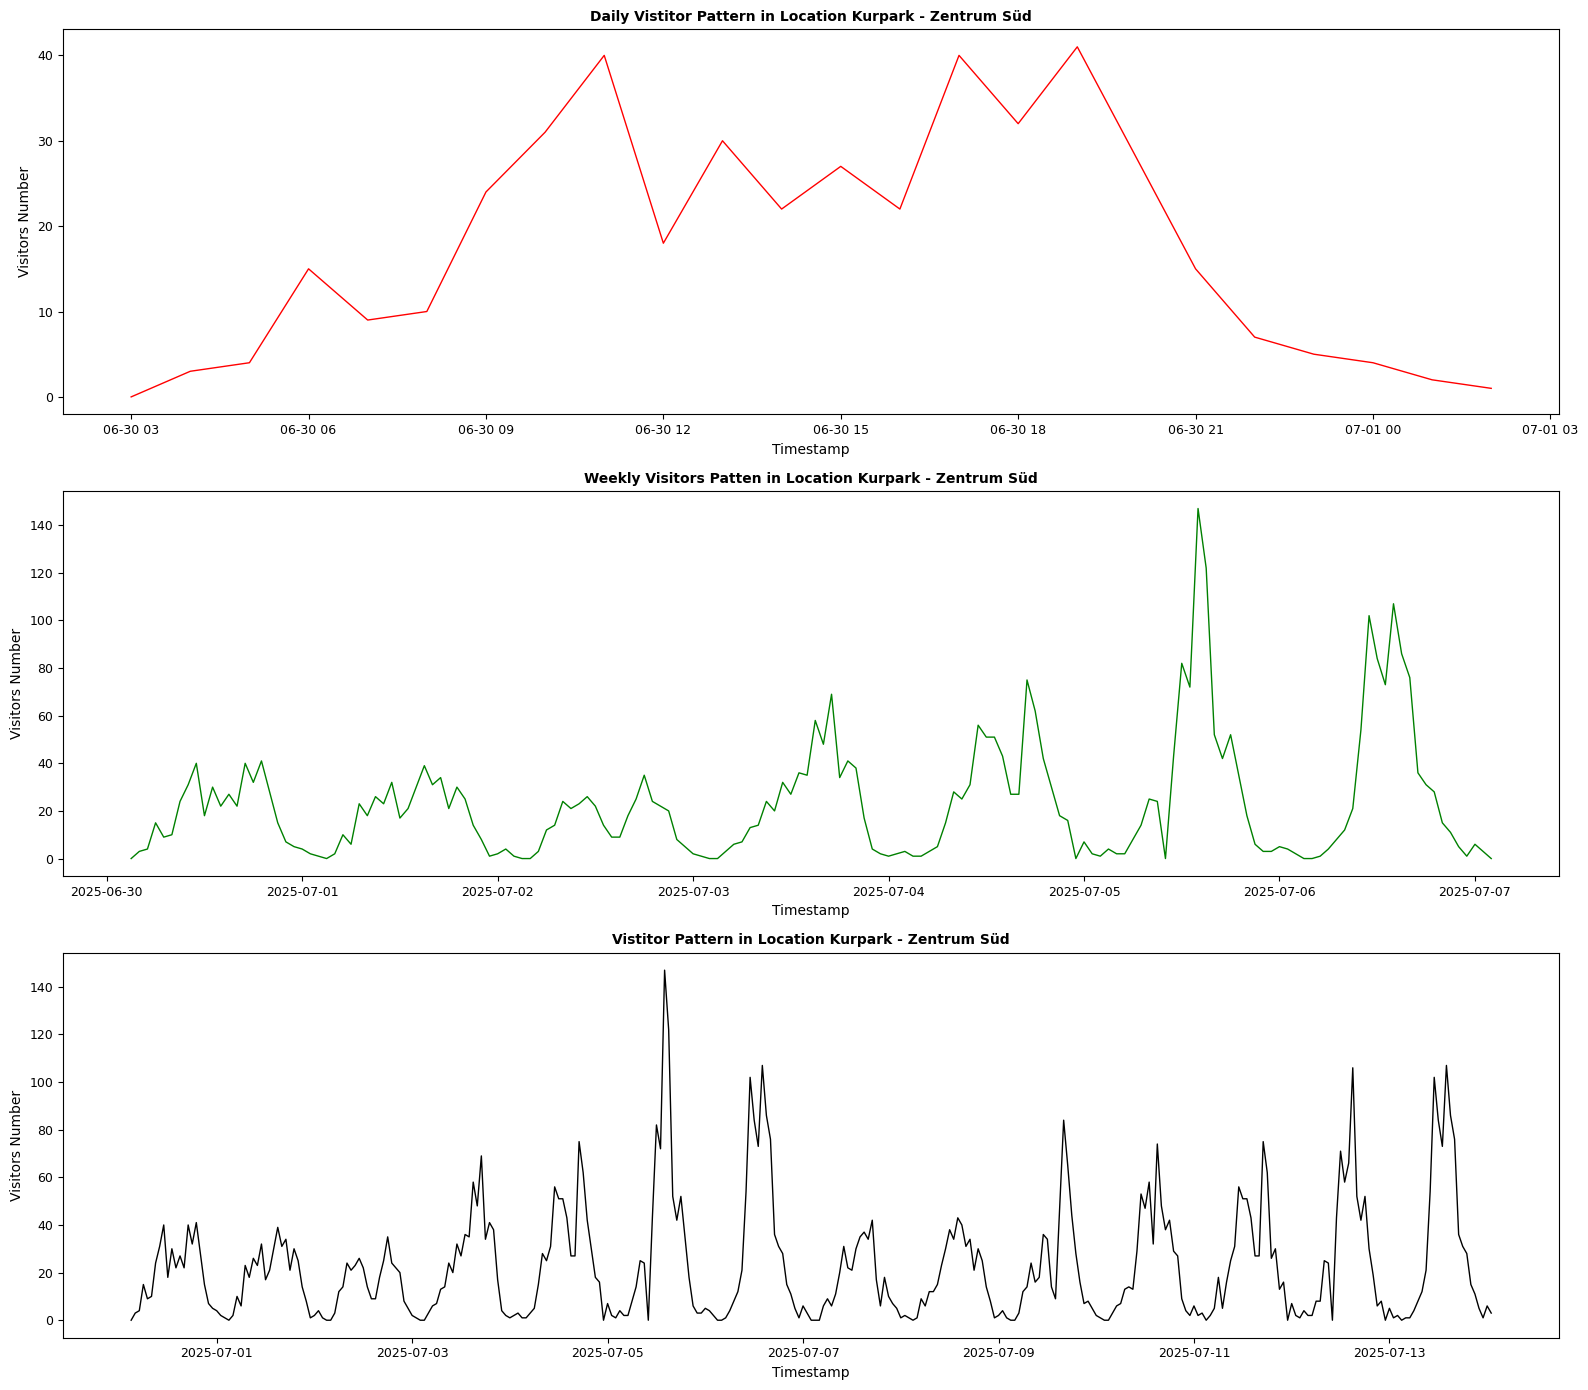

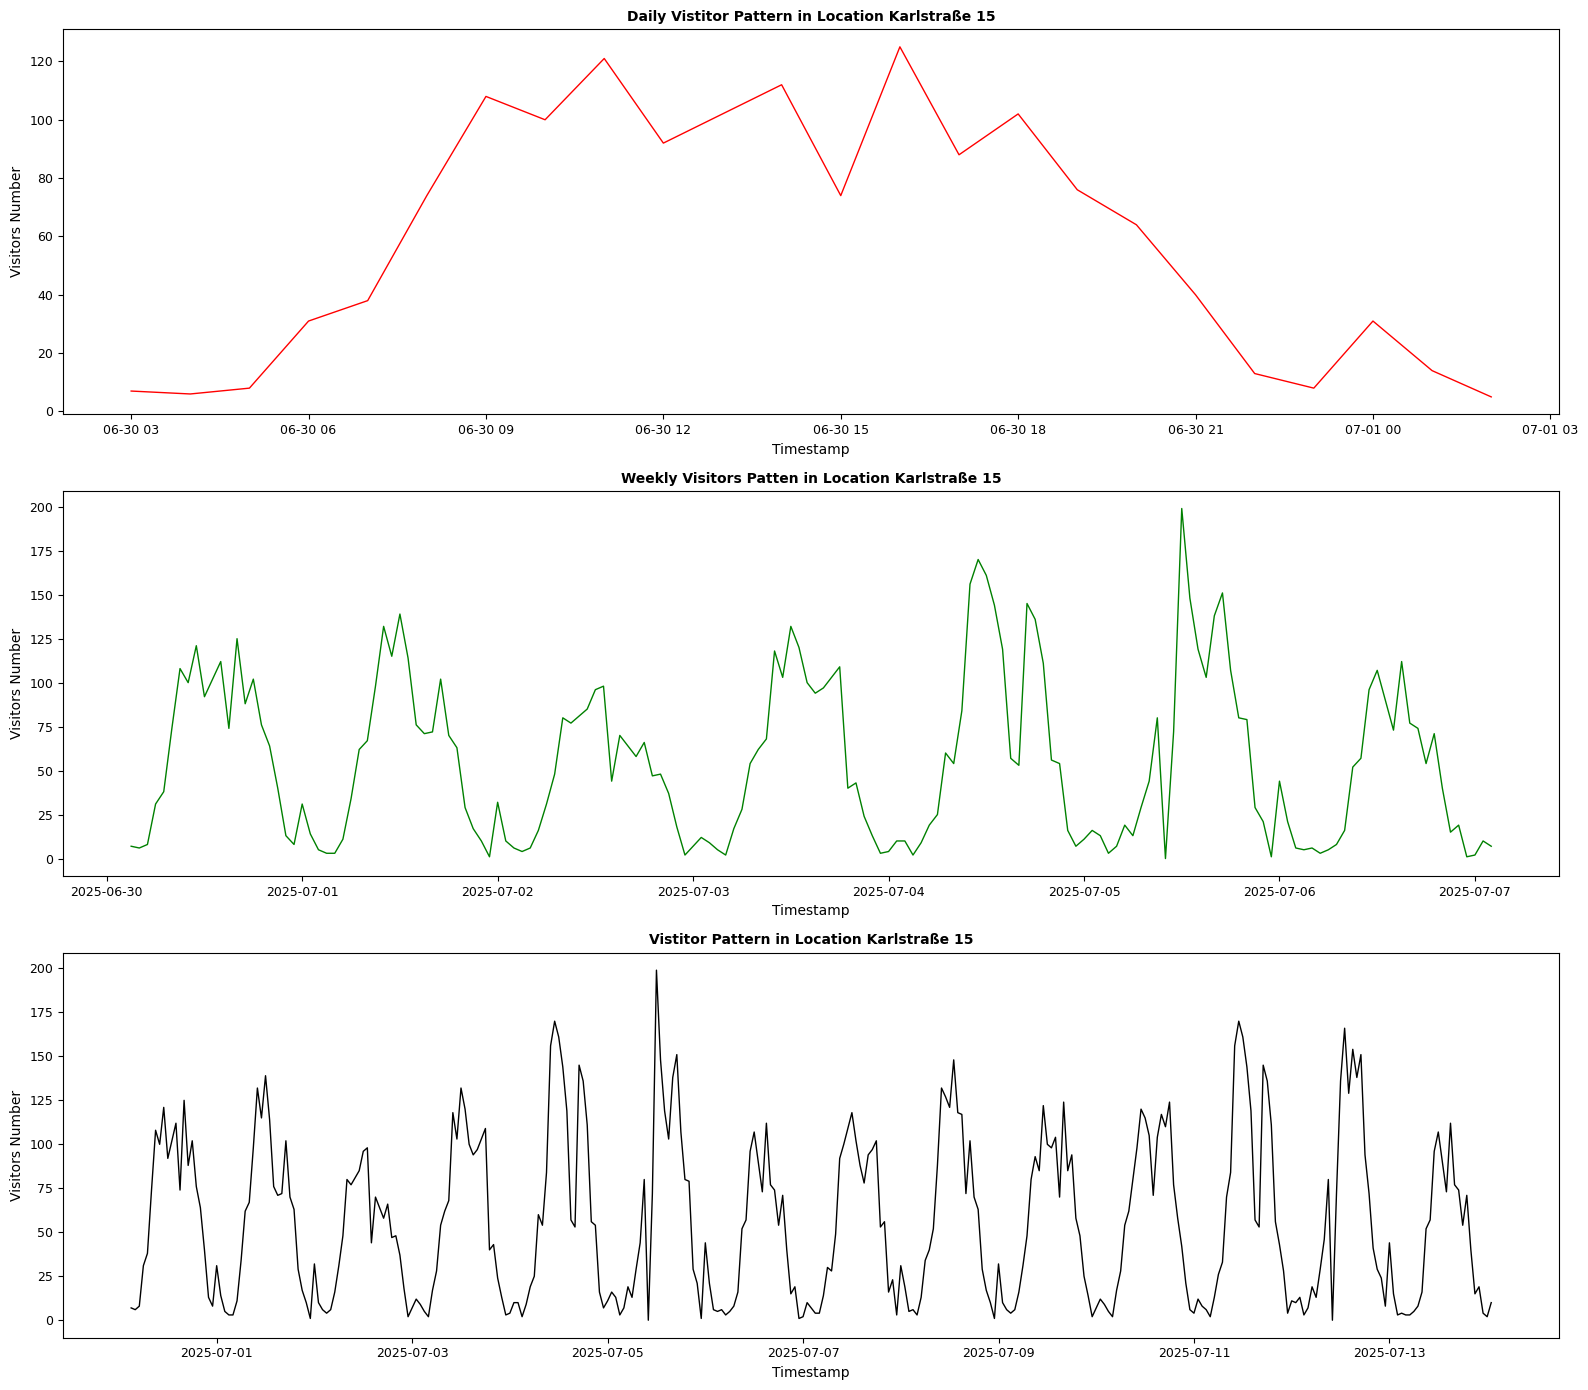

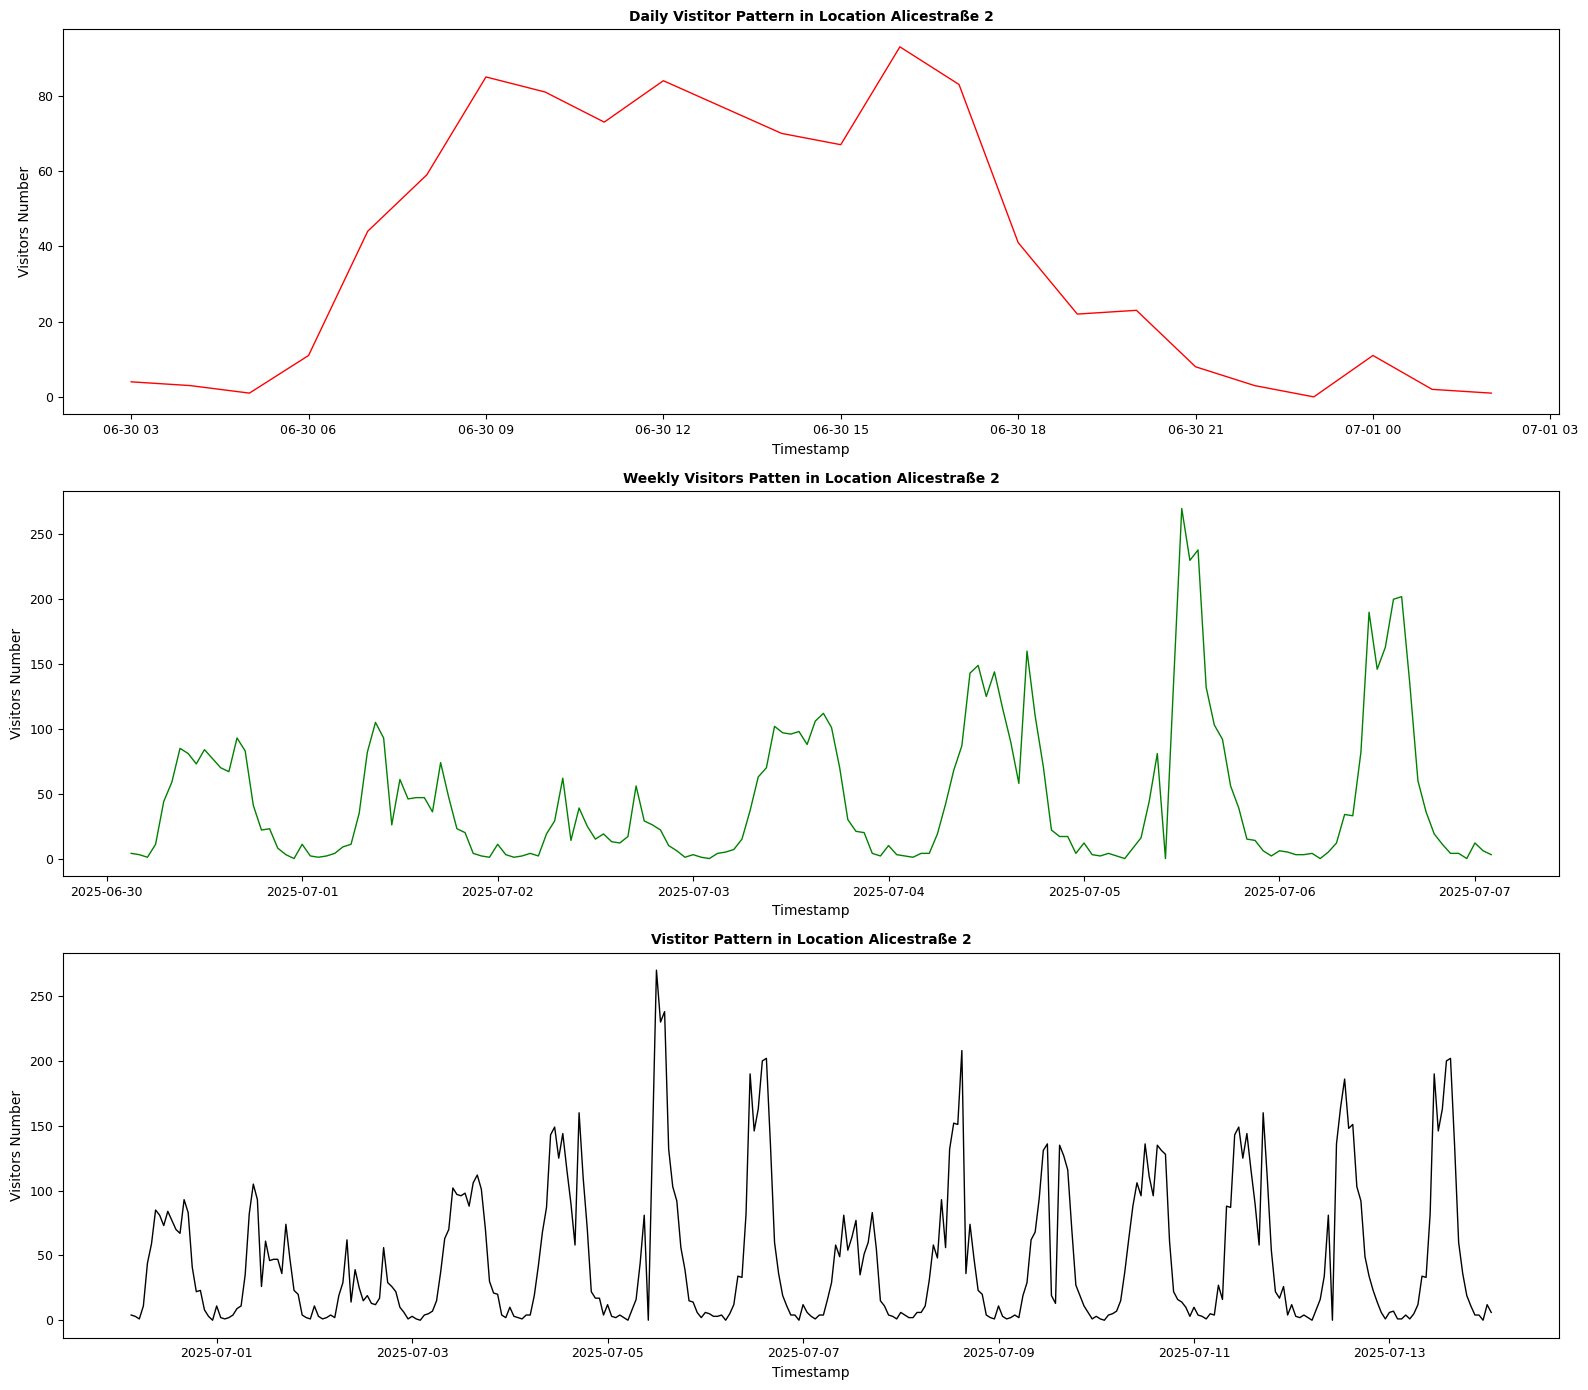

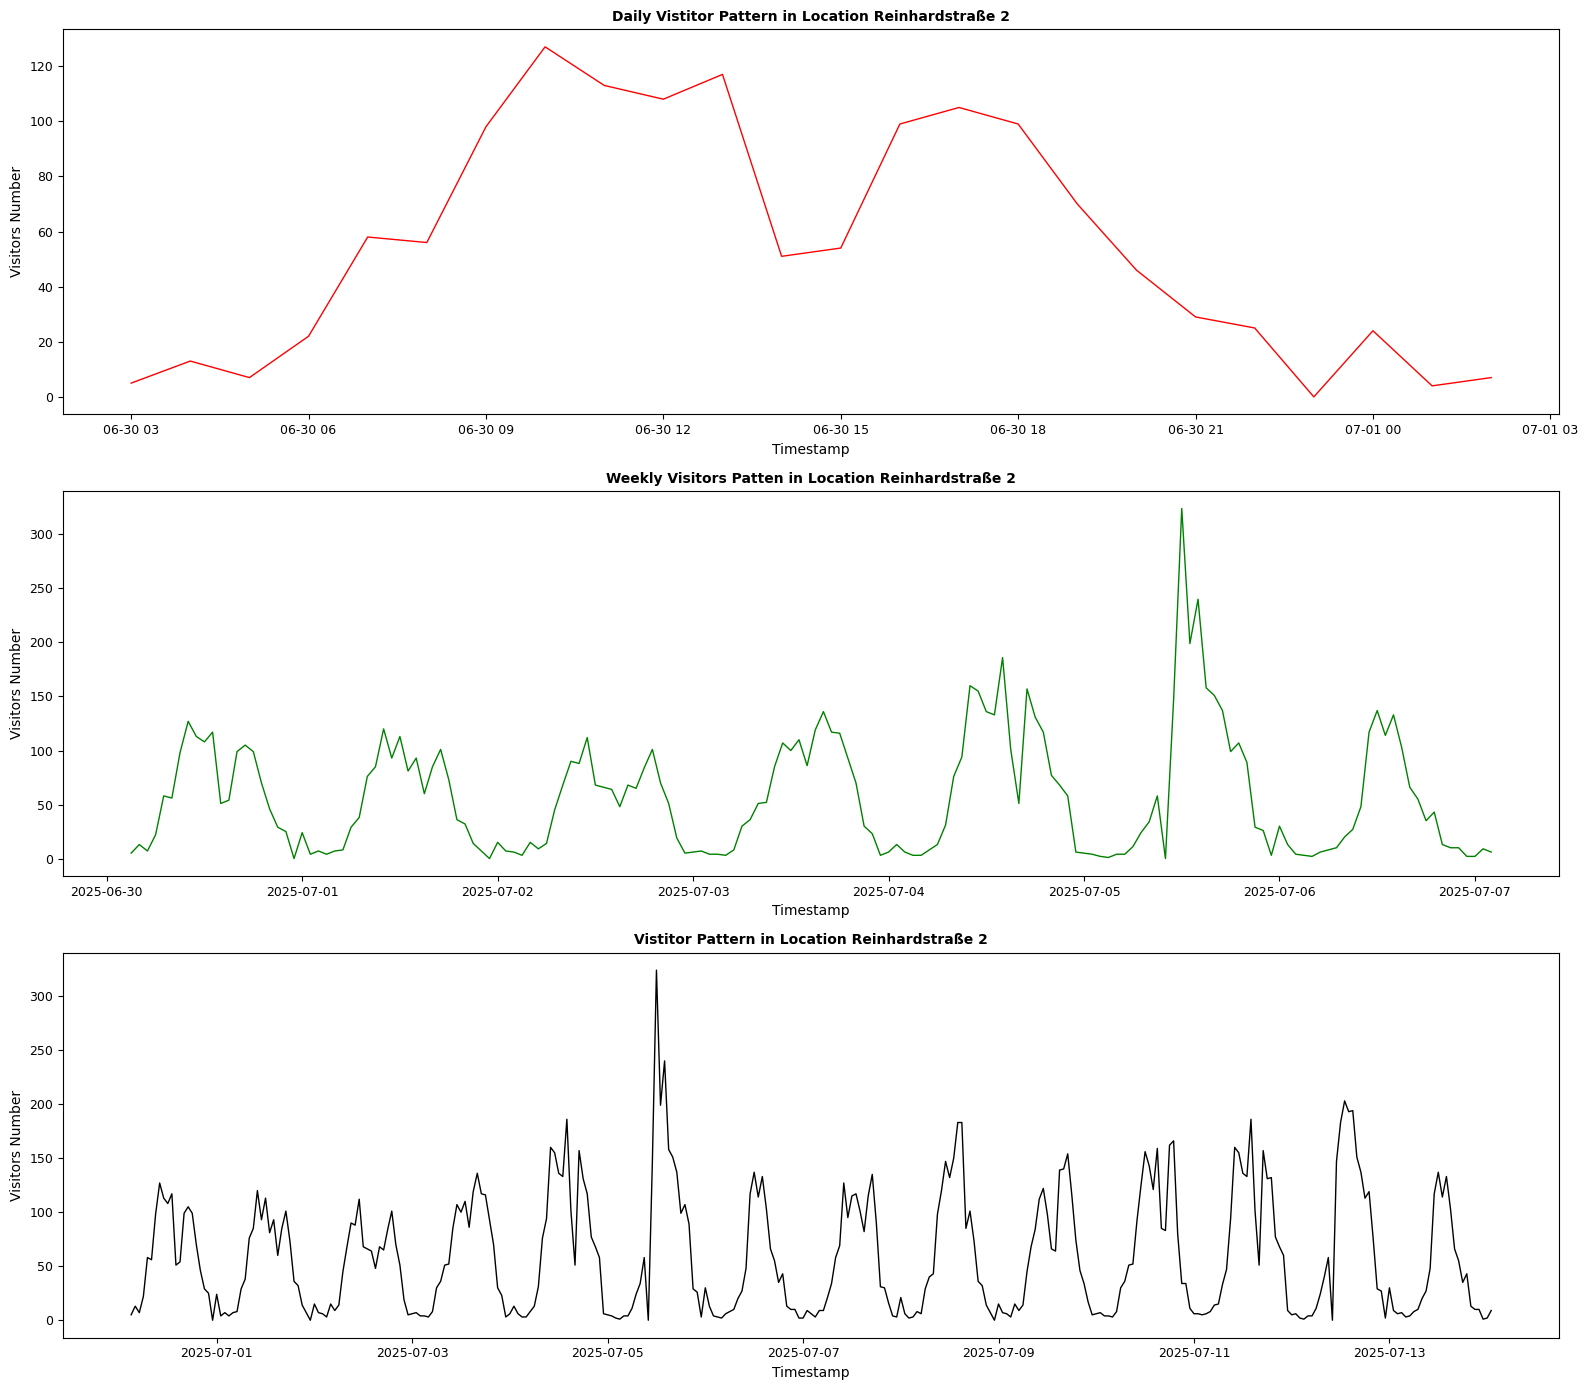

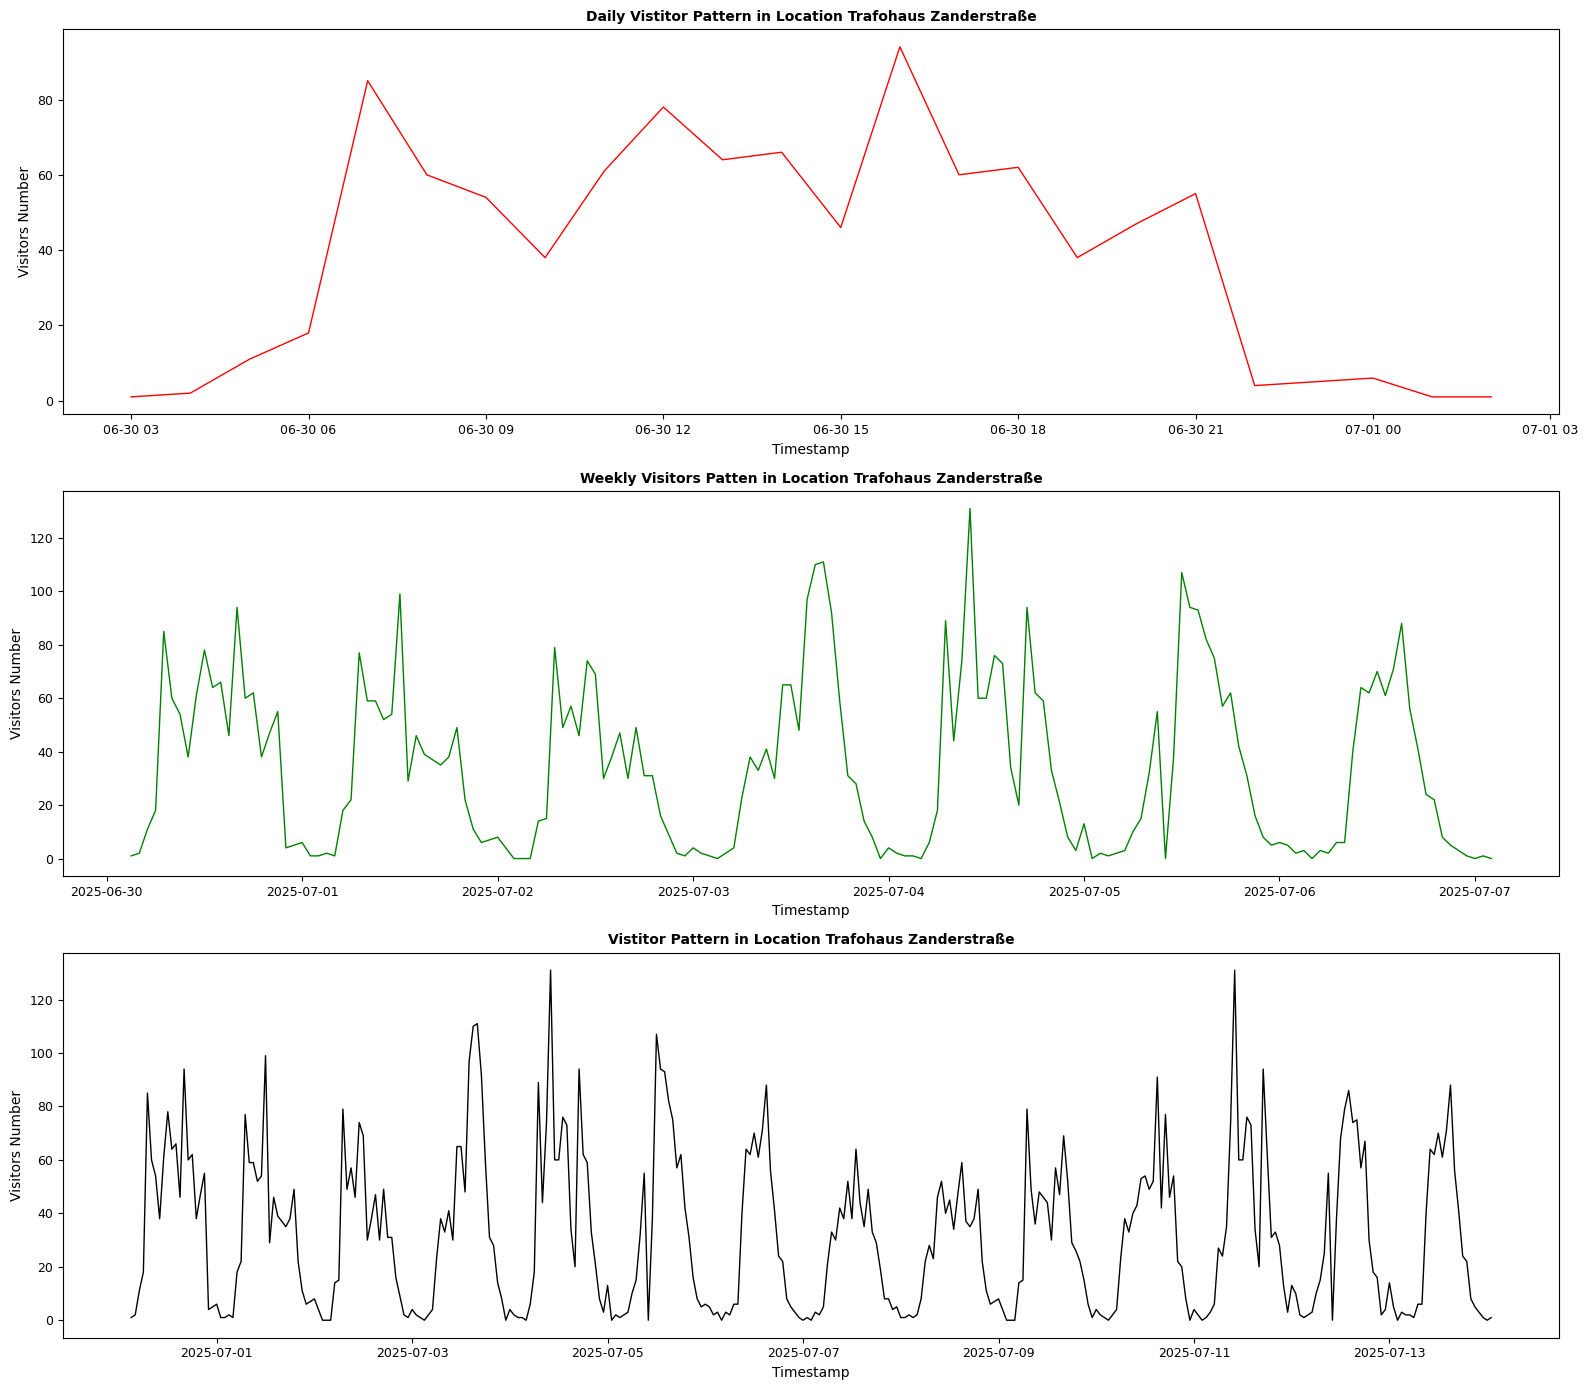

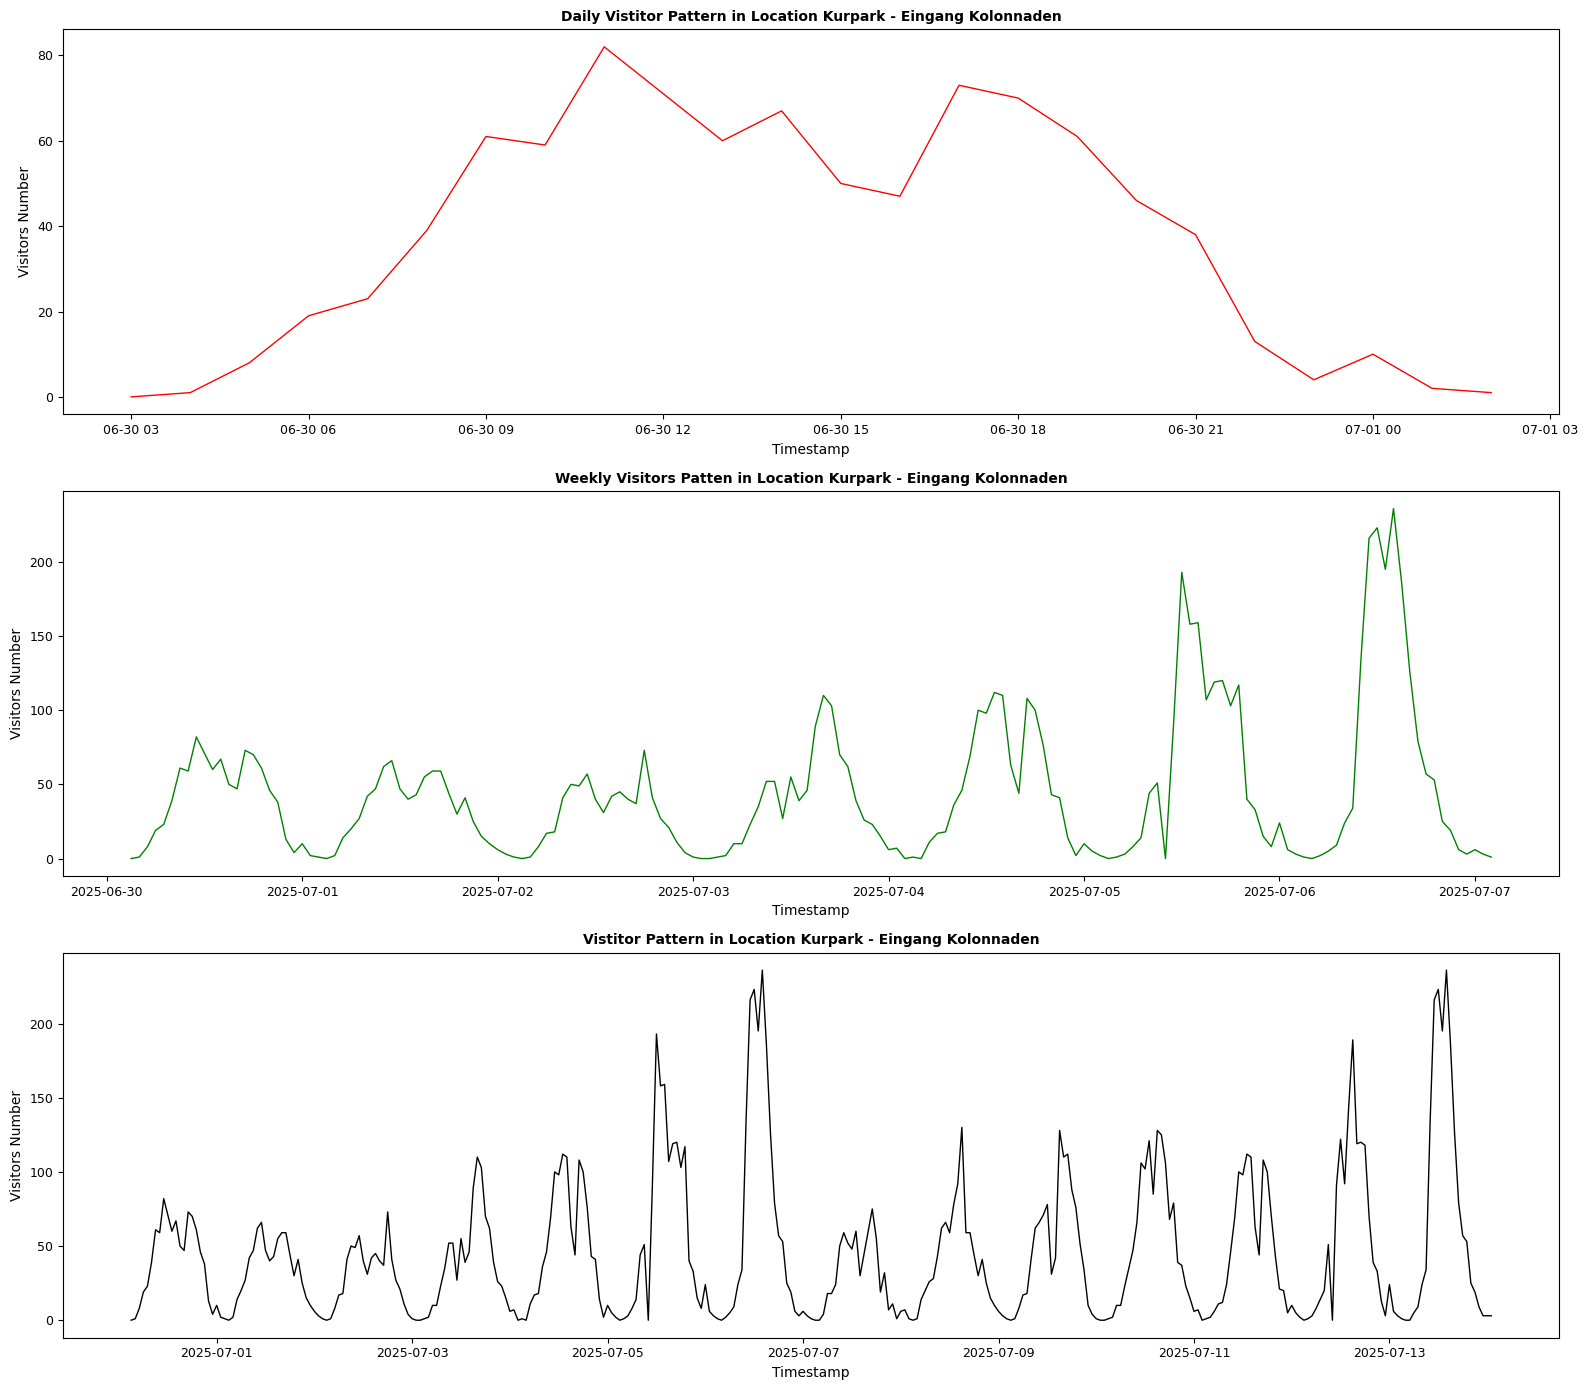

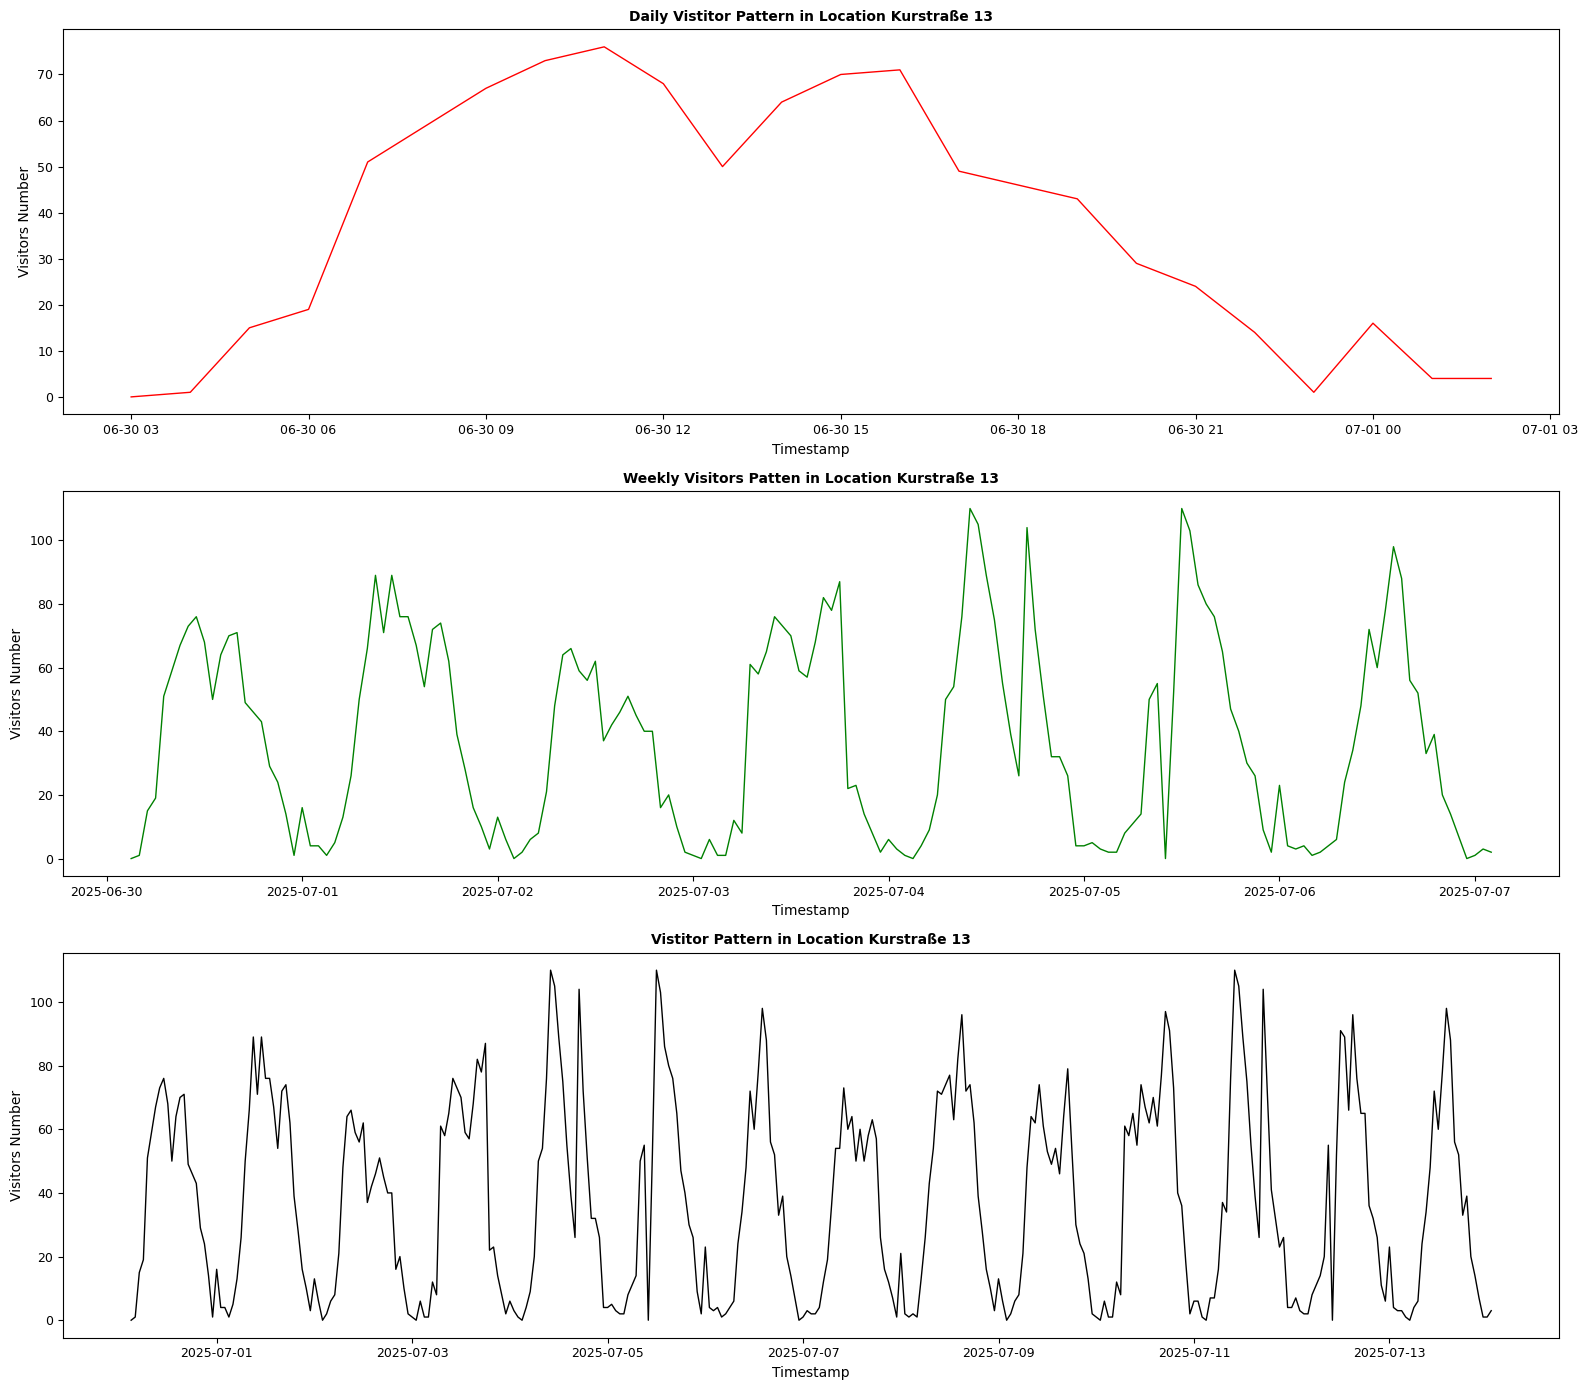

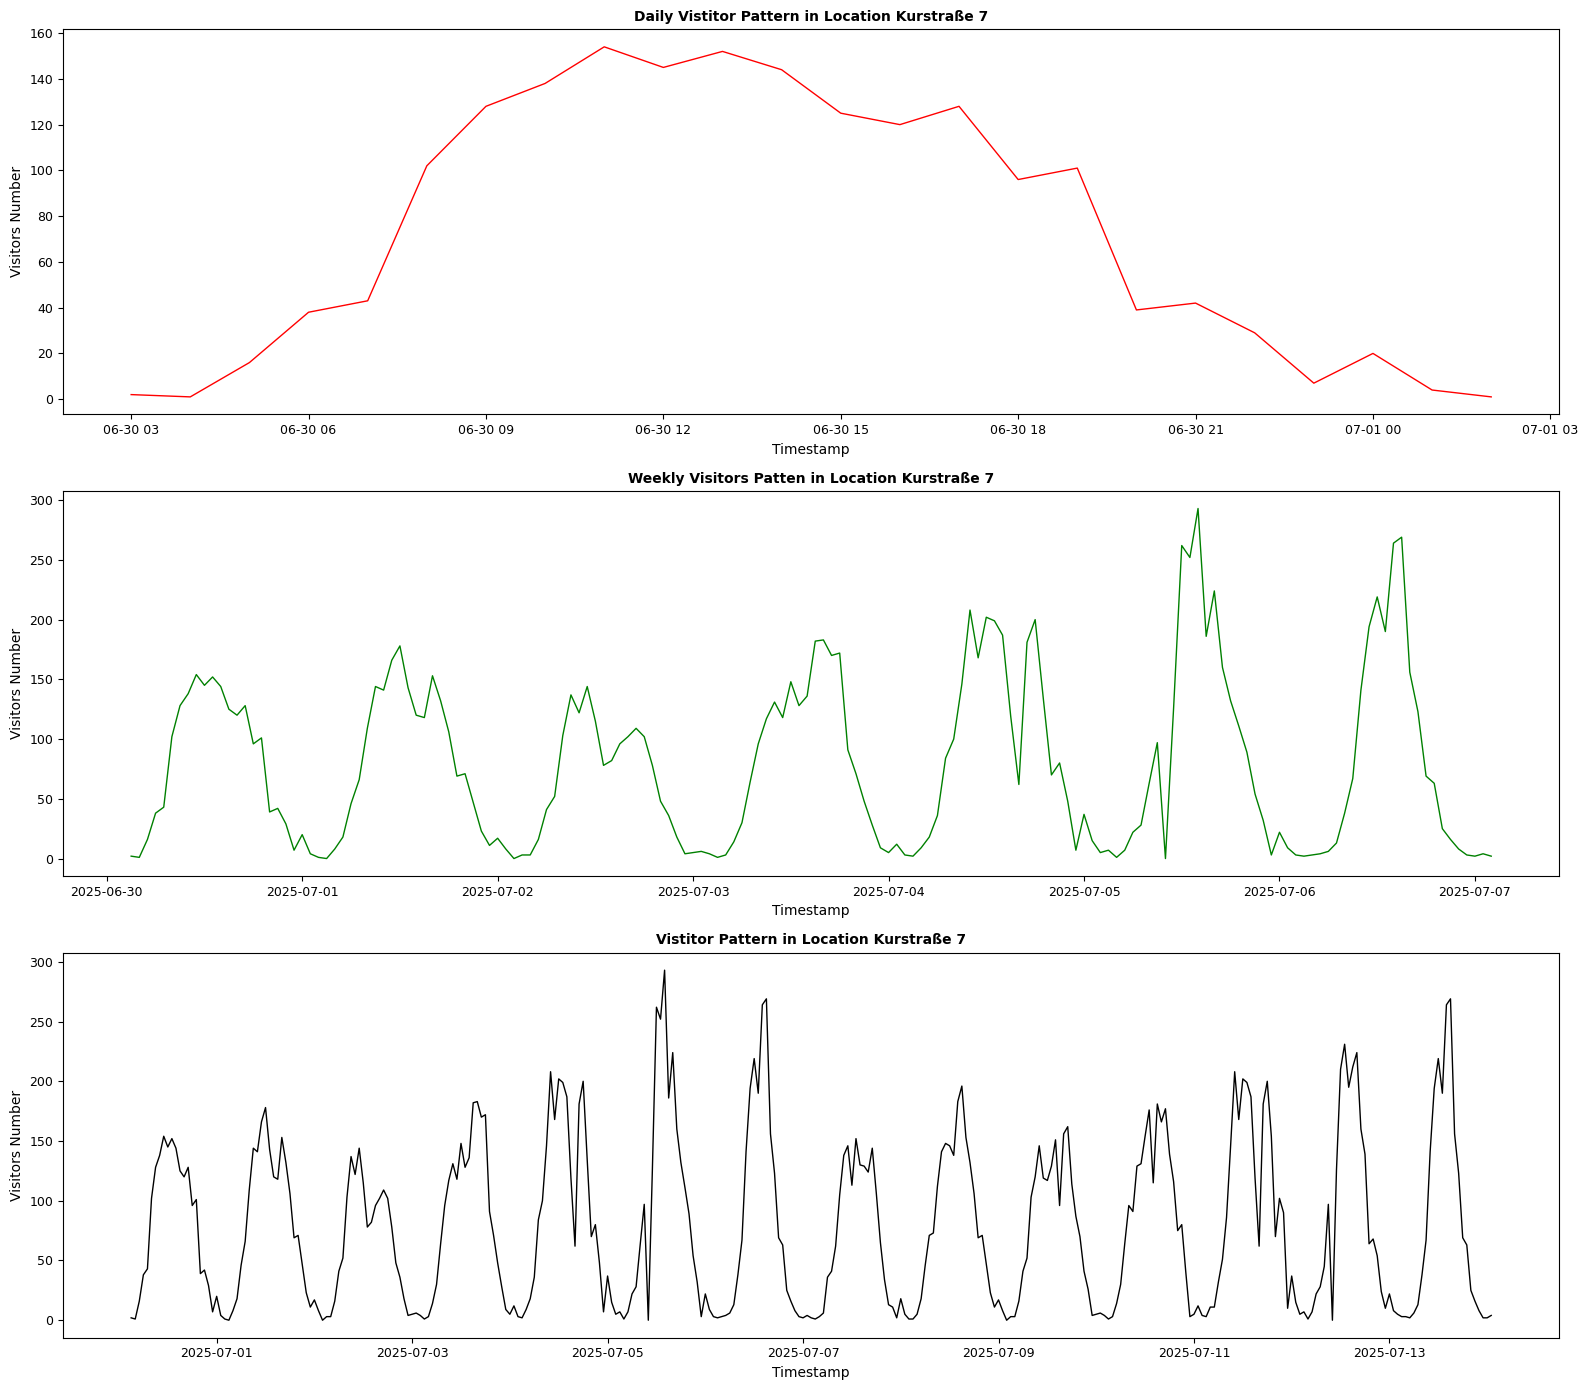

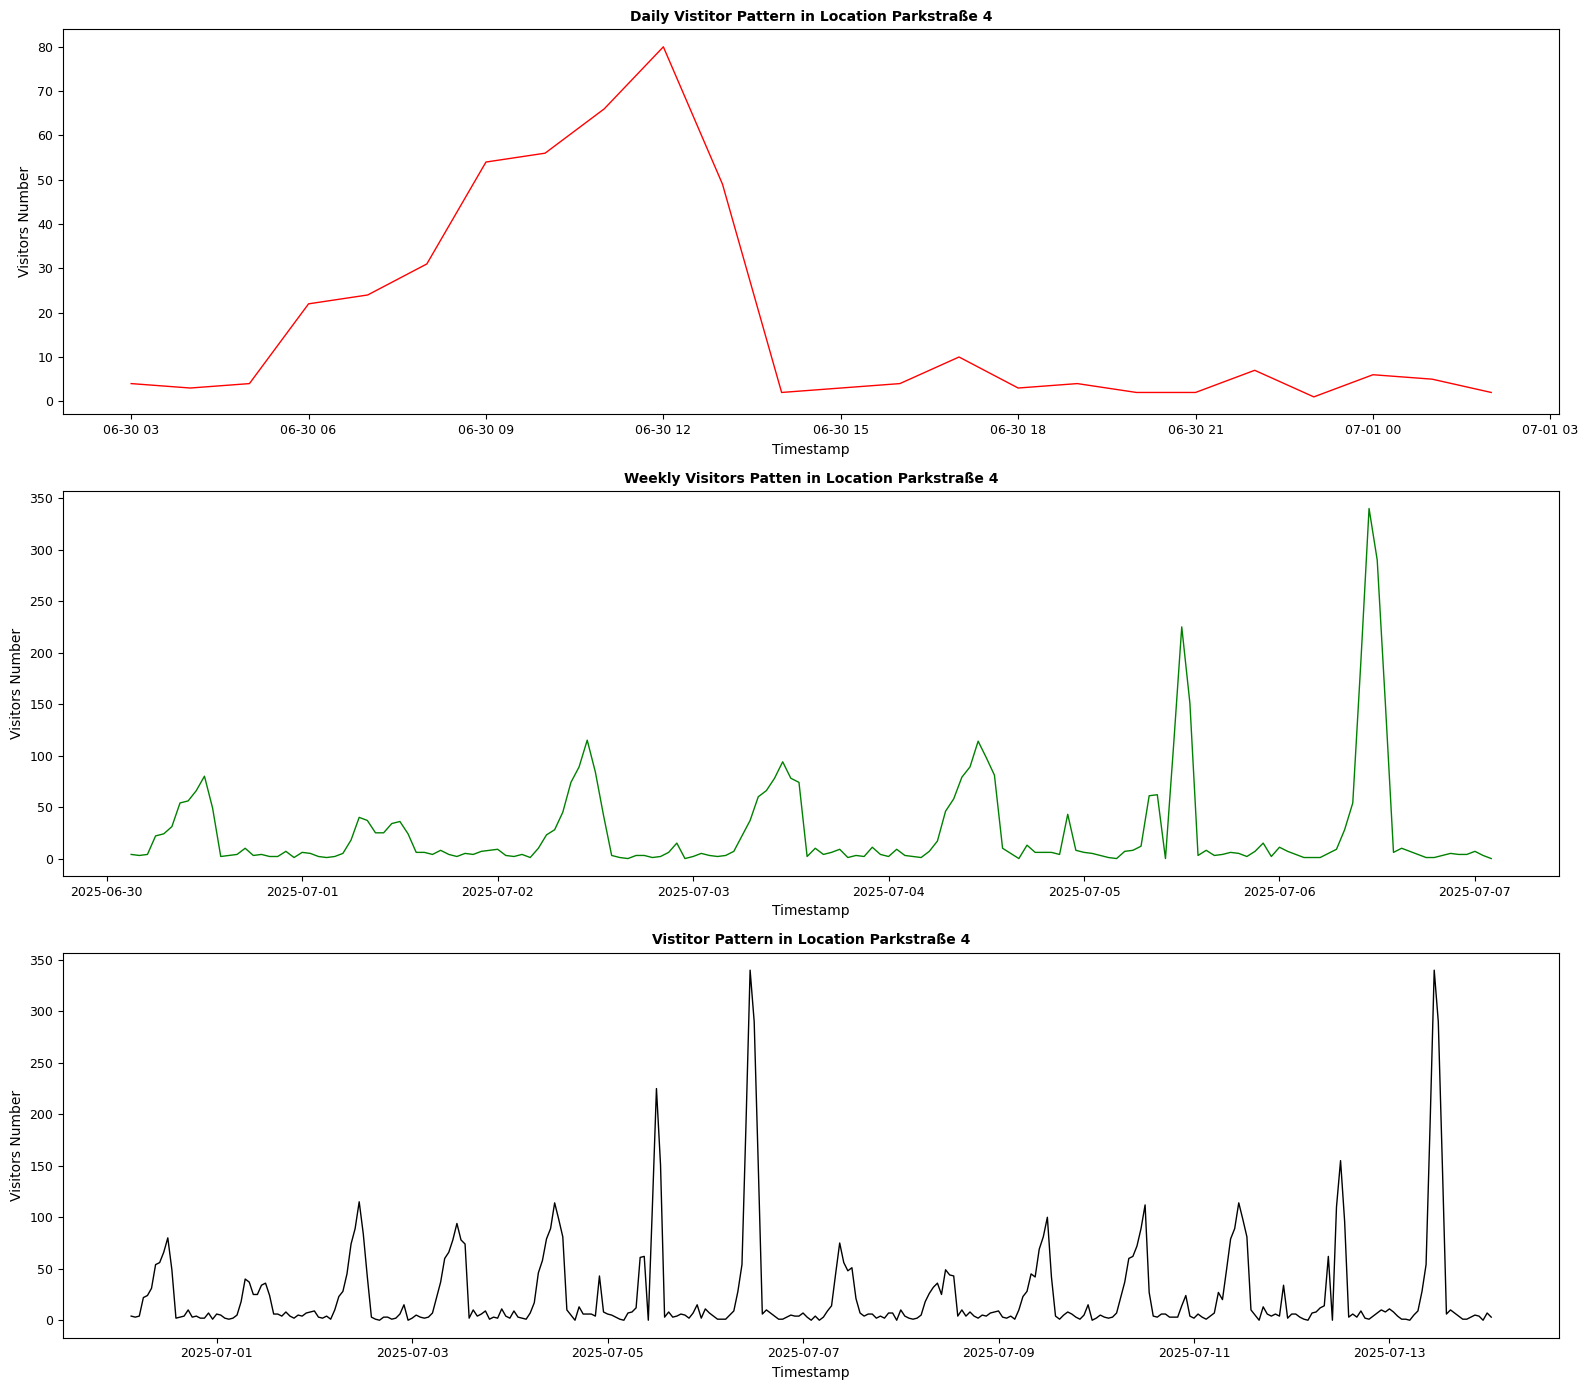

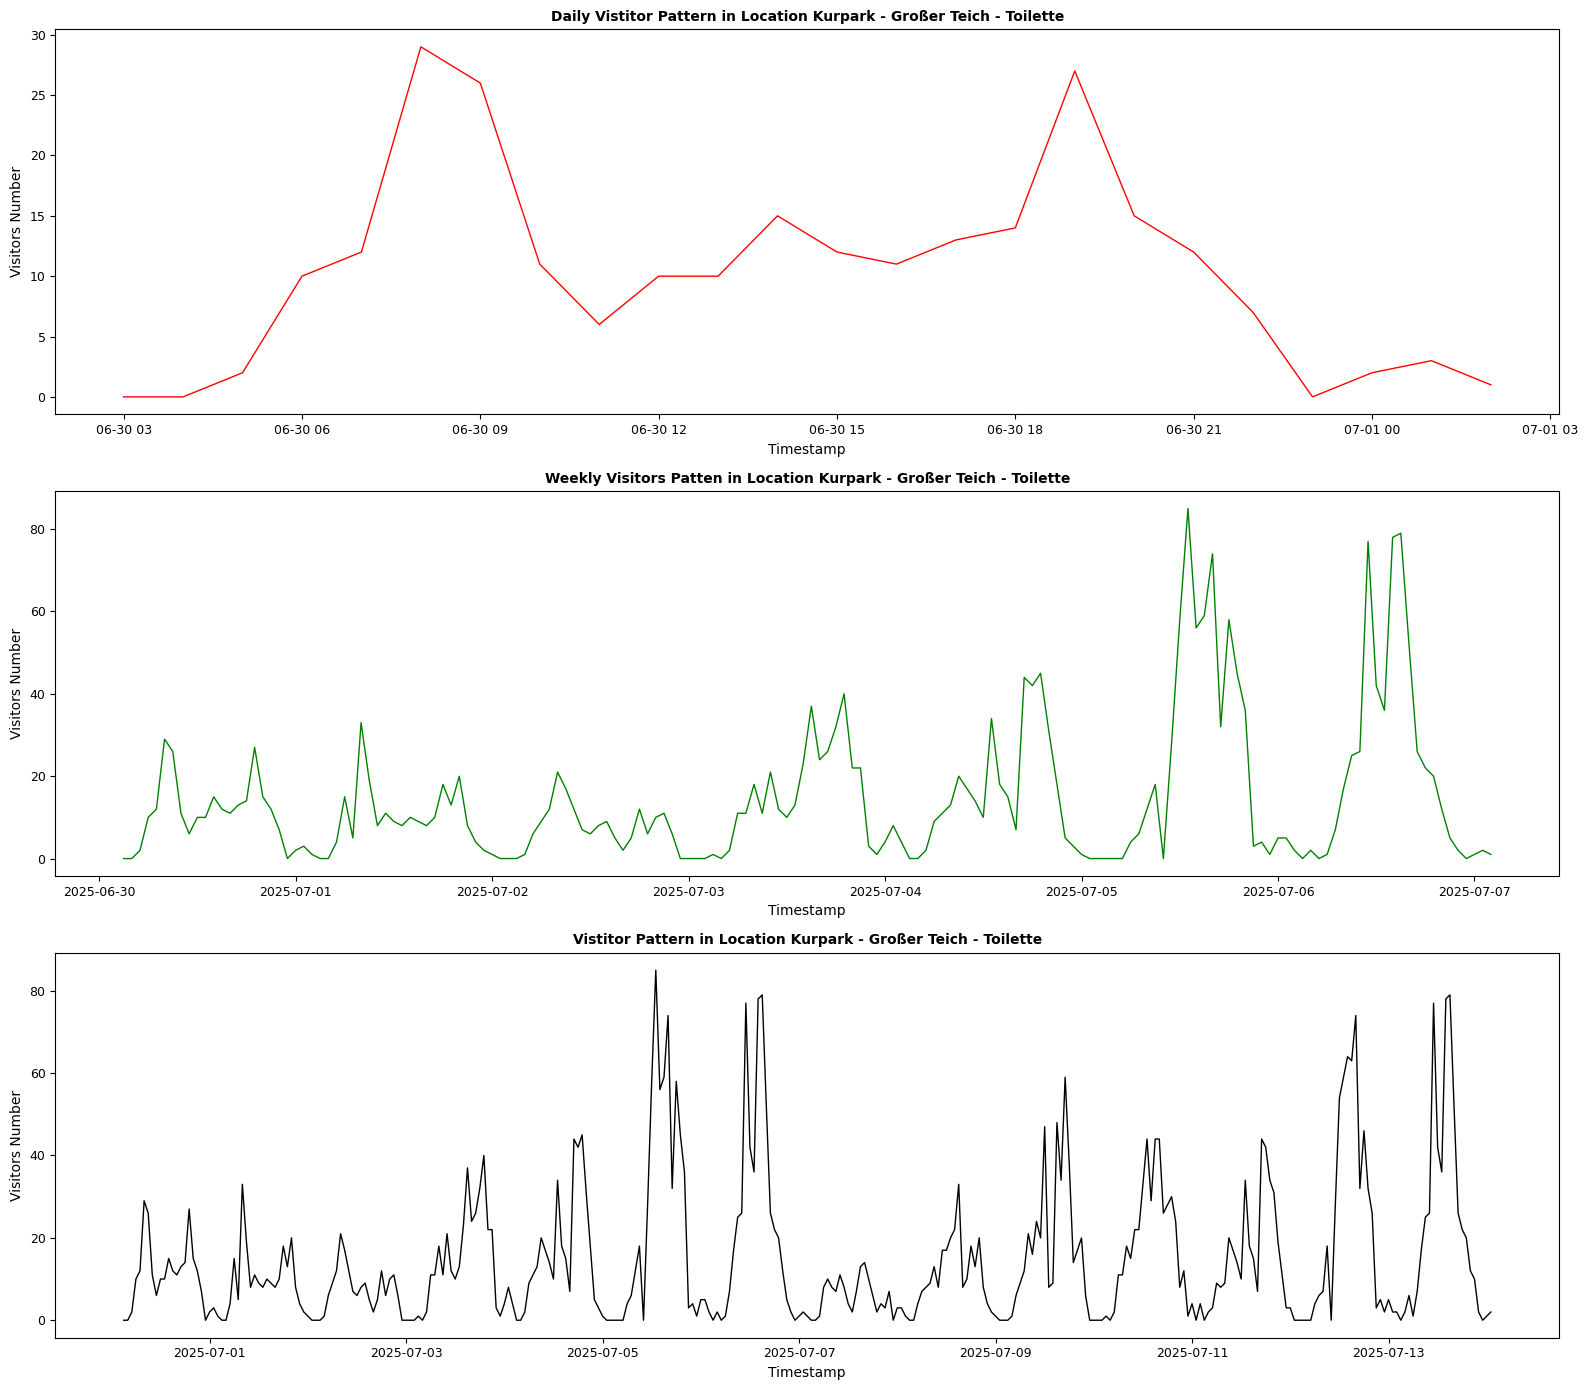

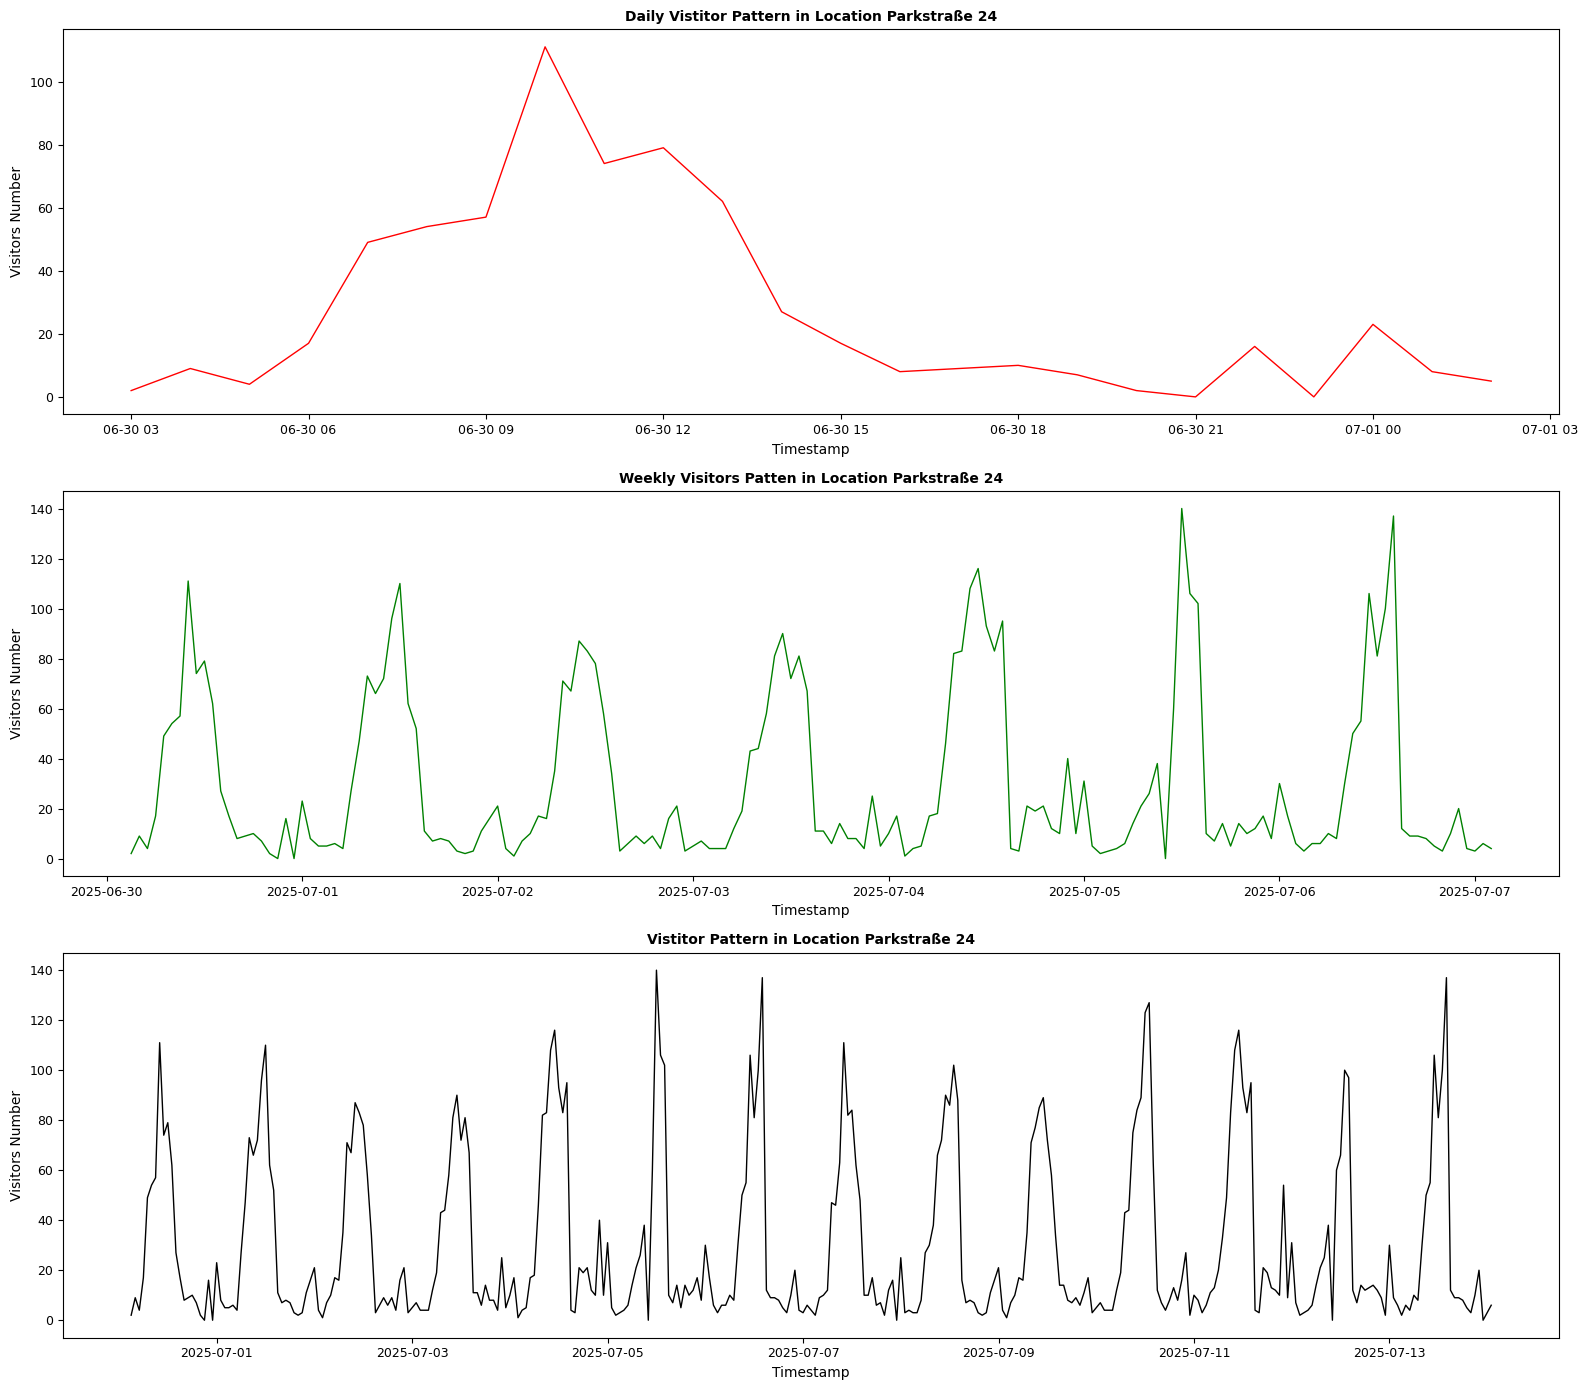

In [39]:
for sensor in sensors:
    pattern_analysis(sensor)


In [40]:
#Save final per sensor data for final comparison

def per_sensor_data_analysis_final(sensors):
    directory = Path('sensor_data_final/')
    directory.mkdir(parents = True, exist_ok=True)
    for sensor in sensors:
        data = df[df['SID'] == sensor]
        location = data['name'].iloc[0]
        output_file = directory/f"{location}.csv"
        data.to_csv(output_file)
        

per_sensor_data_analysis_final(sensors)

In [41]:
#Save final data for model building

df.to_csv("final_data.csv",index=False)